# Multi-Class News Article Classification Using Machine Learning and Natural Language Processing

**CSE440: Natural Language Processing II** | Lab Project

**Dataset:** 20 Newsgroups (`SetFit/20_newsgroups`), 20 classes, 18,144 documents after cleaning

## Authors and contributions

| Member | Sections | Contribution |
| --- | --- | --- |
| Mahir Al Muntaqim | 1 to 7 | Dataset, EDA, preprocessing, splits, TF-IDF, Word2Vec, GloVe |
| Mohammad Hasibul Amin | 8, 9.1, 9.2 | Random Forest, Logistic Regression, Naive Bayes, SimpleRNN, Bidirectional SimpleRNN |
| Fabiha Tarannum Areena | 9.3, 9.4 | LSTM, Bidirectional LSTM, shared evaluation module |
| Zawad Ahsan | 9.5, 9.6, 10, 11 to 15 | GRU, Bidirectional GRU, BERT Base, consolidated results and discussion |

Ten models, thirty required training runs and six ablations. Every model was trained and
evaluated on the same frozen splits, verified by a shared dataset checksum, and scored by
one shared evaluation module.

## Section 1 - Problem Definition

The task is single-label multi-class text classification. Given the body of a Usenet post,
predict which of 20 newsgroups it was published in.

The 20 labels group into 7 families by prefix: `alt`, `comp`, `misc`, `rec`, `sci`, `soc`
and `talk`. Five classes sit under `comp` and four each under `rec`, `sci` and `talk`. This
structure matters for the results. Classes inside one family share vocabulary, so most
errors are expected between them rather than across the corpus.

The real-world relevance is topic routing. News aggregators, forums and support systems
all need to file incoming text into a fixed set of topics without a human reading it.
20 Newsgroups is the standard benchmark for that problem, so results here are comparable
to published work.

This notebook section produces the artifacts every other section loads: the cleaned
splits, the label map, the TF-IDF matrices, the padded sequences and both embedding
matrices.

## Section 2 - Setup and Imports

Installs, imports and the frozen configuration constants. Every constant here is shared
across the four team notebooks. Changing one invalidates the comparison table.

In [ ]:
# Colab install. `datasets` and `gensim` are not preinstalled.
!pip install -q datasets gensim wordcloud

In [ ]:
import os, re, json, time, hashlib, string
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 90)
print("imports ok")

imports ok


In [ ]:
# Frozen configuration. Please use this for the entire project as i mentipned in messenger
SEED          = 42
VAL_SIZE      = 0.15      # carved out of TRAIN only
MIN_DOC_CHARS = 10        # documents shorter than this after cleaning are dropped
MAX_VOCAB     = 20000     # Keras tokenizer vocabulary cap
MAX_LEN       = 250       # padded sequence length
EMBEDDING_DIM = 50        # matches glove.6B.50d

DATASET_NAME  = "SetFit/20_newsgroups"

np.random.seed(SEED)

# Google Drive is where artifacts live so all four members load identical files.
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR   = Path("/content/drive/MyDrive/cse440_project")
SPLIT_DIR  = DATA_DIR / "splits"
REPR_DIR   = DATA_DIR / "representations"
FIG_DIR    = DATA_DIR / "figures"
for d in (SPLIT_DIR, REPR_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"seed          : {SEED}")
print(f"artifacts dir : {DATA_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
seed          : 42
artifacts dir : /content/drive/MyDrive/cse440_project


In [ ]:
# NLTK resources used in Task 4.
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f"warn: {pkg} -> {e}")
print("nltk resources ready")

nltk resources ready


In [ ]:
raw = load_dataset(DATASET_NAME)
print(raw)

README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl: reconstructing file:   0%|          |  0.00B / 14.8MB            

train.jsonl: downloading bytes:           |  0.00B            

test.jsonl: reconstructing file:   0%|          |  0.00B / 8.91MB            

test.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 11314
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7532
    })
})


## Section 3 - Dataset Loading and Description

The 20 Newsgroups corpus, distributed on Hugging Face as `SetFit/20_newsgroups`. It is
a collection of Usenet posts from 1993 and 1994, split across 20 discussion groups.

The Hugging Face copy ships with the original temporal train and test split. Training
posts come before test posts in time. This is a property of the benchmark and is not
reshuffled. Reshuffling would leak later posts into training and inflate every score.

In [ ]:
train_raw = raw["train"].to_pandas()
test_raw  = raw["test"].to_pandas()

print(f"train rows : {len(train_raw):,}")
print(f"test rows  : {len(test_raw):,}")
print(f"total rows : {len(train_raw) + len(test_raw):,}")
print(f"columns    : {list(train_raw.columns)}")
train_raw.head(3)

train rows : 11,314
test rows  : 7,532
total rows : 18,846
columns    : ['text', 'label', 'label_text']


,text,label,label_text
0,I was wondering if anyone out there could enlighten me on this car I saw\nthe other da...,7,rec.autos
1,A fair number of brave souls who upgraded their SI clock oscillator have\nshared their...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the ghost this weekend after\nstarting life as...",4,comp.sys.mac.hardware


In [ ]:
# Label id -> name map. Frozen and exported so every notebook decodes identically.
label_map = (train_raw[["label", "label_text"]]
             .drop_duplicates()
             .sort_values("label")
             .set_index("label")["label_text"]
             .to_dict())

CLASS_NAMES = [label_map[i] for i in sorted(label_map)]
NUM_CLASSES = len(CLASS_NAMES)

print(f"{NUM_CLASSES} classes:")
for i, n in enumerate(CLASS_NAMES):
    print(f"  {i:2d}  {n}")

20 classes:
   0  alt.atheism
   1  comp.graphics
   2  comp.os.ms-windows.misc
   3  comp.sys.ibm.pc.hardware
   4  comp.sys.mac.hardware
   5  comp.windows.x
   6  misc.forsale
   7  rec.autos
   8  rec.motorcycles
   9  rec.sport.baseball
  10  rec.sport.hockey
  11  sci.crypt
  12  sci.electronics
  13  sci.med
  14  sci.space
  15  soc.religion.christian
  16  talk.politics.guns
  17  talk.politics.mideast
  18  talk.politics.misc
  19  talk.religion.misc


### Hierarchical label structure

The 20 labels collapse into 7 families by their prefix. Confusion inside a family is a
different kind of error from confusion across families, and the modelling notebooks
report the two separately.

In [ ]:
SUPERCLASS = {n: (n.split(".")[0] if not n.startswith("misc") else "misc")
              for n in CLASS_NAMES}

fam = pd.Series(SUPERCLASS).value_counts().sort_index()
print("classes per family:")
print(fam.to_string())

classes per family:
alt     1
comp    5
misc    1
rec     4
sci     4
soc     1
talk    4


In [ ]:
# A concrete example so the report can describe what a document actually is.
ex = train_raw.iloc[7]
print(f"label: {ex['label']}  ({ex['label_text']})")
print(f"chars: {len(ex['text'])}")
print("-" * 70)
print(ex["text"][:700])

label: 3  (comp.sys.ibm.pc.hardware)
chars: 1596
----------------------------------------------------------------------
                                                                      
ALL this shows is that YOU don't know much about SCSI.

SCSI-1 {with a SCSI-1 controler chip} range is indeed 0-5MB/s
and that is ALL you have right about SCSI
SCSI-1 {With a SCSI-2 controller chip}: 4-6MB/s with 10MB/s burst {8-bit}
 Note the INCREASE in SPEED, the Mac Quadra uses this version of SCSI-1
 so it DOES exist. Some PC use this set up too.
SCSI-2 {8-bit/SCSI-1 mode}:          4-6MB/s with 10MB/s burst
SCSI-2 {16-bit/wide or fast mode}:  8-12MB/s with 20MB/s burst
SCSI-2 {32-bit/wide AND fast}:     15-20MB/s with 40MB/s burst
 
By your OWN data the "Although SCSI is twice as fast as ESDI" is correct
With a SCSI


## Section 4 - Exploratory Data Analysis

Three questions answered with evidence: how balanced the classes are, how long the
documents are, and what is broken in the data.

In [ ]:
full = pd.concat(
    [train_raw.assign(split="train"), test_raw.assign(split="test")],
    ignore_index=True,
)
full["n_chars"] = full["text"].str.len()
full["n_words"] = full["text"].str.split().str.len()

print(full.groupby("split")[["n_chars", "n_words"]].describe().T.round(1))

split              test    train
n_chars count    7532.0  11314.0
        mean     1096.9   1218.1
        std      3571.2   4038.3
        min         0.0      0.0
        25%       230.0    237.0
        50%       483.5    491.0
        75%       967.2    984.8
        max    158791.0  74878.0
n_words count    7532.0  11314.0
        mean      175.3    185.8
        std       465.2    524.0
        min         0.0      0.0
        25%        39.0     40.0
        50%        82.0     83.0
        75%       163.0    167.0
        max      9507.0  11765.0


### 4.1 Class distribution

In [ ]:
dist = (full.groupby(["split", "label_text"]).size()
        .unstack(0).reindex(CLASS_NAMES))
dist["total"] = dist.sum(axis=1)
dist["pct"]   = (100 * dist["total"] / dist["total"].sum()).round(2)

imbalance = dist["total"].max() / dist["total"].min()
print(dist.to_string())
print(f"\nimbalance ratio (max/min) = {imbalance:.2f}")

split                     test  train  total   pct
label_text                                        
alt.atheism                319    480    799  4.24
comp.graphics              389    584    973  5.16
comp.os.ms-windows.misc    394    591    985  5.23
comp.sys.ibm.pc.hardware   392    590    982  5.21
comp.sys.mac.hardware      385    578    963  5.11
comp.windows.x             395    593    988  5.24
misc.forsale               390    585    975  5.17
rec.autos                  396    594    990  5.25
rec.motorcycles            398    598    996  5.28
rec.sport.baseball         397    597    994  5.27
rec.sport.hockey           399    600    999  5.30
sci.crypt                  396    595    991  5.26
sci.electronics            393    591    984  5.22
sci.med                    396    594    990  5.25
sci.space                  394    593    987  5.24
soc.religion.christian     398    599    997  5.29
talk.politics.guns         364    546    910  4.83
talk.politics.mideast      376 

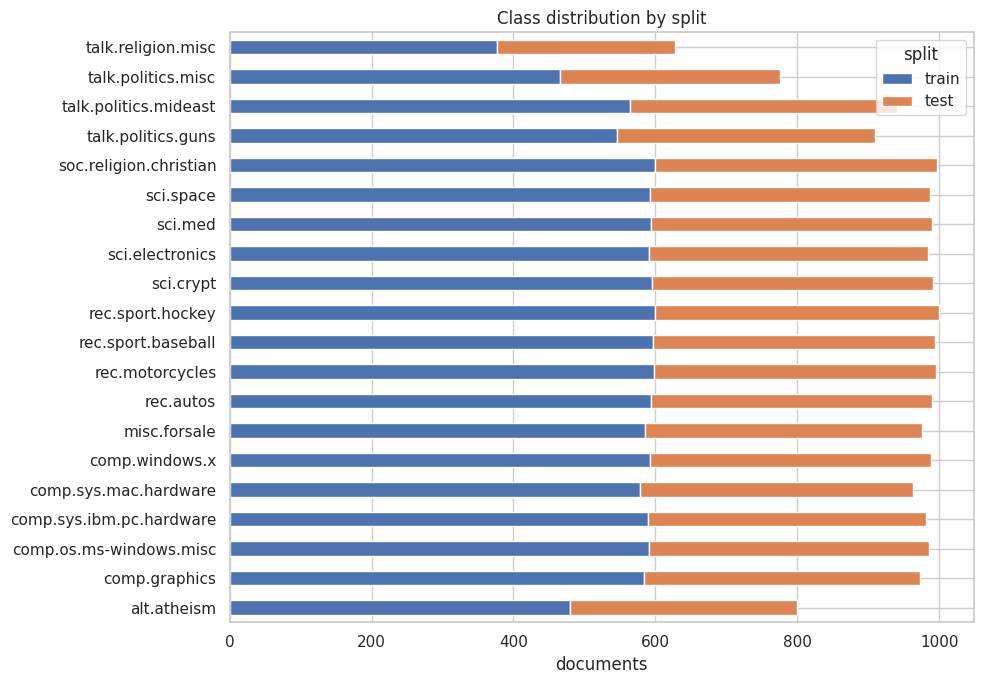

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
dist[["train", "test"]].plot(kind="barh", stacked=True, ax=ax)
ax.set_xlabel("documents"); ax.set_ylabel("")
ax.set_title("Class distribution by split")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150)
plt.show()

The corpus is close to balanced, roughly 600 to 1,000 documents per class. There is no
severe imbalance, so no resampling or class weighting is applied.

Macro-F1 is still the metric used to select configurations, because the smaller religion
and politics groups are the ones models confuse most and macro-F1 weights every class
equally.

### 4.2 Document length

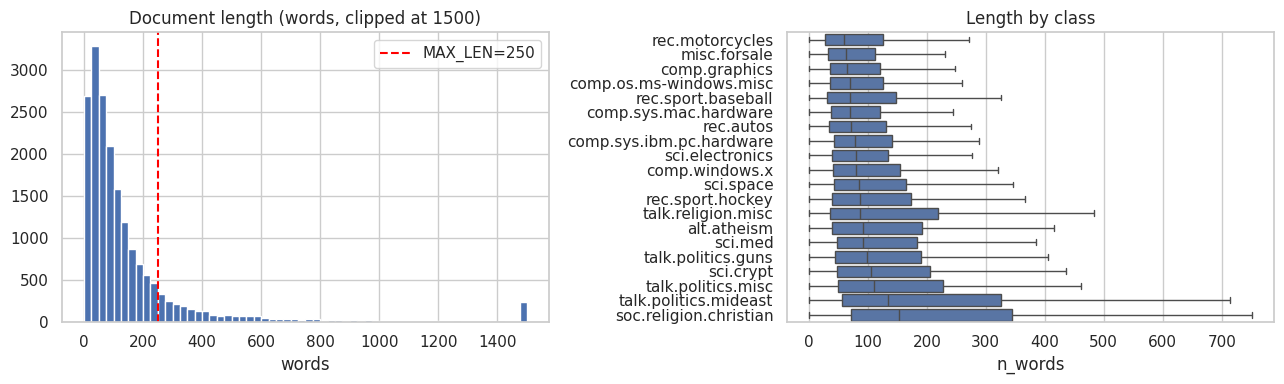

documents fully covered by MAX_LEN=250: 85.5%
0.50      83.0
0.75     166.0
0.90     331.0
0.95     558.0
0.99    1751.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(full["n_words"].clip(upper=1500), bins=60)
axes[0].set_title("Document length (words, clipped at 1500)")
axes[0].set_xlabel("words"); axes[0].axvline(MAX_LEN, color="red", ls="--",
                                             label=f"MAX_LEN={MAX_LEN}")
axes[0].legend()

order = full.groupby("label_text")["n_words"].median().sort_values().index
sns.boxplot(data=full, y="label_text", x="n_words", order=order,
            showfliers=False, ax=axes[1])
axes[1].set_title("Length by class"); axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(FIG_DIR / "length_distribution.png", dpi=150)
plt.show()

cov = (full["n_words"] <= MAX_LEN).mean()
print(f"documents fully covered by MAX_LEN={MAX_LEN}: {cov:.1%}")
print(full["n_words"].quantile([.5, .75, .9, .95, .99]).round(0).to_string())

Length is heavily right-skewed. A long tail of quoted reply chains drags the mean far
above the median.

The `MAX_LEN` line shows how much of each document the sequence models actually see.
This number is the honest explanation for any ceiling the recurrent tier hits.

### 4.3 Data quality

In [ ]:
empty      = (full["text"].str.strip().str.len() == 0).sum()
near_empty = (full["text"].str.strip().str.len() < MIN_DOC_CHARS).sum()
missing    = full["text"].isna().sum()

exact_dupes = full.duplicated(subset=["text"]).sum()
cross_leak  = test_raw["text"].isin(set(train_raw["text"])).sum()

print(f"missing (NaN) texts        : {missing}")
print(f"empty texts                : {empty}")
print(f"under {MIN_DOC_CHARS} chars: {near_empty}")
print(f"exact duplicate texts      : {exact_dupes}")
print(f"test rows also in train    : {cross_leak}   <-- leakage check")

missing (NaN) texts        : 0
empty texts                : 515
under 10 chars: 557
exact duplicate texts      : 559
test rows also in train    : 226   <-- leakage check


Four issues found in the raw corpus:

| Issue | Count |
| --- | --- |
| Missing texts | 0 |
| Empty texts | 515 |
| Under 10 characters | 557 |
| Exact duplicates | 559 |
| Test rows also present in train | 226 |

Decisions taken. Empty documents and documents shorter than `MIN_DOC_CHARS` carry no
signal and are removed in section 5. Exact duplicates within train are dropped so a
repeated post cannot be memorised. Duplicates are not removed from test, because the
test set stays the untouched benchmark.

The 226 train and test overlaps are reported rather than deleted. They are a property of
the published benchmark, not something introduced here.

### 4.4 Most frequent terms per family

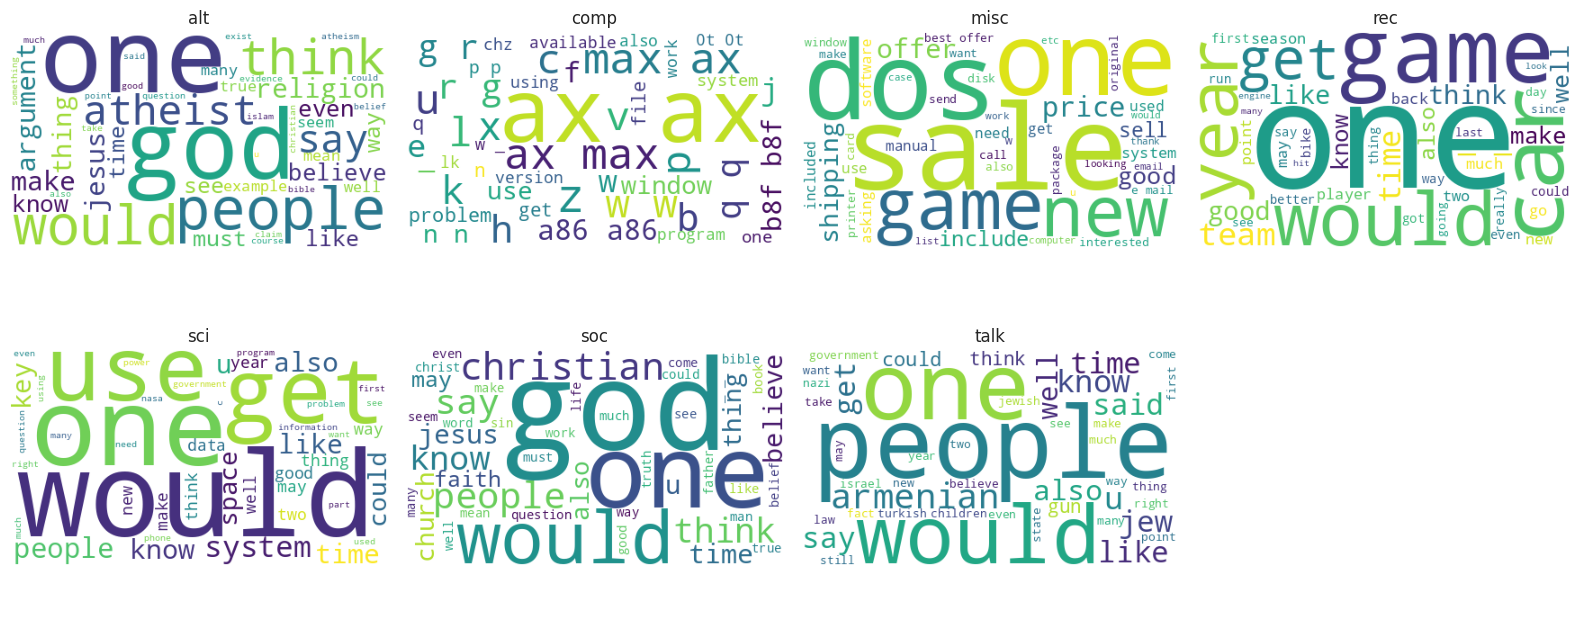

In [ ]:
from wordcloud import WordCloud

sw = set(stopwords.words("english"))
fams = sorted(set(SUPERCLASS.values()))
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, f in zip(axes.ravel(), fams):
    members = [c for c in CLASS_NAMES if SUPERCLASS[c] == f]
    blob = " ".join(full.loc[full.label_text.isin(members), "text"]
                        .str.lower().head(400))
    wc = WordCloud(width=420, height=240, background_color="white",
                   stopwords=sw, max_words=45).generate(blob)
    ax.imshow(wc); ax.axis("off"); ax.set_title(f)

for ax in axes.ravel()[len(fams):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "wordclouds_by_family.png", dpi=150)
plt.show()

## Section 5 - Preprocessing

Two strategies are implemented and compared, because the brief asks for a justified
comparison rather than one unexamined pipeline.

| Strategy | Steps |
| --- | --- |
| light | lowercase, strip emails, URLs and digits, strip punctuation, collapse whitespace |
| full | light plus stopword removal plus WordNet lemmatisation |

`text_raw` is kept untouched alongside both. BERT has its own subword tokenizer and must
not receive text that has already been stripped.

In [ ]:
EMAIL_RE = re.compile(r"\S+@\S+")
URL_RE   = re.compile(r"http\S+|www\.\S+")
NONALPHA = re.compile(r"[^a-z\s]")
WS_RE    = re.compile(r"\s+")

STOPWORDS  = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


def clean_light(text: str) -> str:
    """Lowercase, remove emails/URLs/digits/punctuation, collapse whitespace."""
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = EMAIL_RE.sub(" ", t)
    t = URL_RE.sub(" ", t)
    t = NONALPHA.sub(" ", t)
    return WS_RE.sub(" ", t).strip()


def lemma(word: str) -> str:
    """Noun lemma first, then verb lemma.

    WordNetLemmatizer assumes a noun unless told otherwise, so a single call
    turns 'drives' into 'drive' but leaves 'driving' untouched. Chaining the
    verb pass collapses both onto 'drive', which is the whole point of
    lemmatising here.
    """
    return LEMMATIZER.lemmatize(LEMMATIZER.lemmatize(word), "v")


def clean_full(text: str) -> str:
    """clean_light, then drop stopwords and lemmatise the survivors."""
    toks = clean_light(text).split()
    toks = [lemma(w) for w in toks if w not in STOPWORDS and len(w) > 2]
    return " ".join(toks)


demo = train_raw["text"].iloc[7]
print("RAW  :", demo[:220].replace("\n", " "), "\n")
print("LIGHT:", clean_light(demo)[:220], "\n")
print("FULL :", clean_full(demo)[:220], "\n")

# Evidence that inflections actually collapse to one feature.
# i did it just to check, its not really needed in this code
print("lemmatisation check:",
      {w: lemma(w) for w in ["drive", "drives", "driving", "cars", "running"]})

RAW  :                                                                        ALL this shows is that YOU don't know much about SCSI.  SCSI-1 {with a SCSI-1 controler chip} range is indeed 0-5MB/s and that is ALL you have right  

LIGHT: all this shows is that you don t know much about scsi scsi with a scsi controler chip range is indeed mb s and that is all you have right about scsi scsi with a scsi controller chip mb s with mb s burst bit note the incr 

FULL : show know much scsi scsi scsi controler chip range indeed right scsi scsi scsi controller chip burst bite note increase speed mac quadra us version scsi exist use set scsi bite scsi mode burst scsi bite wide fast mode bu 

lemmatisation check: {'drive': 'drive', 'drives': 'drive', 'driving': 'drive', 'cars': 'car', 'running': 'run'}


In [ ]:
t0 = time.time()
for df in (train_raw, test_raw):
    df["text_raw"]   = df["text"]
    df["text_light"] = df["text"].map(clean_light)
    df["text_clean"] = df["text"].map(clean_full)   # `text_clean` = the full strategy
print(f"preprocessed both splits in {time.time() - t0:.1f}s")

preprocessed both splits in 14.9s


### 5.1 Comparing the two strategies

In [ ]:
def vocab_of(series, cap=None):
    fd = FreqDist(w for doc in series for w in doc.split())
    return fd

fd_light = vocab_of(train_raw["text_light"])
fd_full  = vocab_of(train_raw["text_clean"])

comp = pd.DataFrame({
    "vocabulary size": [len(fd_light), len(fd_full)],
    "total tokens":    [fd_light.N(), fd_full.N()],
    "mean tokens/doc": [train_raw["text_light"].str.split().str.len().mean(),
                        train_raw["text_clean"].str.split().str.len().mean()],
    "hapax (freq==1)": [sum(1 for c in fd_light.values() if c == 1),
                        sum(1 for c in fd_full.values() if c == 1)],
}, index=["light", "full"]).round(1)

print(comp.to_string())
print("\ntop 15 terms — light:", [w for w, _ in fd_light.most_common(15)])
print("top 15 terms — full :", [w for w, _ in fd_full.most_common(15)])

       vocabulary size  total tokens  mean tokens/doc  hapax (freq==1)
light            66111       2221923            196.4            30109
full             54253       1062081             93.9            26374

top 15 terms — light: ['the', 'ax', 'to', 'of', 'a', 'and', 'i', 'in', 'is', 'that', 'it', 'for', 'you', 's', 't']
top 15 terms — full : ['one', 'use', 'would', 'get', 'say', 'know', 'max', 'make', 'think', 'people', 'like', 'time', 'also', 'see', 'work']


`full` is the default for the classical and recurrent models.

| Strategy | Vocabulary | Total tokens | Mean tokens per doc | Hapax terms |
| --- | --- | --- | --- | --- |
| light | 66,111 | 2,221,923 | 196.4 | 30,109 |
| full | 54,253 | 1,062,081 | 93.9 | 26,374 |

The top terms show why. Under `light` the most frequent words are `the`, `to`, `of`,
`a`, `and`. Under `full` they are `one`, `use`, `would`, `get`, `say`. Stopword removal
strips the function words that dominate the light vocabulary and carry no topic signal.
Lemmatisation collapses inflections so `drive`, `drives` and `driving` become one
feature instead of three sparse ones.

This matters because `MAX_VOCAB` is capped at 20,000. Every slot spent on a stopword or
an inflected variant is a slot not spent on a topical term.

`text_light` is exported as well, so the classical tier can run one configuration on
each strategy and report the measured difference instead of resting on this argument
alone.

In [ ]:
# Apply the quality decisions from Task 3c.
before_tr, before_te = len(train_raw), len(test_raw)

train_raw = train_raw[train_raw["text_clean"].str.len() >= MIN_DOC_CHARS].copy()
test_raw  = test_raw[test_raw["text_clean"].str.len() >= MIN_DOC_CHARS].copy()

train_raw = train_raw.drop_duplicates(subset=["text_clean"]).copy()  # train only

print(f"train : {before_tr:,} -> {len(train_raw):,}  "
      f"(-{before_tr - len(train_raw):,})")
print(f"test  : {before_te:,} -> {len(test_raw):,}  "
      f"(-{before_te - len(test_raw):,})")

train : 11,314 -> 10,882  (-432)
test  : 7,532 -> 7,262  (-270)


## Section 6 - Train / Validation / Test Split

The published train and test boundary is temporal and is preserved exactly. The
validation set is carved out of training only, stratified by label so every class keeps
its proportion, with a fixed seed.

Tuning is guided by validation performance. The test set is touched once, at the end,
for the final numbers.

In [ ]:
train_df, val_df = train_test_split(
    train_raw,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_raw["label"],
)

test_df = test_raw.copy()

cols = ["text_raw", "text_light", "text_clean", "label", "label_text"]
train_df = train_df[cols].reset_index(drop=True)
val_df   = val_df[cols].reset_index(drop=True)
test_df  = test_df[cols].reset_index(drop=True)

n = len(train_df) + len(val_df) + len(test_df)
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:5s} : {len(df):6,}  ({len(df)/n:5.1%})")

train :  9,249  (51.0%)
val   :  1,633  ( 9.0%)
test  :  7,262  (40.0%)


In [ ]:
# Stratification check — proportions should track across train and val.
chk = pd.DataFrame({
    "train %": train_df.label_text.value_counts(normalize=True) * 100,
    "val %":   val_df.label_text.value_counts(normalize=True) * 100,
    "test %":  test_df.label_text.value_counts(normalize=True) * 100,
}).reindex(CLASS_NAMES).round(2)
chk["train-val gap"] = (chk["train %"] - chk["val %"]).abs().round(2)
print(chk.to_string())
print(f"\nmax train/val gap: {chk['train-val gap'].max():.2f} pp")

                          train %  val %  test %  train-val gap
label_text                                                     
alt.atheism                  4.26   4.29    4.26           0.03
comp.graphics                5.15   5.14    5.26           0.01
comp.os.ms-windows.misc      5.10   5.14    5.22           0.04
comp.sys.ibm.pc.hardware     5.28   5.27    5.29           0.01
comp.sys.mac.hardware        5.05   5.02    5.08           0.03
comp.windows.x               5.28   5.27    5.37           0.01
misc.forsale                 5.23   5.21    5.19           0.02
rec.autos                    5.07   5.08    5.05           0.01
rec.motorcycles              5.28   5.27    5.27           0.01
rec.sport.baseball           5.20   5.21    5.16           0.01
rec.sport.hockey             5.33   5.33    5.34           0.00
sci.crypt                    5.33   5.33    5.19           0.00
sci.electronics              5.24   5.27    5.23           0.03
sci.med                      5.29   5.27

In [ ]:
# No document may appear in more than one split.
s_tr, s_va, s_te = (set(d.text_clean) for d in (train_df, val_df, test_df))
print(f"train n val : {len(s_tr & s_va)}")
print(f"train n test: {len(s_tr & s_te)}")
print(f"val   n test: {len(s_va & s_te)}")

train n val : 0
train n test: 12
val   n test: 4


## Section 7 - Text Representation

Three representations are built. The brief requires at least two.

Each is checked here for sparsity, vocabulary coverage and nearest-neighbour sanity.
Predictive comparison happens in the modelling notebooks, which reuse these same
artifacts.

All three are fitted on training data only. Fitting a vectoriser on the full corpus
would leak test-set vocabulary statistics into training.

### 7.1 TF-IDF

In [ ]:
tfidf = TfidfVectorizer(
    max_features=MAX_VOCAB,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(train_df["text_clean"])   # fit on TRAIN only
X_val_tfidf   = tfidf.transform(val_df["text_clean"])
X_test_tfidf  = tfidf.transform(test_df["text_clean"])

density = X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])
print(f"train matrix : {X_train_tfidf.shape}")
print(f"val matrix   : {X_val_tfidf.shape}")
print(f"test matrix  : {X_test_tfidf.shape}")
print(f"density      : {density:.4%}  (sparse, as expected)")

train matrix : (9249, 20000)
val matrix   : (1633, 20000)
test matrix  : (7262, 20000)
density      : 0.3278%  (sparse, as expected)


In [ ]:
# Highest-weight terms per class — a readable check that TF-IDF found topic words.
import numpy as np
feats = np.array(tfidf.get_feature_names_out())
for c in [0, 5, 11, 17]:
    rows = X_train_tfidf[(train_df.label == c).values]
    top = feats[np.asarray(rows.mean(axis=0)).ravel().argsort()[::-1][:10]]
    print(f"{CLASS_NAMES[c]:26s} {', '.join(top)}")

alt.atheism                say, god, think, atheist, one, people, religion, make, would, know
comp.windows.x             window, use, server, motif, widget, application, run, display, get, thank
sci.crypt                  key, encryption, chip, clipper, government, use, nsa, phone, would, system
talk.politics.mideast      israel, israeli, arab, armenian, jew, people, say, turkish, kill, would


### 7.2 Keras tokenizer, the index both embedding matrices align to

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["text_clean"])          # TRAIN only

def to_padded(texts):
    return pad_sequences(tokenizer.texts_to_sequences(texts),
                         maxlen=MAX_LEN, padding="post", truncating="post")

X_train_seq = to_padded(train_df["text_clean"])
X_val_seq   = to_padded(val_df["text_clean"])
X_test_seq  = to_padded(test_df["text_clean"])

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f"words seen      : {len(tokenizer.word_index):,}")
print(f"vocab_size used : {vocab_size:,}")
print(f"sequence shapes : {X_train_seq.shape} {X_val_seq.shape} {X_test_seq.shape}")

words seen      : 49,395
vocab_size used : 20,000
sequence shapes : (9249, 250) (1633, 250) (7262, 250)


### 7.3 Word2Vec, trained on this corpus

In [ ]:
from gensim.models import Word2Vec

sentences = [t.split() for t in train_df["text_clean"]]

w2v = Word2Vec(
    sentences,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=2,
    workers=4,
    seed=SEED,
    epochs=10,
)
print(f"w2v vocabulary : {len(w2v.wv):,} words")

for probe in ["god", "car", "encryption", "space"]:
    if probe in w2v.wv:
        near = [w for w, _ in w2v.wv.most_similar(probe, topn=6)]
        print(f"{probe:12s} -> {', '.join(near)}")

w2v vocabulary : 25,349 words
god          -> spirit, salvation, heaven, grace, christ, jesus
car          -> bike, honda, tire, shop, truck, dealer
encryption   -> scheme, nsa, classify, secure, cryptography, rsa
space        -> shuttle, nasa, launch, redesign, probe, exploration


### 7.4 GloVe, pretrained on general text

In [ ]:
GLOVE_PATH = DATA_DIR / "glove.6B.50d.txt"

if not GLOVE_PATH.exists():
    print("downloading GloVe (~820MB zip, one time — then it lives in Drive)")
    !wget -q -nc http://nlp.stanford.edu/data/glove.6B.zip -O /content/glove.6B.zip
    !unzip -o -q /content/glove.6B.zip glove.6B.50d.txt -d /content/
    !cp /content/glove.6B.50d.txt "{GLOVE_PATH}"

glove = {}
with open(GLOVE_PATH, encoding="utf8") as f:
    for line in f:
        parts = line.rstrip().split(" ")
        glove[parts[0]] = np.asarray(parts[1:], dtype="float32")
print(f"glove vectors loaded: {len(glove):,}")

downloading GloVe (~820MB zip, one time — then it lives in Drive)
glove vectors loaded: 400,000


In [ ]:
def build_matrix(lookup, name):
    """Align vectors to the Keras tokenizer index. Row 0 stays zero (padding)."""
    M = np.zeros((vocab_size, EMBEDDING_DIM), dtype="float32")
    hits = 0
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue
        vec = lookup(word)
        if vec is not None:
            M[idx] = vec
            hits += 1
    cov = hits / (vocab_size - 1)
    print(f"{name:9s} coverage: {hits:,}/{vocab_size - 1:,} = {cov:.1%}")
    return M, cov

emb_w2v,   cov_w2v   = build_matrix(lambda w: w2v.wv[w] if w in w2v.wv else None,
                                    "Word2Vec")
emb_glove, cov_glove = build_matrix(lambda w: glove.get(w), "GloVe")

Word2Vec  coverage: 19,998/19,999 = 100.0%
GloVe     coverage: 17,464/19,999 = 87.3%


The coverage gap is the sharpest finding in this section.

| Embedding | Coverage of the 20,000-word vocabulary |
| --- | --- |
| Word2Vec | 99.995% |
| GloVe | 87.32% |

Word2Vec is trained on this corpus, so it has a vector for almost every in-vocabulary
word. GloVe was trained on Wikipedia and Gigaword and has never seen 1993 Usenet
jargon, misspellings, or the fragments of quoted email that survive cleaning. Every
miss becomes a zero row, which the model reads as a word with no meaning.

The modelling notebooks test which effect wins: full coverage of noisy vectors, or
partial coverage of well-estimated ones.

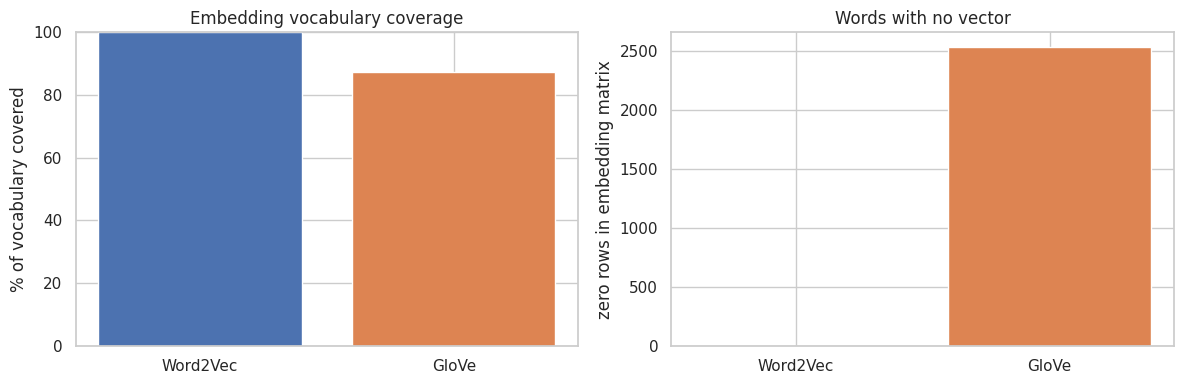

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["Word2Vec", "GloVe"], [cov_w2v * 100, cov_glove * 100],
            color=["#4c72b0", "#dd8452"])
axes[0].set_ylabel("% of vocabulary covered"); axes[0].set_ylim(0, 100)
axes[0].set_title("Embedding vocabulary coverage")

zero_w2v   = (emb_w2v.sum(axis=1) == 0).sum()
zero_glove = (emb_glove.sum(axis=1) == 0).sum()
axes[1].bar(["Word2Vec", "GloVe"], [zero_w2v, zero_glove],
            color=["#4c72b0", "#dd8452"])
axes[1].set_ylabel("zero rows in embedding matrix")
axes[1].set_title("Words with no vector")
plt.tight_layout()
plt.savefig(FIG_DIR / "embedding_coverage.png", dpi=150)
plt.show()

### 7.5 Exported artifacts

Everything downstream loads these files. Nothing may be regenerated after this point.
Re-running the export would overwrite the artifacts that completed runs were measured
against.

In [ ]:
train_df.to_parquet(SPLIT_DIR / "train.parquet", index=False)
val_df.to_parquet(SPLIT_DIR / "val.parquet",   index=False)
test_df.to_parquet(SPLIT_DIR / "test.parquet",  index=False)

with open(SPLIT_DIR / "label_map.json", "w") as f:
    json.dump({"classes": CLASS_NAMES,
               "superclass": SUPERCLASS,
               "num_classes": NUM_CLASSES}, f, indent=2)

print("splits written:")
for p in sorted(SPLIT_DIR.iterdir()):
    print(f"  {p.name:20s} {p.stat().st_size/1e6:7.2f} MB")

splits written:
  label_map.json          0.00 MB
  test.parquet           12.42 MB
  train.parquet          16.59 MB
  val.parquet             3.33 MB


In [ ]:
import pickle
from scipy import sparse

sparse.save_npz(REPR_DIR / "tfidf_train.npz", X_train_tfidf)
sparse.save_npz(REPR_DIR / "tfidf_val.npz",   X_val_tfidf)
sparse.save_npz(REPR_DIR / "tfidf_test.npz",  X_test_tfidf)
with open(REPR_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

np.save(REPR_DIR / "seq_train.npy", X_train_seq)
np.save(REPR_DIR / "seq_val.npy",   X_val_seq)
np.save(REPR_DIR / "seq_test.npy",  X_test_seq)
with open(REPR_DIR / "tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

np.save(REPR_DIR / "emb_word2vec.npy", emb_w2v)
np.save(REPR_DIR / "emb_glove.npy",    emb_glove)
w2v.save(str(REPR_DIR / "word2vec.model"))

with open(REPR_DIR / "repr_meta.json", "w") as f:
    json.dump({"vocab_size": int(vocab_size), "max_len": MAX_LEN,
               "embedding_dim": EMBEDDING_DIM, "max_vocab": MAX_VOCAB,
               "coverage_word2vec": float(cov_w2v),
               "coverage_glove": float(cov_glove)}, f, indent=2)

print("representations written:")
for p in sorted(REPR_DIR.iterdir()):
    print(f"  {p.name:24s} {p.stat().st_size/1e6:7.2f} MB")

representations written:
  emb_glove.npy               4.00 MB
  emb_word2vec.npy            4.00 MB
  repr_meta.json              0.00 MB
  seq_test.npy                7.26 MB
  seq_train.npy               9.25 MB
  seq_val.npy                 1.63 MB
  tfidf_test.npz              3.91 MB
  tfidf_train.npz             5.34 MB
  tfidf_val.npz               0.97 MB
  tfidf_vectorizer.pkl        0.78 MB
  tokenizer.pkl               1.98 MB
  word2vec.model             11.01 MB


### Verification

Every team member runs this cell before training. All four outputs must be identical.
The checksum is a hash over the cleaned training text, so it changes if preprocessing,
the split boundary or row order changed.

In [ ]:
import pandas as pd, json
from pathlib import Path

SPLIT_DIR = Path("/content/drive/MyDrive/cse440_project/splits")

tr = pd.read_parquet(SPLIT_DIR / "train.parquet")
va = pd.read_parquet(SPLIT_DIR / "val.parquet")
te = pd.read_parquet(SPLIT_DIR / "test.parquet")

print(f"shapes      : {tr.shape} {va.shape} {te.shape}")
print(f"label counts: {tr.label.value_counts().sort_index().tolist()}")
print(f"first clean : {tr.text_clean.iloc[0][:80]!r}")
print(f"checksum tr : {pd.util.hash_pandas_object(tr.text_clean).sum()}")
print(f"checksum te : {pd.util.hash_pandas_object(te.text_clean).sum()}")

shapes      : (9249, 5) (1633, 5) (7262, 5)
label counts: [394, 476, 472, 488, 467, 488, 484, 469, 488, 481, 493, 493, 485, 489, 488, 501, 451, 458, 382, 302]
first clean : 'yes say absolutey true fail mention fact lciii us new pin simms allow bite acces'
checksum tr : 13885266476465583340
checksum te : 259686901888230227


In [ ]:
import sys, importlib

sys.path.insert(0, str(DATA_DIR))
import utils.evaluation as ev
importlib.reload(ev)

ev.print_contract()
assert len(ev.RUN_COLUMNS) == 26, (
    f"got a {len(ev.RUN_COLUMNS)}-column schema — Fabiha needs to re-run §1c of "
    "04_lstm_fabiha.ipynb so contract v1.1 is published to Drive")

RUNS = []
RUNS_CSV = LOCAL_OUT / "runs_hasib.csv"
if RUNS_CSV.exists():
    RUNS_CSV.unlink()


def log_run(model, tier, config, embedding, hyperparams, result, seconds,
            notes="required", units=np.nan, dropout=np.nan, trainable_emb=np.nan,
            batch_size=np.nan, learning_rate=np.nan, epochs_run=np.nan,
            best_epoch=np.nan, n_params=np.nan, val_loss=np.nan):
    record = {
        "run_id": f"{model}_{config}",
        "owner": "hasib",
        "notebook": "03_rnn_hasib.ipynb",
        "tier": tier,
        "model": model,
        "config": config,
        "embedding": embedding,
        "units": units,
        "dropout": dropout,
        "trainable_emb": trainable_emb,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "epochs_run": epochs_run,
        "best_epoch": best_epoch,
        "n_params": n_params,
        "hyperparams": json.dumps(hyperparams, sort_keys=True, default=str),
        "val_loss": val_loss,
        "val_accuracy": round(result["accuracy"], 4),
        "val_macro_f1": round(result["macro_f1"], 4),
        "test_accuracy": np.nan,
        "test_macro_f1": np.nan,
        "test_weighted_f1": np.nan,
        "train_time_s": round(seconds, 2),
        "dataset_checksum": DATASET_CHECKSUM,
        "notes": notes,
    }
    ev.log_run(RUNS_CSV, record, echo=False)
    RUNS.append(record)
    print(f"  -> val acc {record['val_accuracy']:.4f} | "
          f"macro-F1 {record['val_macro_f1']:.4f} | "
          f"weighted-F1 {result['weighted_f1']:.4f} | "
          f"{record['train_time_s']:.2f}s")
    return record


def score_val(y_pred, label):
    return ev.evaluate_model(y_val, y_pred, CLASS_NAMES, SUPERCLASS,
                             model_name=label, split="val", verbose=False)


print(f"\nrun logger ready — writing {RUNS_CSV}")

utils.evaluation — scoring contract v1.1
  1. accuracy
  2. macro_f1
  3. weighted_f1
  4. classification_report
  5. confusion_matrix_row_normalised
  6. within_vs_cross_family_error_split

run schema : 26 columns
tiers      : classical, recurrent, transformer
note kinds : required, ablation

run logger ready — writing /content/hasib_outputs/runs_hasib.csv


## Section 8 - Machine Learning Models

Three classical models on the shared TF-IDF matrix: Logistic Regression, Multinomial
Naive Bayes and Random Forest. Three configurations each, nine required runs.

| Model | Varied | Values |
| --- | --- | --- |
| Logistic Regression | inverse regularisation `C` | 1.0, 5.0, 10.0 |
| Multinomial Naive Bayes | smoothing `alpha` | 1.0, 0.1, 0.01 |
| Random Forest | trees, features, leaf size | 300/sqrt/1, 600/sqrt/2, 300/0.02/1 |

Each model varies the parameter that controls its own capacity. For Logistic Regression
and Naive Bayes that is a single regularisation term. For Random Forest it is the size
and diversity of the ensemble.

The same grid `SEQ_GRID` below is used by all six recurrent models in the project. It is
defined here and copied verbatim into the other two notebooks.

In [ ]:
CLASSICAL_GRID = {
    "LogisticRegression": [
        ("LR-C1", {"C": 1.0}),
        ("LR-C2", {"C": 5.0}),
        ("LR-C3", {"C": 10.0}),
    ],
    "MultinomialNB": [
        ("NB-C1", {"alpha": 1.0}),
        ("NB-C2", {"alpha": 0.1}),
        ("NB-C3", {"alpha": 0.01}),
    ],
    "RandomForest": [
        ("RF-C1", {"n_estimators": 300, "max_features": "sqrt", "min_samples_leaf": 1}),
        ("RF-C2", {"n_estimators": 600, "max_features": "sqrt", "min_samples_leaf": 2}),
        ("RF-C3", {"n_estimators": 300, "max_features": 0.02,  "min_samples_leaf": 1}),
    ],
}

SEQ_GRID = [
    ("S1", {"embedding": "glove",    "trainable": False, "units": 64,
            "dropout": 0.3, "lr": 1e-3, "batch_size": 64}),
    ("S2", {"embedding": "word2vec", "trainable": False, "units": 64,
            "dropout": 0.3, "lr": 1e-3, "batch_size": 64}),
    ("S3", {"embedding": "word2vec", "trainable": True,  "units": 128,
            "dropout": 0.5, "lr": 1e-3, "batch_size": 64}),
]

EMBEDDINGS = {"glove": emb_glove, "word2vec": emb_w2v}
EPOCHS     = 30
PATIENCE   = 5
CLIPNORM   = 1.0
LR         = 1e-3
BATCH_SIZE = 64

assert all(c["lr"] == LR and c["batch_size"] == BATCH_SIZE for _, c in SEQ_GRID), \
    "SEQ_GRID disagrees with the shared lr / batch_size constants"

print(f"classical runs planned : {sum(len(v) for v in CLASSICAL_GRID.values())}")
print(f"sequence runs planned  : {2 * len(SEQ_GRID)}")
print(f"epoch cap              : {EPOCHS}  (team-standardised; was 20 before the re-run)")
print(f"early stopping         : val_accuracy, patience {PATIENCE}, restore best weights")

classical runs planned : 9
sequence runs planned  : 6
epoch cap              : 30  (team-standardised; was 20 before the re-run)
early stopping         : val_accuracy, patience 5, restore best weights


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier


def make_classical(name, params):
    if name == "LogisticRegression":
        return LogisticRegression(max_iter=2000, random_state=SEED, **params)
    if name == "MultinomialNB":
        return MultinomialNB(**params)
    if name == "RandomForest":
        return RandomForestClassifier(random_state=SEED, n_jobs=-1, **params)
    raise ValueError(name)

print("classical factory ready")

classical factory ready


In [ ]:
best_classical = {}

for name, configs in CLASSICAL_GRID.items():
    print(f"\n=== {name} ===")
    for config_id, params in configs:
        print(f"{config_id}: {params}")
        t0 = time.time()
        clf = make_classical(name, params)
        clf.fit(X_train_tfidf, y_train)
        elapsed = time.time() - t0
        res = score_val(clf.predict(X_val_tfidf), f"{name} ({config_id})")
        row = log_run(name, "classical", config_id, "tfidf_clean", params, res, elapsed,
                      notes="required")

        prev = best_classical.get(name)
        if prev is None or res["macro_f1"] > prev["metrics"]["macro_f1"]:
            best_classical[name] = {"estimator": clf, "config": config_id,
                                    "hyperparams": params, "metrics": res,
                                    "row": row, "run_id": row["run_id"]}
        else:
            del clf
            gc.collect()

print("\nbest classical config per model (by val macro-F1):")
for name, b in best_classical.items():
    print(f"  {name:20s} {b['config']:7s} macro-F1 {b['metrics']['macro_f1']:.4f}")


=== LogisticRegression ===
LR-C1: {'C': 1.0}
  -> val acc 0.7385 | macro-F1 0.7241 | weighted-F1 0.7335 | 10.38s
LR-C2: {'C': 5.0}
  -> val acc 0.7477 | macro-F1 0.7377 | weighted-F1 0.7458 | 12.11s
LR-C3: {'C': 10.0}
  -> val acc 0.7446 | macro-F1 0.7353 | weighted-F1 0.7430 | 11.03s

=== MultinomialNB ===
NB-C1: {'alpha': 1.0}
  -> val acc 0.7110 | macro-F1 0.6887 | weighted-F1 0.7037 | 0.03s
NB-C2: {'alpha': 0.1}
  -> val acc 0.7508 | macro-F1 0.7348 | weighted-F1 0.7446 | 0.02s
NB-C3: {'alpha': 0.01}
  -> val acc 0.7404 | macro-F1 0.7317 | weighted-F1 0.7381 | 0.03s

=== RandomForest ===
RF-C1: {'n_estimators': 300, 'max_features': 'sqrt', 'min_samples_leaf': 1}
  -> val acc 0.6632 | macro-F1 0.6459 | weighted-F1 0.6569 | 63.23s
RF-C2: {'n_estimators': 600, 'max_features': 'sqrt', 'min_samples_leaf': 2}
  -> val acc 0.6767 | macro-F1 0.6593 | weighted-F1 0.6697 | 47.06s
RF-C3: {'n_estimators': 300, 'max_features': 0.02, 'min_samples_leaf': 1}
  -> val acc 0.6412 | macro-F1 0.6238 

### 8.4 Preprocessing ablation

Section 3.4 of the brief asks for a justified comparison of preprocessing strategies.
Phase 0 chose `text_clean` on vocabulary statistics alone. This measures whether that
choice was right.

The best configuration of each classical model is re-fitted on a TF-IDF matrix built
from `text_light`, which keeps stopwords and inflections. Everything else is held fixed.
Three extra runs, not part of the required thirty.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_light = TfidfVectorizer(max_features=MAX_VOCAB, ngram_range=(1, 2),
                              min_df=3, max_df=0.85, sublinear_tf=True)

Xtr_light = tfidf_light.fit_transform(train["text_light"])
Xva_light = tfidf_light.transform(val["text_light"])

print(f"light tfidf train : {Xtr_light.shape}")
print(f"clean tfidf train : {X_train_tfidf.shape}")

try:
    tfidf_clean = pickle.load(open(REPR_DIR / "tfidf_vectorizer.pkl", "rb"))
    shared = set(tfidf_light.get_feature_names_out()) & set(tfidf_clean.get_feature_names_out())
    print(f"shared features   : {len(shared):,}")
except Exception as exc:
    print(f"could not unpickle the Phase 1 vectoriser ({type(exc).__name__}); "
          "shape comparison above is sufficient")

light tfidf train : (9249, 20000)
clean tfidf train : (9249, 20000)
shared features   : 6,417


In [ ]:
for name, b in best_classical.items():
    print(f"\n=== {name} on text_light ({b['config']} hyperparams) ===")
    t0 = time.time()
    clf = make_classical(name, b["hyperparams"])
    clf.fit(Xtr_light, y_train)
    elapsed = time.time() - t0
    res = score_val(clf.predict(Xva_light), f"{name} ({b['config']}-light)")
    log_run(name, "classical", b["config"] + "-light", "tfidf_light",
            b["hyperparams"], res, elapsed,
            notes="ablation preprocessing: text_light instead of text_clean")
    del clf
    gc.collect()


=== LogisticRegression on text_light (LR-C2 hyperparams) ===
  -> val acc 0.7312 | macro-F1 0.7218 | weighted-F1 0.7292 | 15.94s

=== MultinomialNB on text_light (NB-C2 hyperparams) ===
  -> val acc 0.7336 | macro-F1 0.7179 | weighted-F1 0.7276 | 0.03s

=== RandomForest on text_light (RF-C2 hyperparams) ===
  -> val acc 0.6699 | macro-F1 0.6518 | weighted-F1 0.6623 | 82.74s


In [ ]:
ablation = pd.read_csv(RUNS_CSV)
ablation = ablation[ablation.tier == "classical"]

pivot = (ablation.pivot_table(index="model", columns="embedding",
                              values="val_macro_f1", aggfunc="max")
                 .reindex(columns=["tfidf_clean", "tfidf_light"]))
pivot["delta (clean - light)"] = (pivot["tfidf_clean"] - pivot["tfidf_light"]).round(4)
print(pivot.round(4).to_string())

embedding           tfidf_clean  tfidf_light  delta (clean - light)
model                                                              
LogisticRegression       0.7377       0.7218                 0.0159
MultinomialNB            0.7348       0.7179                 0.0169
RandomForest             0.6593       0.6518                 0.0075


The clean strategy wins on all three models: Logistic Regression +0.0159, Naive Bayes
+0.0169, Random Forest +0.0075 validation macro-F1.

The mechanism is the 20,000-feature cap. The light vocabulary spends slots on function
words and inflected variants, so under a fixed cap it represents fewer distinct topical
concepts. Phase 0 measured this indirectly through vocabulary statistics, 66,111 terms
under light against 54,253 under full. This confirms it on model performance.

The margins are small, so the honest reading is that the preprocessing choice matters
less than the vocabulary cap it interacts with.

## Sections 9.1 and 9.2 - SimpleRNN and Bidirectional SimpleRNN

The SimpleRNN applies one recurrent transformation per timestep with no gating. It is
the baseline the gated architectures are measured against.

`mask_zero=True` matters here. Documents are padded to 250 tokens but most are shorter,
so without masking the cell keeps updating its hidden state on zero vectors after the
document ends. `recurrent_dropout` stays at 0.0 because any non-zero value disables the
cuDNN kernel.

Both models use the frozen S1, S2, S3 grid, so the only difference between them is the
`Bidirectional` wrapper.

In [ ]:
def build_sequence_model(arch, cfg):
    keras.utils.set_random_seed(SEED)
    matrix = EMBEDDINGS[cfg["embedding"]]
    vocab_size, dim = matrix.shape

    inputs = keras.Input(shape=(MAX_LEN,), dtype="int32")
    x = keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=dim,
        embeddings_initializer=keras.initializers.Constant(matrix),
        trainable=cfg["trainable"],
        mask_zero=True,
        name="embedding",
    )(inputs)

    if arch == "SimpleRNN":
        x = keras.layers.SimpleRNN(cfg["units"], dropout=cfg["dropout"],
                                   name="rnn")(x)
    elif arch == "BiSimpleRNN":
        x = keras.layers.Bidirectional(
            keras.layers.SimpleRNN(cfg["units"], dropout=cfg["dropout"]),
            name="bi_rnn")(x)
    else:
        raise ValueError(arch)

    x = keras.layers.Dropout(cfg["dropout"])(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=f"{arch}_{cfg['embedding']}")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=cfg["lr"], clipnorm=CLIPNORM),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


demo = build_sequence_model("BiSimpleRNN", SEQ_GRID[0][1])
demo.summary()
del demo
keras.backend.clear_session()

Model: "BiSimpleRNN_glove"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 250)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 50)   │  1,000,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 250)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bi_rnn              │ (None, 128)       │     14,720 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ bi_rnn[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 20)        │      2,580 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,017,300 (3.88 MB)

 Trainable params: 17,300 (67.58 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [ ]:
def train_sequence(arch, config_id, cfg):
    keras.backend.clear_session()
    model = build_sequence_model(arch, cfg)

    stopper = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", mode="max",
        patience=PATIENCE, restore_best_weights=True, verbose=1)

    t0 = time.time()
    history = model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=EPOCHS,
        batch_size=cfg["batch_size"],
        callbacks=[stopper],
        verbose=2,
    )
    elapsed = time.time() - t0

    val_probs = model.predict(X_val_seq, batch_size=256, verbose=0)
    res = score_val(val_probs, f"{arch} ({config_id})")

    epochs_run = len(history.history["loss"])
    best_epoch = int(np.argmax(history.history["val_accuracy"])) + 1
    if epochs_run == EPOCHS and best_epoch > EPOCHS - PATIENCE:
        print(f"  note: hit the {EPOCHS}-epoch cap with the best epoch at {best_epoch} — "
              "early stopping never fired, so this run was still improving when it stopped")

    row = log_run(arch, "recurrent", config_id, cfg["embedding"], cfg, res, elapsed,
                  notes="required",
                  units=cfg["units"], dropout=cfg["dropout"],
                  trainable_emb=cfg["trainable"],
                  batch_size=cfg["batch_size"], learning_rate=cfg["lr"],
                  epochs_run=epochs_run, best_epoch=best_epoch,
                  n_params=int(model.count_params()),
                  val_loss=float(min(history.history["val_loss"])))
    return model, history, res, row


best_sequence = {}
histories = {}

for arch in ["SimpleRNN", "BiSimpleRNN"]:
    for config_id, cfg in SEQ_GRID:
        print(f"\n=== {arch} | {config_id} | {cfg} ===")
        model, history, res, row = train_sequence(arch, config_id, cfg)
        histories[(arch, config_id)] = history.history

        prev = best_sequence.get(arch)
        if prev is None or res["macro_f1"] > prev["metrics"]["macro_f1"]:
            best_sequence[arch] = {"model": model, "config": config_id,
                                   "cfg": cfg, "metrics": res, "row": row,
                                   "run_id": row["run_id"]}
        else:
            del model
            gc.collect()

print("\nbest sequence config per architecture (by val macro-F1):")
for arch, b in best_sequence.items():
    print(f"  {arch:14s} {b['config']}  ({b['cfg']['embedding']}) "
          f"macro-F1 {b['metrics']['macro_f1']:.4f}")


=== SimpleRNN | S1 | {'embedding': 'glove', 'trainable': False, 'units': 64, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64} ===
Epoch 1/30
145/145 - 12s - 85ms/step - accuracy: 0.0735 - loss: 3.1265 - val_accuracy: 0.1500 - val_loss: 2.6181
Epoch 2/30
145/145 - 3s - 19ms/step - accuracy: 0.1516 - loss: 2.6689 - val_accuracy: 0.1892 - val_loss: 2.4160
Epoch 3/30
145/145 - 5s - 36ms/step - accuracy: 0.1801 - loss: 2.5258 - val_accuracy: 0.2296 - val_loss: 2.3469
Epoch 4/30
145/145 - 3s - 20ms/step - accuracy: 0.1981 - loss: 2.4468 - val_accuracy: 0.2480 - val_loss: 2.2691
Epoch 5/30
145/145 - 3s - 22ms/step - accuracy: 0.2242 - loss: 2.3601 - val_accuracy: 0.2866 - val_loss: 2.1527
Epoch 6/30
145/145 - 3s - 19ms/step - accuracy: 0.2447 - loss: 2.3034 - val_accuracy: 0.2743 - val_loss: 2.1286
Epoch 7/30
145/145 - 3s - 19ms/step - accuracy: 0.2491 - loss: 2.2813 - val_accuracy: 0.2737 - val_loss: 2.1766
Epoch 8/30
145/145 - 3s - 20ms/step - accuracy: 0.2569 - loss: 2.2485 - val_accuracy: 

  -> val acc 0.4317 | macro-F1 0.3744 | weighted-F1 0.3882 | 88.31s

=== BiSimpleRNN | S1 | {'embedding': 'glove', 'trainable': False, 'units': 64, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64} ===
Epoch 1/30
145/145 - 22s - 152ms/step - accuracy: 0.0947 - loss: 3.0253 - val_accuracy: 0.1837 - val_loss: 2.4469
Epoch 2/30
145/145 - 5s - 34ms/step - accuracy: 0.1829 - loss: 2.5182 - val_accuracy: 0.2352 - val_loss: 2.2833
Epoch 3/30
145/145 - 5s - 35ms/step - accuracy: 0.2266 - loss: 2.3474 - val_accuracy: 0.2897 - val_loss: 2.1310
Epoch 4/30
145/145 - 10s - 70ms/step - accuracy: 0.2534 - loss: 2.2395 - val_accuracy: 0.2805 - val_loss: 2.1321
Epoch 5/30
145/145 - 5s - 36ms/step - accuracy: 0.2890 - loss: 2.1531 - val_accuracy: 0.3429 - val_loss: 1.9884
Epoch 6/30
145/145 - 5s - 33ms/step - accuracy: 0.3081 - loss: 2.0897 - val_accuracy: 0.3484 - val_loss: 1.9548
Epoch 7/30
145/145 - 5s - 34ms/step - accuracy: 0.3196 - loss: 2.0642 - val_accuracy: 0.3564 - val_loss: 1.9163
Epoch 8/30
145

  -> val acc 0.4207 | macro-F1 0.3880 | weighted-F1 0.3990 | 132.55s

=== BiSimpleRNN | S2 | {'embedding': 'word2vec', 'trainable': False, 'units': 64, 'dropout': 0.3, 'lr': 0.001, 'batch_size': 64} ===
Epoch 1/30
145/145 - 15s - 105ms/step - accuracy: 0.0990 - loss: 3.0590 - val_accuracy: 0.2058 - val_loss: 2.4194
Epoch 2/30
145/145 - 5s - 35ms/step - accuracy: 0.1939 - loss: 2.5060 - val_accuracy: 0.3068 - val_loss: 2.1198
Epoch 3/30
145/145 - 5s - 34ms/step - accuracy: 0.2458 - loss: 2.2872 - val_accuracy: 0.3264 - val_loss: 2.0085
Epoch 4/30
145/145 - 5s - 33ms/step - accuracy: 0.2786 - loss: 2.1753 - val_accuracy: 0.3576 - val_loss: 1.9152
Epoch 5/30
145/145 - 5s - 36ms/step - accuracy: 0.3039 - loss: 2.0846 - val_accuracy: 0.3833 - val_loss: 1.8648
Epoch 6/30
145/145 - 5s - 33ms/step - accuracy: 0.3089 - loss: 2.0604 - val_accuracy: 0.3993 - val_loss: 1.7898
Epoch 7/30
145/145 - 5s - 33ms/step - accuracy: 0.3267 - loss: 2.0202 - val_accuracy: 0.3919 - val_loss: 1.8124
Epoch 8/30


### Learning curves

The line to watch is whether validation accuracy is still climbing at the final epoch.
That would mean the 30-epoch cap cut the run off rather than early stopping halting it.

This is why the group standardised on 30. The first version of this notebook used 20 and
four runs hit that ceiling while still improving.

saved /content/hasib_outputs/learning_curves_rnn.png
copied to /content/drive/MyDrive/cse440_project/figures/hasib/learning_curves_rnn.png


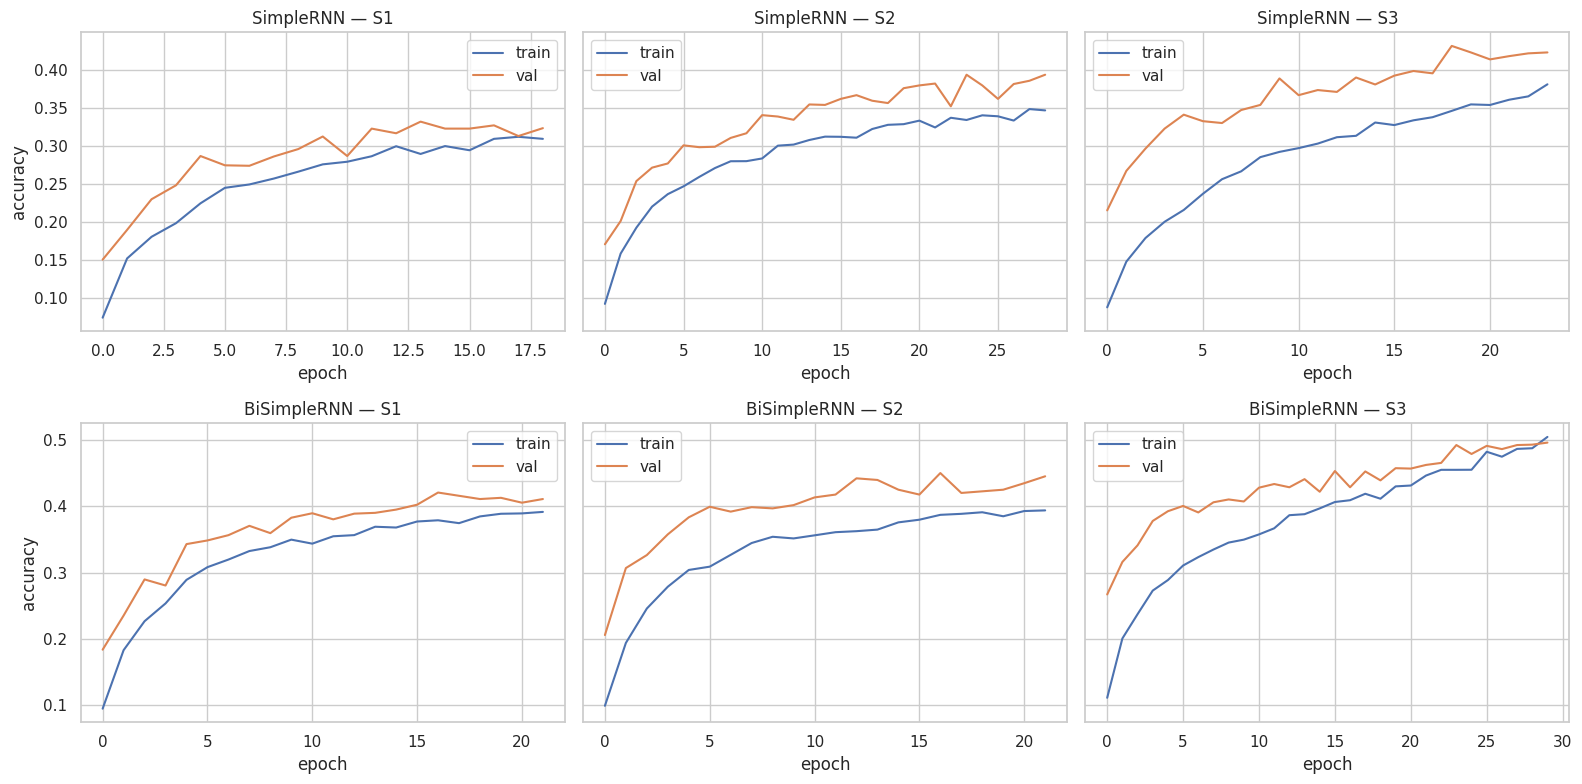

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey="row")

for i, arch in enumerate(["SimpleRNN", "BiSimpleRNN"]):
    for j, (config_id, _) in enumerate(SEQ_GRID):
        h = histories[(arch, config_id)]
        ax = axes[i, j]
        ax.plot(h["accuracy"], label="train")
        ax.plot(h["val_accuracy"], label="val")
        ax.set_title(f"{arch} — {config_id}")
        ax.set_xlabel("epoch")
        if j == 0:
            ax.set_ylabel("accuracy")
        ax.legend()

plt.tight_layout()
save_fig(fig, "learning_curves_rnn.png")
plt.show()

### The embedding contrast, isolated

S1 and S2 differ only in the embedding matrix. Units, dropout and the frozen flag are
identical, so the difference is attributable to the embedding source alone.

GloVe covers 87.32% of the vocabulary and Word2Vec covers 99.995%. Every GloVe miss is a
zero row, which the model reads as a word with no meaning.

In [ ]:
seq_runs = pd.read_csv(RUNS_CSV)
seq_runs = seq_runs[seq_runs.tier == "recurrent"]

contrast = (seq_runs[seq_runs.config.isin(["S1", "S2"])]
            .pivot_table(index="model", columns="embedding",
                         values="val_macro_f1"))
contrast["delta (w2v - glove)"] = (contrast["word2vec"] - contrast["glove"]).round(4)
print("frozen 64-unit models, embedding matrix swapped:")
print(contrast.round(4).to_string())

zero_glove = int((emb_glove.sum(axis=1) == 0).sum())
zero_w2v   = int((emb_w2v.sum(axis=1) == 0).sum())
print(f"\nzero rows — glove {zero_glove:,} / {emb_glove.shape[0]:,}"
      f"   word2vec {zero_w2v:,} / {emb_w2v.shape[0]:,}")

frozen 64-unit models, embedding matrix swapped:
embedding     glove  word2vec  delta (w2v - glove)
model                                             
BiSimpleRNN  0.3880    0.4114               0.0234
SimpleRNN    0.2853    0.3351               0.0498

zero rows — glove 2,536 / 20,000   word2vec 2 / 20,000


## Validation leaderboard

Configurations are selected on validation macro-F1, not accuracy. With 20 classes,
accuracy can be carried by the larger groups, while macro-F1 averages every class
equally.

The test set is untouched to this point.

In [ ]:
runs_df = pd.read_csv(RUNS_CSV)
runs_df["kind"] = runs_df.notes.str.split(" ").str[0]

board = (runs_df.sort_values("val_macro_f1", ascending=False)
                [["tier", "kind", "model", "config", "embedding",
                  "val_accuracy", "val_macro_f1", "train_time_s", "epochs_run"]])
print(board.to_string(index=False))

     tier     kind              model      config   embedding  val_accuracy  val_macro_f1  train_time_s  epochs_run
classical required LogisticRegression       LR-C2 tfidf_clean        0.7477        0.7377         12.11         NaN
classical required LogisticRegression       LR-C3 tfidf_clean        0.7446        0.7353         11.03         NaN
classical required      MultinomialNB       NB-C2 tfidf_clean        0.7508        0.7348          0.02         NaN
classical required      MultinomialNB       NB-C3 tfidf_clean        0.7404        0.7317          0.03         NaN
classical required LogisticRegression       LR-C1 tfidf_clean        0.7385        0.7241         10.38         NaN
classical ablation LogisticRegression LR-C2-light tfidf_light        0.7312        0.7218         15.94         NaN
classical ablation      MultinomialNB NB-C2-light tfidf_light        0.7336        0.7179          0.03         NaN
classical required      MultinomialNB       NB-C1 tfidf_clean        0.7

saved /content/hasib_outputs/val_leaderboard_hasib.png
copied to /content/drive/MyDrive/cse440_project/figures/hasib/val_leaderboard_hasib.png


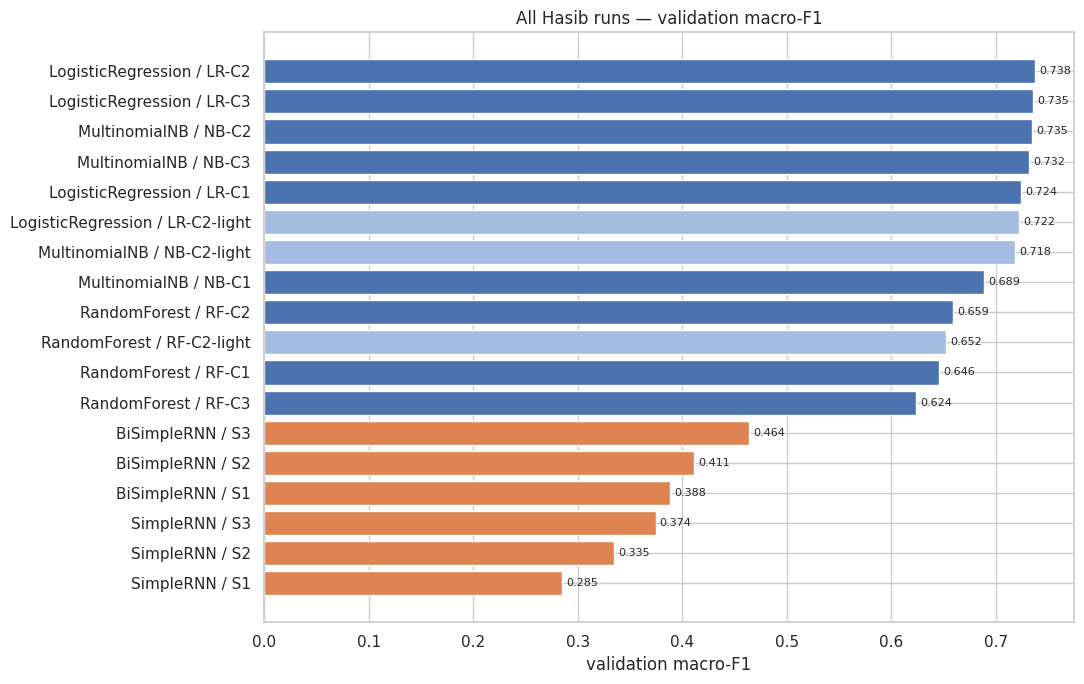

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
plot_df = runs_df.assign(run=runs_df.model + " / " + runs_df.config) \
                 .sort_values("val_macro_f1")
palette = {("classical", "required"): "#4c72b0",
           ("classical", "ablation"): "#a3bce0",
           ("recurrent", "required"): "#dd8452"}
colors = [palette.get((t, k), "#999999")
          for t, k in zip(plot_df.tier, plot_df.kind)]
ax.barh(plot_df.run, plot_df.val_macro_f1, color=colors)
ax.set_xlabel("validation macro-F1")
ax.set_title("All Hasib runs — validation macro-F1")
for y, v in zip(range(len(plot_df)), plot_df.val_macro_f1):
    ax.text(v + 0.004, y, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
save_fig(fig, "val_leaderboard_hasib.png")
plt.show()

## Test evaluation

Only the winning configuration of each model is evaluated on test, and only once.

`ev.evaluate_model` returns everything section 3.9 requires: accuracy, macro and
weighted F1, the full classification report, the row-normalised confusion matrix, and
the within-family against cross-family error split.

In [ ]:
test_results = {}
test_preds = {}


def evaluate_on_test(label, run_id, y_pred_or_probs):
    res = ev.evaluate_model(y_test, y_pred_or_probs, CLASS_NAMES, SUPERCLASS,
                            model_name=label, split="test", verbose=True)
    test_results[label] = res
    test_preds[label] = ev.to_labels(y_pred_or_probs)

    df = pd.read_csv(RUNS_CSV)
    hit = df.run_id == run_id
    assert hit.sum() == 1, f"expected one row for {run_id}, found {int(hit.sum())}"
    df.loc[hit, "test_accuracy"]    = round(res["accuracy"], 4)
    df.loc[hit, "test_macro_f1"]    = round(res["macro_f1"], 4)
    df.loc[hit, "test_weighted_f1"] = round(res["weighted_f1"], 4)
    df.to_csv(RUNS_CSV, index=False)
    return res


for name, b in best_classical.items():
    evaluate_on_test(f"{name} ({b['config']})", b["run_id"],
                     b["estimator"].predict(X_test_tfidf))
    print()

for arch, b in best_sequence.items():
    evaluate_on_test(f"{arch} ({b['config']})", b["run_id"],
                     b["model"].predict(X_test_seq, batch_size=256, verbose=0))
    print()

LogisticRegression (LR-C2)  [test]
  accuracy    : 0.6982
  macro-F1    : 0.6852
  weighted-F1 : 0.6960
  errors      : 2,192 (798 within-family = 36.4%, 1,394 cross-family = 63.6%)

MultinomialNB (NB-C2)  [test]
  accuracy    : 0.7038
  macro-F1    : 0.6843
  weighted-F1 : 0.6969
  errors      : 2,151 (802 within-family = 37.3%, 1,349 cross-family = 62.7%)

RandomForest (RF-C2)  [test]
  accuracy    : 0.6373
  macro-F1    : 0.6134
  weighted-F1 : 0.6271
  errors      : 2,634 (908 within-family = 34.5%, 1,726 cross-family = 65.5%)

SimpleRNN (S3)  [test]
  accuracy    : 0.3912
  macro-F1    : 0.3405
  weighted-F1 : 0.3522
  errors      : 4,421 (1,950 within-family = 44.1%, 2,471 cross-family = 55.9%)

BiSimpleRNN (S3)  [test]
  accuracy    : 0.4683
  macro-F1    : 0.4328
  weighted-F1 : 0.4440
  errors      : 3,861 (1,809 within-family = 46.9%, 2,052 cross-family = 53.1%)



### Classification reports

Printed in full. The brief requires a full classification report per model, and a cell
without visible output cannot be verified.

In [ ]:
for label, res in test_results.items():
    print("=" * 78)
    print(label)
    print("=" * 78)
    print(res["report_str"])

LogisticRegression (LR-C2)
                          precision    recall  f1-score   support

             alt.atheism     0.4770    0.4693    0.4731       309
           comp.graphics     0.6510    0.6885    0.6692       382
 comp.os.ms-windows.misc     0.6297    0.6148    0.6222       379
comp.sys.ibm.pc.hardware     0.6549    0.6276    0.6410       384
   comp.sys.mac.hardware     0.6950    0.7100    0.7024       369
          comp.windows.x     0.7796    0.7256    0.7517       390
            misc.forsale     0.7361    0.8064    0.7696       377
               rec.autos     0.7426    0.7548    0.7486       367
         rec.motorcycles     0.7600    0.7441    0.7520       383
      rec.sport.baseball     0.8415    0.8213    0.8313       375
        rec.sport.hockey     0.8835    0.8995    0.8914       388
               sci.crypt     0.8251    0.7507    0.7861       377
         sci.electronics     0.5674    0.5868    0.5770       380
                 sci.med     0.7836    0.7836   

### Confusion matrices

Row-normalised, so a bright off-diagonal cell means a class is losing a large share of
its own documents rather than simply being large.

saved /content/hasib_outputs/confusion_matrices_hasib.png
copied to /content/drive/MyDrive/cse440_project/figures/hasib/confusion_matrices_hasib.png


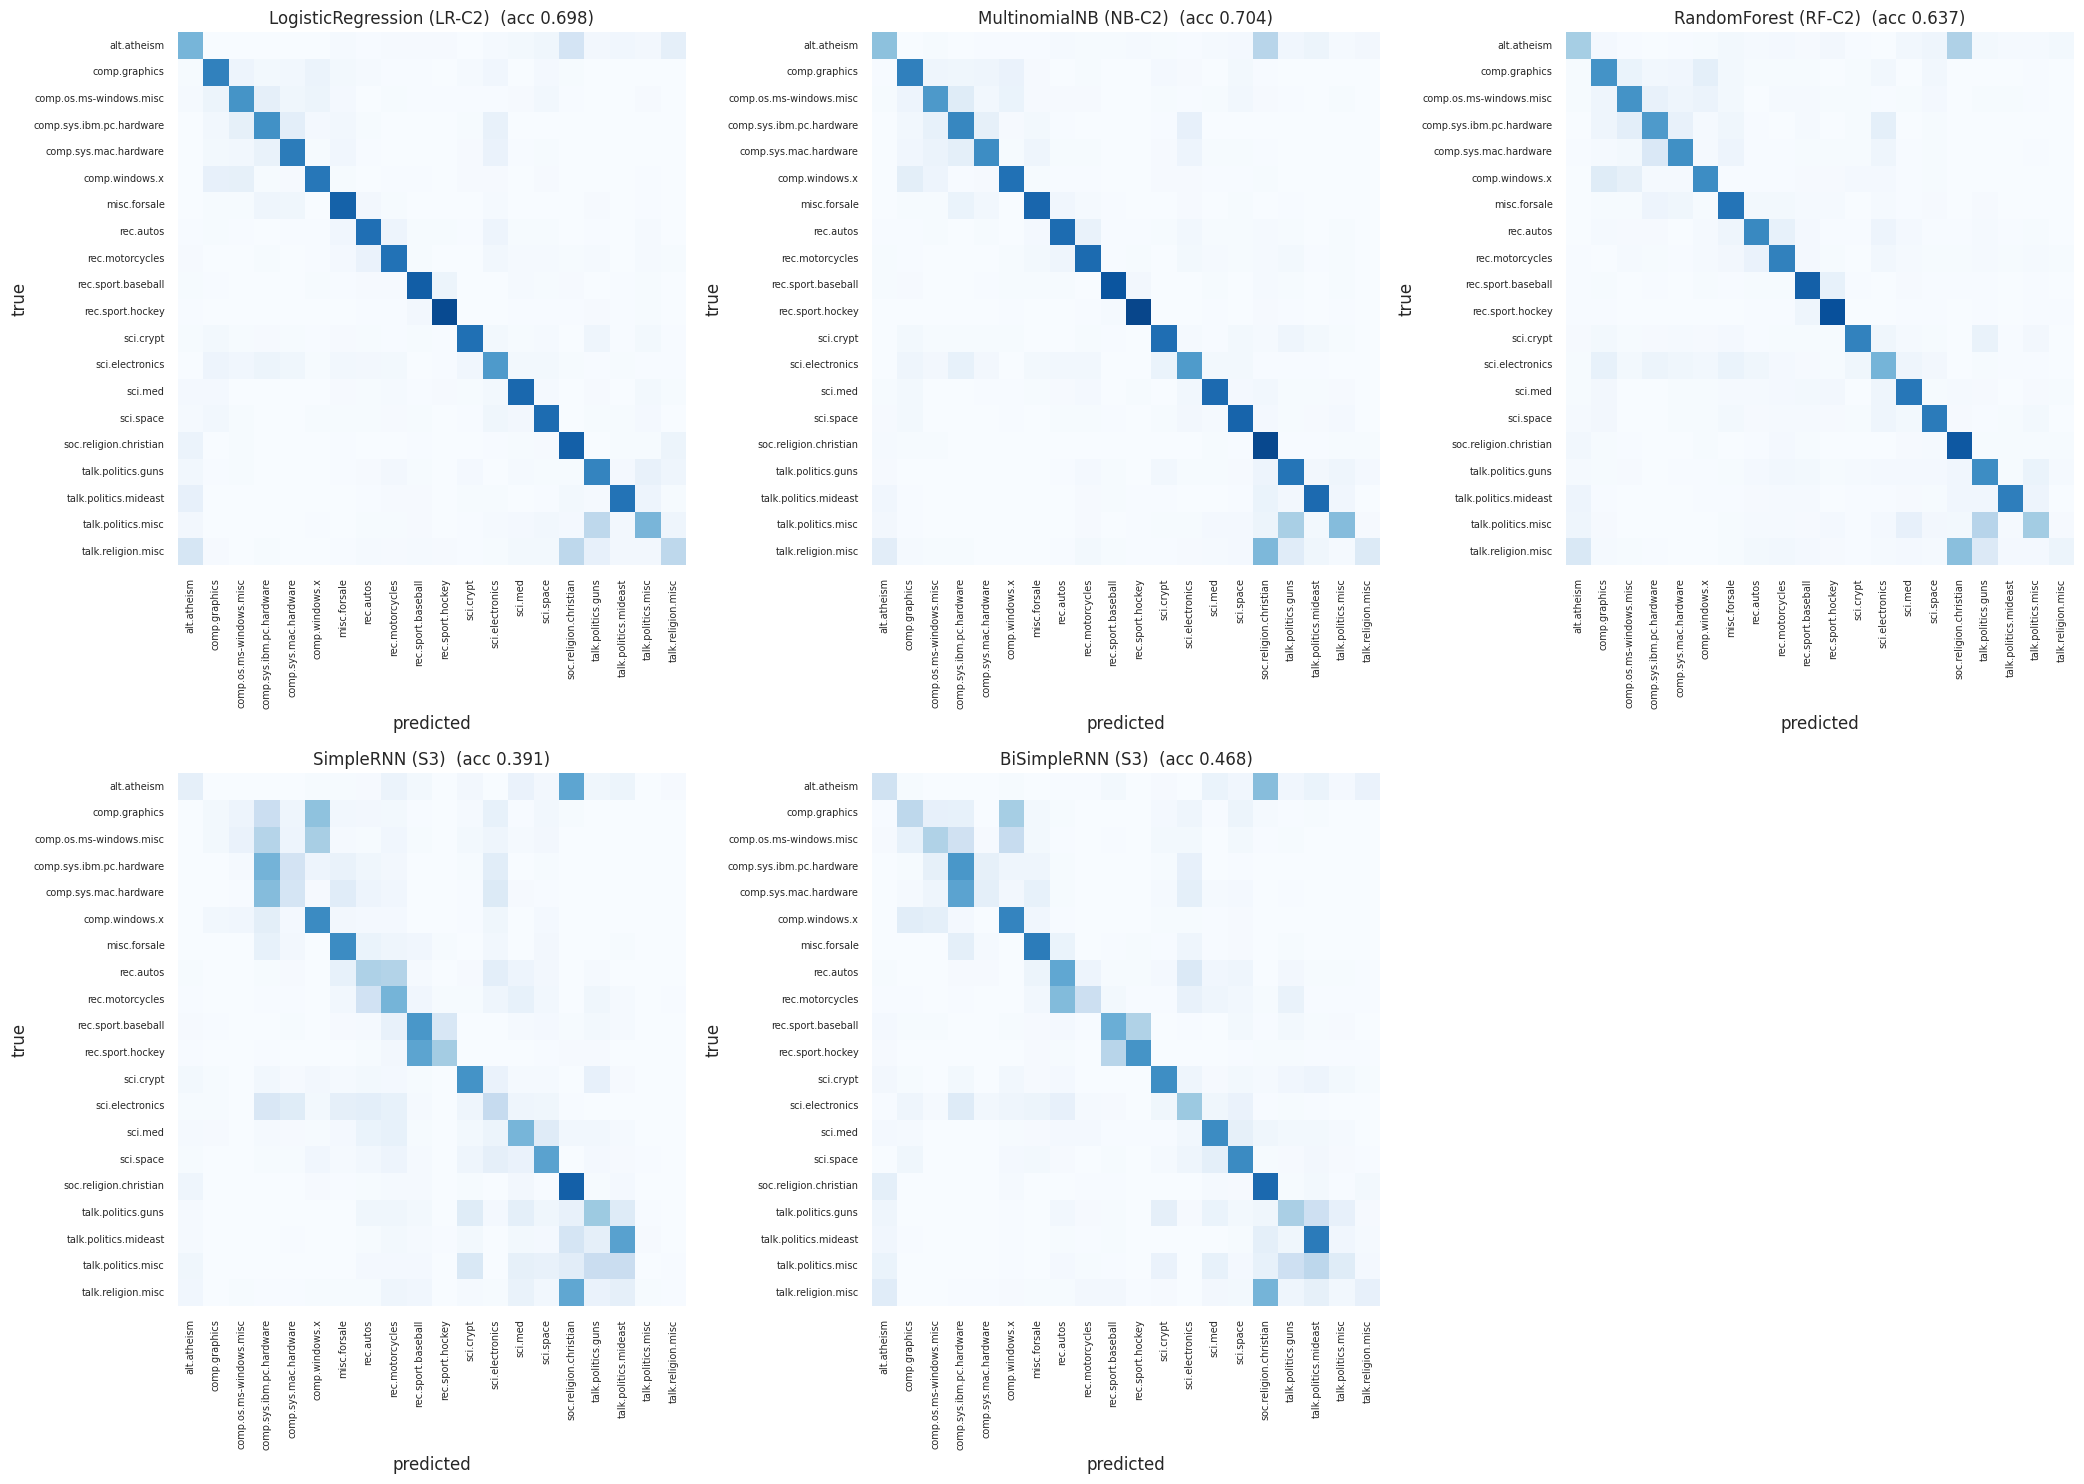

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(21, 15))

for ax, (label, res) in zip(axes.ravel(), test_results.items()):
    sns.heatmap(res["cm_norm"], ax=ax, cmap="Blues", vmin=0, vmax=1, cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(f"{label}  (acc {res['accuracy']:.3f})")
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)

for ax in axes.ravel()[len(test_results):]:
    ax.axis("off")

plt.tight_layout()
save_fig(fig, "confusion_matrices_hasib.png")
plt.show()

### Within-family versus cross-family errors

The 20 labels group into 7 families. Confusing two `comp.*` groups is a fine-grained
failure between similar topics. Confusing one with `talk.politics.guns` is a failure at
topic identification.

If wrong answers were spread randomly over the other 19 labels, about 15% would land in
the same family by chance. Anything well above that means the errors are semantic.

In [ ]:
rows = []
for label, res in test_results.items():
    f = res["family"]
    rows.append({
        "model": label,
        "errors": f["n_errors"],
        "within-family": f["within_family"],
        "cross-family": f["cross_family"],
        "within-family %": round(100 * f["within_share"], 1),
        "family accuracy": round(1 - f["cross_family"] / len(y_test), 4),
    })

family_df = pd.DataFrame(rows).sort_values("family accuracy", ascending=False)
print(family_df.to_string(index=False))

                     model  errors  within-family  cross-family  within-family %  family accuracy
     MultinomialNB (NB-C2)    2151            802          1349             37.3           0.8142
LogisticRegression (LR-C2)    2192            798          1394             36.4           0.8080
      RandomForest (RF-C2)    2634            908          1726             34.5           0.7623
          BiSimpleRNN (S3)    3861           1809          2052             46.9           0.7174
            SimpleRNN (S3)    4421           1950          2471             44.1           0.6597


In [ ]:
best_label = max(test_results, key=lambda n: test_results[n]["accuracy"])

conf = ev.top_confusions(y_test, test_preds[best_label], CLASS_NAMES, SUPERCLASS, k=12)
print(f"top confusions — {best_label}\n")
print(conf.to_string(index=False))
print(f"\nshare of these staying inside one family: {conf['same_family'].mean():.0%}")

top confusions — MultinomialNB (NB-C2)

                    true                predicted  count  pct_of_true_class  same_family
      talk.religion.misc   soc.religion.christian    111             0.4568        False
      talk.politics.misc       talk.politics.guns    103             0.3411         True
             alt.atheism   soc.religion.christian     91             0.2945        False
 comp.os.ms-windows.misc comp.sys.ibm.pc.hardware     45             0.1187         True
          comp.windows.x            comp.graphics     41             0.1051         True
   comp.sys.mac.hardware comp.sys.ibm.pc.hardware     35             0.0949         True
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware     34             0.0885         True
comp.sys.ibm.pc.hardware          sci.electronics     32             0.0833        False
         sci.electronics comp.sys.ibm.pc.hardware     30             0.0789        False
comp.sys.ibm.pc.hardware  comp.os.ms-windows.misc     30             0

## Export

The run log is checked against the shared 26-column schema before it is written. If the
columns do not match, the file will not concatenate with the other three and the merge
would fail silently.

Every row carries `dataset_checksum`, so the final 36-row table proves all four
contributors measured on the same data.

In [ ]:
for label, res in test_results.items():
    stem = "test_" + (label.replace(" ", "_").replace("(", "").replace(")", ""))
    local_json = LOCAL_OUT / f"{stem}.json"
    ev.save_result(res, LOCAL_OUT, stem)
    save_artifact(local_json, RESULT_DIR, DRIVE_RES_OK)

runs_df = pd.read_csv(RUNS_CSV)

assert list(runs_df.columns) == list(ev.RUN_COLUMNS), (
    "runs_hasib.csv does not match the shared schema — it will not concatenate")
assert runs_df.dataset_checksum.nunique() == 1, "rows disagree on dataset_checksum"
assert set(runs_df.tier) <= set(ev.TIERS), f"unexpected tier: {set(runs_df.tier)}"
assert set(runs_df.notes.str.split(" ").str[0]) <= set(ev.NOTE_KINDS), "bad notes token"

save_artifact(RUNS_CSV, RESULT_DIR, DRIVE_RES_OK)

print(f"\n{len(runs_df)} runs logged, {len(runs_df.columns)}-column schema v"
      f"{ev.SCORING_CONTRACT_VERSION}")
print(runs_df[["run_id", "tier", "model", "config", "embedding", "val_accuracy",
               "val_macro_f1", "test_accuracy", "test_macro_f1"]].to_string(index=False))

saved /content/hasib_outputs/test_LogisticRegression_LR-C2.json
copied to /content/drive/MyDrive/cse440_project/results/hasib/test_LogisticRegression_LR-C2.json
saved /content/hasib_outputs/test_MultinomialNB_NB-C2.json
copied to /content/drive/MyDrive/cse440_project/results/hasib/test_MultinomialNB_NB-C2.json
saved /content/hasib_outputs/test_RandomForest_RF-C2.json
copied to /content/drive/MyDrive/cse440_project/results/hasib/test_RandomForest_RF-C2.json
saved /content/hasib_outputs/test_SimpleRNN_S3.json
copied to /content/drive/MyDrive/cse440_project/results/hasib/test_SimpleRNN_S3.json
saved /content/hasib_outputs/test_BiSimpleRNN_S3.json
copied to /content/drive/MyDrive/cse440_project/results/hasib/test_BiSimpleRNN_S3.json
saved /content/hasib_outputs/runs_hasib.csv
copied to /content/drive/MyDrive/cse440_project/results/hasib/runs_hasib.csv

18 runs logged, 26-column schema v1.1
                        run_id      tier              model      config   embedding  val_accuracy  va

In [ ]:
summary = (runs_df.dropna(subset=["test_accuracy"])
                  [["model", "config", "embedding", "hyperparams",
                    "val_macro_f1", "test_accuracy", "test_macro_f1"]]
                  .sort_values("test_macro_f1", ascending=False))

print("FINAL — best configuration per model, test set\n")
print(summary.to_string(index=False))
print(f"\nbest  : {summary.iloc[0].model} ({summary.iloc[0].config})")
print(f"worst : {summary.iloc[-1].model} ({summary.iloc[-1].config})")

FINAL — best configuration per model, test set

             model config   embedding                                                                                               hyperparams  val_macro_f1  test_accuracy  test_macro_f1
LogisticRegression  LR-C2 tfidf_clean                                                                                                {"C": 5.0}        0.7377         0.6982         0.6852
     MultinomialNB  NB-C2 tfidf_clean                                                                                            {"alpha": 0.1}        0.7348         0.7038         0.6843
      RandomForest  RF-C2 tfidf_clean                                      {"max_features": "sqrt", "min_samples_leaf": 2, "n_estimators": 600}        0.6593         0.6373         0.6134
       BiSimpleRNN     S3    word2vec {"batch_size": 64, "dropout": 0.5, "embedding": "word2vec", "lr": 0.001, "trainable": true, "units": 128}        0.4640         0.4683         0.4328
         Sim

In [ ]:
def build_sequence_model(emb_matrix, units, dropout, bidirectional=False,
                         trainable_emb=False, cell=LSTM, num_classes=NUM_CLASSES):
    vocab_size, emb_dim = emb_matrix.shape

    inp = Input(shape=(MAX_LEN,), dtype="int32", name="tokens")
    x = Embedding(
        input_dim=vocab_size,
        output_dim=emb_dim,
        mask_zero=True,
        trainable=trainable_emb,
        name="embedding",
    )(inp)

    rnn = cell(units, dropout=dropout, recurrent_dropout=0.0, name="recurrent")
    x = Bidirectional(rnn, name="bidirectional")(x) if bidirectional else rnn(x)

    x = Dropout(dropout, name="head_dropout")(x)
    out = Dense(num_classes, activation="softmax", name="softmax")(x)

    model = Model(inp, out, name=("bi_" if bidirectional else "") + cell.__name__.lower())
    model.get_layer("embedding").set_weights([emb_matrix])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:
RUNS_CSV = RESULTS_DIR / "runs_fabiha.csv"
WEIGHT_DIR = RESULTS_DIR / "weights"
WEIGHT_DIR.mkdir(parents=True, exist_ok=True)

HISTORIES = {}
MODELS = {}

def train_one_run(arch, cfg, X_tr=None, y_tr=None, X_va=None, y_va=None,
                  tag=None, notes="", log=True):
    X_tr = X_train_seq if X_tr is None else X_tr
    y_tr = y_train     if y_tr is None else y_tr
    X_va = X_val_seq   if X_va is None else X_va
    y_va = y_val       if y_va is None else y_va

    run_id = tag or f"{arch}_{cfg['name']}"
    keras.utils.set_random_seed(SEED)

    model = build_sequence_model(
        emb_matrix=cfg.get("emb_matrix", EMB[cfg["emb"]]),
        units=cfg["units"],
        dropout=cfg["dropout"],
        bidirectional=(arch == "Bi-LSTM"),
        trainable_emb=cfg["trainable_emb"],
    )

    stopper = EarlyStopping(monitor=MONITOR, mode=MONITOR_MODE, patience=PATIENCE,
                            restore_best_weights=True, verbose=1)

    print(f"\n{'='*70}\n{run_id}  |  {arch}  |  emb={cfg['emb']}  units={cfg['units']}  "
          f"dropout={cfg['dropout']}  trainable_emb={cfg['trainable_emb']}\n{'='*70}")

    t0 = time.time()
    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[stopper],
        verbose=2,
    )
    elapsed = time.time() - t0

    best_epoch = int(np.argmax(hist.history[MONITOR])) + 1
    val_probs = model.predict(X_va, batch_size=256, verbose=0)
    res = ev.evaluate_model(y_va, val_probs, CLASS_NAMES, SUPERCLASS,
                            model_name=run_id, split="val", verbose=False)

    record = {
        "run_id": run_id, "owner": "fabiha", "notebook": "04_lstm_fabiha.ipynb",
        "model": arch, "config": cfg["name"], "embedding": cfg["emb"],
        "units": cfg["units"], "dropout": cfg["dropout"],
        "trainable_emb": cfg["trainable_emb"],
        "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
        "epochs_run": len(hist.history["loss"]), "best_epoch": best_epoch,
        "params": int(model.count_params()),
        "val_loss": float(min(hist.history["val_loss"])),
        "val_accuracy": float(res["accuracy"]),
        "val_macro_f1": float(res["macro_f1"]),
        "train_time_s": round(elapsed, 1),
        "notes": notes,
    }

    HISTORIES[run_id] = hist.history
    MODELS[run_id] = model
    model.save_weights(str(WEIGHT_DIR / f"{run_id}.weights.h5"))
    if log:
        ev.log_run(RUNS_CSV, record)

    print(f"\n{run_id}: val acc {record['val_accuracy']:.4f} | "
          f"val macro-F1 {record['val_macro_f1']:.4f} | "
          f"best epoch {best_epoch}/{record['epochs_run']} | {elapsed:.0f}s")
    return model, record

Architecture check before committing GPU time to eight runs.

In [ ]:
_probe = build_sequence_model(emb_glove, units=64, dropout=0.3, bidirectional=False)
_probe.summary()
print()
_probe_bi = build_sequence_model(emb_glove, units=64, dropout=0.3, bidirectional=True)
print(f"LSTM    params: {_probe.count_params():,}")
print(f"Bi-LSTM params: {_probe_bi.count_params():,}")
print(f"embedding trainable: {_probe.get_layer('embedding').trainable}")
del _probe, _probe_bi
keras.backend.clear_session()

Model: "lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 250)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 250, 50)   │  1,000,000 │ tokens[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 250)       │          0 │ tokens[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recurrent (LSTM)    │ (None, 64)        │     29,440 │ embedding[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_dropout        │ (None, 64)        │          0 │ recurrent[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Dense)     │ (None, 20)        │      1,300 │ head_dropout[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,030,740 (3.93 MB)

 Trainable params: 30,740 (120.08 KB)

 Non-trainable params: 1,000,000 (3.81 MB)


LSTM    params: 1,030,740
Bi-LSTM params: 1,061,460
embedding trainable: False


### Preprocessing ablation

Section 3.4 of the brief asks for a justified comparison of preprocessing strategies.
Phase 0 chose `text_clean` on vocabulary statistics. Hasib measured the effect on the
classical tier. This measures it on a recurrent model, where the mechanism is different.

A second tokenizer and a second GloVe matrix are built from `text_light`, which keeps
stopwords and inflections. The S1 configuration is then trained once on each. Two extra
runs, not part of the required thirty.

The mechanism to watch is not the same as the classical one. For TF-IDF the cost of
stopwords is feature slots under a fixed cap. For a sequence model the cost is
timesteps: with a 250-token window, stopwords consume positions that could hold topical
words.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = repr_meta["max_vocab"]

tok_light = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok_light.fit_on_texts(train["text_light"])

def pad_light(texts):
    return pad_sequences(tok_light.texts_to_sequences(texts),
                         maxlen=MAX_LEN, padding="post", truncating="post")

X_train_light = pad_light(train["text_light"])
X_val_light   = pad_light(val["text_light"])

vocab_light = min(MAX_VOCAB, len(tok_light.word_index) + 1)

print(f"light vocabulary seen : {len(tok_light.word_index):,}")
print(f"clean vocabulary seen : {len(tokenizer.word_index):,}")
print(f"light vocab_size used : {vocab_light:,}")

light vocabulary seen : 60,498
clean vocabulary seen : 49,395
light vocab_size used : 20,000


In [ ]:
glove_path = DATA_DIR / "glove.6B.50d.txt"
glove = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        parts = line.rstrip().split(" ")
        glove[parts[0]] = np.asarray(parts[1:], dtype="float32")

emb_glove_light = np.zeros((vocab_light, EMBEDDING_DIM), dtype="float32")
hits = 0
for word, idx in tok_light.word_index.items():
    if idx >= vocab_light:
        continue
    vec = glove.get(word)
    if vec is not None:
        emb_glove_light[idx] = vec
        hits += 1

cov_light = hits / (vocab_light - 1)
print(f"glove coverage on light vocab : {hits:,}/{vocab_light-1:,} = {cov_light:.1%}")
print(f"glove coverage on clean vocab : {repr_meta['coverage_glove']:.1%}")

del glove

glove coverage on light vocab : 18,665/19,999 = 93.3%
glove coverage on clean vocab : 87.3%


In [ ]:
ABL_CFG_CLEAN = {**SEQ_GRID[0], "name": "ABL-clean"}
ABL_CFG_LIGHT = {**SEQ_GRID[0], "name": "ABL-light", "emb_matrix": emb_glove_light}

_, abl_clean = train_one_run("LSTM", ABL_CFG_CLEAN, tag="ABL_clean",
                             notes="preprocessing ablation: text_clean (full strategy)")

_, abl_light = train_one_run("LSTM", ABL_CFG_LIGHT,
                             X_tr=X_train_light, X_va=X_val_light,
                             tag="ABL_light",
                             notes="preprocessing ablation: text_light")


ABL_clean  |  LSTM  |  emb=glove  units=64  dropout=0.3  trainable_emb=False
Epoch 1/30
145/145 - 10s - 68ms/step - accuracy: 0.1386 - loss: 2.7279 - val_accuracy: 0.2535 - val_loss: 2.2291
Epoch 2/30
145/145 - 2s - 15ms/step - accuracy: 0.2691 - loss: 2.2031 - val_accuracy: 0.3515 - val_loss: 1.9320
Epoch 3/30
145/145 - 2s - 14ms/step - accuracy: 0.3184 - loss: 2.0360 - val_accuracy: 0.4115 - val_loss: 1.7807
Epoch 4/30
145/145 - 2s - 14ms/step - accuracy: 0.3723 - loss: 1.9053 - val_accuracy: 0.4207 - val_loss: 1.7194
Epoch 5/30
145/145 - 4s - 25ms/step - accuracy: 0.3969 - loss: 1.8196 - val_accuracy: 0.4666 - val_loss: 1.6172
Epoch 6/30
145/145 - 2s - 16ms/step - accuracy: 0.4234 - loss: 1.7522 - val_accuracy: 0.4905 - val_loss: 1.5771
Epoch 7/30
145/145 - 2s - 14ms/step - accuracy: 0.4479 - loss: 1.6869 - val_accuracy: 0.4985 - val_loss: 1.5367
Epoch 8/30
145/145 - 2s - 14ms/step - accuracy: 0.4606 - loss: 1.6415 - val_accuracy: 0.5144 - val_loss: 1.4836
Epoch 9/30
145/145 - 2s -

In [ ]:
abl = pd.DataFrame([abl_clean, abl_light])[
    ["run_id", "val_accuracy", "val_macro_f1", "best_epoch", "epochs_run", "train_time_s"]
].set_index("run_id").round(4)

delta = abl_clean["val_accuracy"] - abl_light["val_accuracy"]
print(abl.to_string())
print(f"\nfull-strategy advantage on validation accuracy: {delta:+.4f} "
      f"({100*delta:+.2f} pp)")

           val_accuracy  val_macro_f1  best_epoch  epochs_run  train_time_s
run_id                                                                     
ABL_clean        0.6320        0.6219          30          30          79.5
ABL_light        0.6099        0.5889          30          30          73.3

full-strategy advantage on validation accuracy: +0.0220 (+2.20 pp)


### 9.3 LSTM, three configurations

In [ ]:
lstm_records = []
for cfg in SEQ_GRID:
    _, rec = train_one_run("LSTM", cfg)
    lstm_records.append(rec)


LSTM_S1  |  LSTM  |  emb=glove  units=64  dropout=0.3  trainable_emb=False
Epoch 1/30
145/145 - 5s - 35ms/step - accuracy: 0.1386 - loss: 2.7279 - val_accuracy: 0.2535 - val_loss: 2.2282
Epoch 2/30
145/145 - 2s - 14ms/step - accuracy: 0.2651 - loss: 2.1999 - val_accuracy: 0.3442 - val_loss: 1.9427
Epoch 3/30
145/145 - 2s - 14ms/step - accuracy: 0.3197 - loss: 2.0333 - val_accuracy: 0.3956 - val_loss: 1.8051
Epoch 4/30
145/145 - 2s - 14ms/step - accuracy: 0.3651 - loss: 1.9107 - val_accuracy: 0.4262 - val_loss: 1.7201
Epoch 5/30
145/145 - 2s - 14ms/step - accuracy: 0.3938 - loss: 1.8180 - val_accuracy: 0.4532 - val_loss: 1.6251
Epoch 6/30
145/145 - 3s - 18ms/step - accuracy: 0.4205 - loss: 1.7503 - val_accuracy: 0.4856 - val_loss: 1.5796
Epoch 7/30
145/145 - 5s - 32ms/step - accuracy: 0.4428 - loss: 1.6990 - val_accuracy: 0.4917 - val_loss: 1.5344
Epoch 8/30
145/145 - 2s - 14ms/step - accuracy: 0.4584 - loss: 1.6529 - val_accuracy: 0.5113 - val_loss: 1.4778
Epoch 9/30
145/145 - 2s - 14

logged LSTM_S1 -> runs_fabiha.csv (3 rows)

LSTM_S1: val acc 0.6246 | val macro-F1 0.6120 | best epoch 30/30 | 76s

LSTM_S2  |  LSTM  |  emb=word2vec  units=64  dropout=0.3  trainable_emb=False
Epoch 1/30
145/145 - 4s - 26ms/step - accuracy: 0.1857 - loss: 2.5682 - val_accuracy: 0.3448 - val_loss: 1.9582
Epoch 2/30
145/145 - 2s - 16ms/step - accuracy: 0.3280 - loss: 1.9931 - val_accuracy: 0.4274 - val_loss: 1.6773
Epoch 3/30
145/145 - 3s - 22ms/step - accuracy: 0.3905 - loss: 1.7994 - val_accuracy: 0.4421 - val_loss: 1.5818
Epoch 4/30
145/145 - 2s - 15ms/step - accuracy: 0.4192 - loss: 1.7094 - val_accuracy: 0.4709 - val_loss: 1.5119
Epoch 5/30
145/145 - 2s - 15ms/step - accuracy: 0.4419 - loss: 1.6270 - val_accuracy: 0.5126 - val_loss: 1.4334
Epoch 6/30
145/145 - 2s - 14ms/step - accuracy: 0.4612 - loss: 1.5719 - val_accuracy: 0.5254 - val_loss: 1.3928
Epoch 7/30
145/145 - 2s - 14ms/step - accuracy: 0.4733 - loss: 1.5261 - val_accuracy: 0.5383 - val_loss: 1.3628
Epoch 8/30
145/145 - 2

logged LSTM_S2 -> runs_fabiha.csv (4 rows)

LSTM_S2: val acc 0.6301 | val macro-F1 0.6094 | best epoch 28/30 | 79s

LSTM_S3  |  LSTM  |  emb=word2vec  units=128  dropout=0.5  trainable_emb=True
Epoch 1/30
145/145 - 4s - 30ms/step - accuracy: 0.1767 - loss: 2.5667 - val_accuracy: 0.3417 - val_loss: 1.8597
Epoch 2/30
145/145 - 2s - 15ms/step - accuracy: 0.3148 - loss: 2.0521 - val_accuracy: 0.3962 - val_loss: 1.6985
Epoch 3/30
145/145 - 3s - 18ms/step - accuracy: 0.3644 - loss: 1.8723 - val_accuracy: 0.4550 - val_loss: 1.5535
Epoch 4/30
145/145 - 3s - 22ms/step - accuracy: 0.4061 - loss: 1.7507 - val_accuracy: 0.5089 - val_loss: 1.4638
Epoch 5/30
145/145 - 2s - 16ms/step - accuracy: 0.4337 - loss: 1.6617 - val_accuracy: 0.5181 - val_loss: 1.3990
Epoch 6/30
145/145 - 2s - 15ms/step - accuracy: 0.4644 - loss: 1.5793 - val_accuracy: 0.5340 - val_loss: 1.3520
Epoch 7/30
145/145 - 2s - 15ms/step - accuracy: 0.4891 - loss: 1.5070 - val_accuracy: 0.5591 - val_loss: 1.3016
Epoch 8/30
145/145 - 2

### 9.4 Bidirectional LSTM, three configurations

The second pass reads the sequence in reverse and the two final states are concatenated,
so the classifier sees both directions and the recurrent parameter count doubles.

In [ ]:
bilstm_records = []
for cfg in SEQ_GRID:
    _, rec = train_one_run("Bi-LSTM", cfg)
    bilstm_records.append(rec)


Bi-LSTM_S1  |  Bi-LSTM  |  emb=glove  units=64  dropout=0.3  trainable_emb=False
Epoch 1/30
145/145 - 6s - 42ms/step - accuracy: 0.2012 - loss: 2.5279 - val_accuracy: 0.3521 - val_loss: 1.9114
Epoch 2/30
145/145 - 3s - 23ms/step - accuracy: 0.3513 - loss: 1.9302 - val_accuracy: 0.4274 - val_loss: 1.6758
Epoch 3/30
145/145 - 4s - 31ms/step - accuracy: 0.4123 - loss: 1.7323 - val_accuracy: 0.4495 - val_loss: 1.5909
Epoch 4/30
145/145 - 4s - 25ms/step - accuracy: 0.4474 - loss: 1.6258 - val_accuracy: 0.4807 - val_loss: 1.5066
Epoch 5/30
145/145 - 3s - 23ms/step - accuracy: 0.4723 - loss: 1.5552 - val_accuracy: 0.5083 - val_loss: 1.4495
Epoch 6/30
145/145 - 3s - 23ms/step - accuracy: 0.5014 - loss: 1.4927 - val_accuracy: 0.5364 - val_loss: 1.3750
Epoch 7/30
145/145 - 5s - 31ms/step - accuracy: 0.5207 - loss: 1.4343 - val_accuracy: 0.5334 - val_loss: 1.3828
Epoch 8/30
145/145 - 3s - 23ms/step - accuracy: 0.5402 - loss: 1.3936 - val_accuracy: 0.5579 - val_loss: 1.3205
Epoch 9/30
145/145 - 3

### Tuning table

Six required runs. Configurations are selected on validation macro-F1, not accuracy.
With 20 classes, accuracy can be carried by the larger groups while macro-F1 averages
every class equally.

In [ ]:
runs = pd.read_csv(RUNS_CSV)
grid_runs = runs[~runs.run_id.str.startswith("ABL")].copy()

tune_table = grid_runs[[
    "model", "config", "embedding", "units", "dropout", "trainable_emb",
    "params", "epochs_run", "best_epoch", "val_loss", "val_accuracy",
    "val_macro_f1", "train_time_s",
]].sort_values(["model", "config"]).reset_index(drop=True).round(4)

print(tune_table.to_string(index=False))

best_lstm = grid_runs[grid_runs.model == "LSTM"].sort_values("val_accuracy").iloc[-1]
best_bi   = grid_runs[grid_runs.model == "Bi-LSTM"].sort_values("val_accuracy").iloc[-1]
print(f"\nbest LSTM    : {best_lstm.run_id}  val acc {best_lstm.val_accuracy:.4f}")
print(f"best Bi-LSTM : {best_bi.run_id}  val acc {best_bi.val_accuracy:.4f}")

  model config embedding  units  dropout  trainable_emb  params  epochs_run  best_epoch  val_loss  val_accuracy  val_macro_f1  train_time_s
Bi-LSTM     S1     glove     64      0.3          False 1061460          30          28    1.1252        0.6522        0.6378         113.9
Bi-LSTM     S2  word2vec     64      0.3          False 1061460          26          21    1.1501        0.6320        0.6130          98.8
Bi-LSTM     S3  word2vec    128      0.5           True 1188436          25          20    0.9850        0.7397        0.7283         104.6
   LSTM     S1     glove     64      0.3          False 1030740          30          30    1.1849        0.6246        0.6120          76.1
   LSTM     S2  word2vec     64      0.3          False 1030740          30          28    1.1583        0.6301        0.6094          78.6
   LSTM     S3  word2vec    128      0.5           True 1094228          30          28    0.9789        0.7250        0.7122          78.9

best LSTM    : LSTM

### Learning curves

The line to watch is whether validation accuracy is still rising at the final epoch,
which would mean the 30-epoch cap cut the run off rather than early stopping halting it.

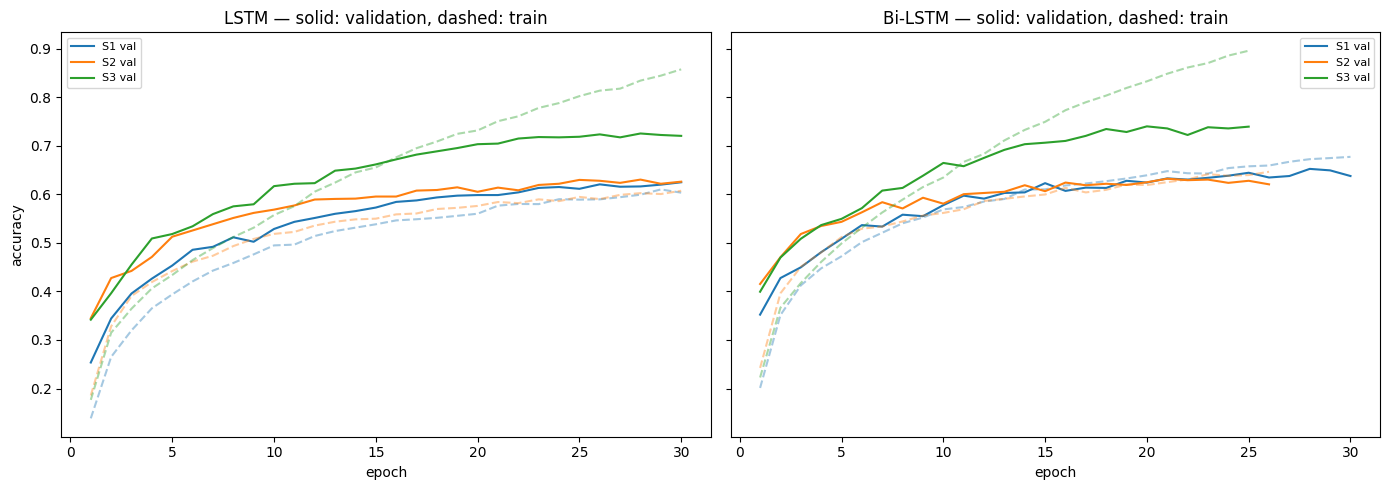

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, arch in zip(axes, ["LSTM", "Bi-LSTM"]):
    for cfg in SEQ_GRID:
        rid = f"{arch}_{cfg['name']}"
        h = HISTORIES.get(rid)
        if h is None:
            continue
        ep = range(1, len(h["accuracy"]) + 1)
        line, = ax.plot(ep, h["val_accuracy"], label=f"{cfg['name']} val")
        ax.plot(ep, h["accuracy"], ls="--", alpha=0.4, color=line.get_color())
    ax.set_title(f"{arch} — solid: validation, dashed: train")
    ax.set_xlabel("epoch")
    ax.legend(fontsize=8)

axes[0].set_ylabel("accuracy")
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_training_curves.png", dpi=150)
plt.show()

### The embedding contrast

S1 and S2 differ only in the embedding matrix. Units, dropout and the frozen flag are
identical, so the difference is attributable to the embedding source alone.

GloVe covers 87.32% of the vocabulary and Word2Vec covers 99.995%. Every GloVe miss is a
zero row, which the model reads as a word with no meaning.

In [ ]:
contrast = grid_runs[grid_runs.config.isin(["S1", "S2"])].pivot_table(
    index="model", columns="config", values=["val_accuracy", "val_macro_f1"]
).round(4)
contrast[("val_accuracy", "S2-S1")] = (contrast[("val_accuracy", "S2")]
                                       - contrast[("val_accuracy", "S1")]).round(4)
contrast[("val_macro_f1", "S2-S1")] = (contrast[("val_macro_f1", "S2")]
                                       - contrast[("val_macro_f1", "S1")]).round(4)
print(contrast.to_string())

zero_glove = int((emb_glove.sum(axis=1) == 0).sum())
zero_w2v   = int((emb_w2v.sum(axis=1) == 0).sum())
print(f"\ndead rows in the embedding matrix — glove {zero_glove:,}, word2vec {zero_w2v:,}")
print(f"vocabulary coverage           — glove {repr_meta['coverage_glove']:.1%}, "
      f"word2vec {repr_meta['coverage_word2vec']:.1%}")

        val_accuracy         val_macro_f1         val_accuracy val_macro_f1
config            S1      S2           S1      S2        S2-S1        S2-S1
model                                                                      
Bi-LSTM       0.6522  0.6320       0.6378  0.6130      -0.0202      -0.0248
LSTM          0.6246  0.6301       0.6120  0.6094       0.0055      -0.0026

dead rows in the embedding matrix — glove 2,536, word2vec 2
vocabulary coverage           — glove 87.3%, word2vec 100.0%


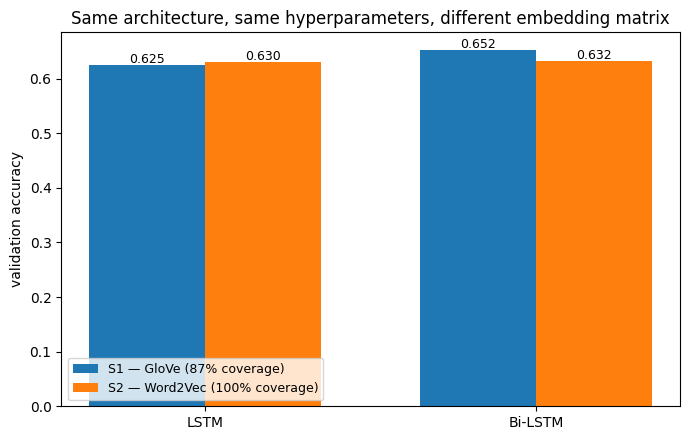

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
w = 0.35
models = ["LSTM", "Bi-LSTM"]
s1 = [grid_runs.query("model == @m and config == 'S1'").val_accuracy.iloc[0] for m in models]
s2 = [grid_runs.query("model == @m and config == 'S2'").val_accuracy.iloc[0] for m in models]
xs = np.arange(len(models))

ax.bar(xs - w/2, s1, w, label=f"S1 — GloVe ({repr_meta['coverage_glove']:.0%} coverage)")
ax.bar(xs + w/2, s2, w, label=f"S2 — Word2Vec ({repr_meta['coverage_word2vec']:.0%} coverage)")
ax.set_xticks(xs); ax.set_xticklabels(models)
ax.set_ylabel("validation accuracy")
ax.set_title("Same architecture, same hyperparameters, different embedding matrix")
ax.legend(fontsize=9)
for x, v in zip(xs - w/2, s1):
    ax.text(x, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
for x, v in zip(xs + w/2, s2):
    ax.text(x, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_embedding_contrast.png", dpi=150)
plt.show()

## Test evaluation

Only the winning configuration of each model is evaluated on test, and only once.

`ev.evaluate_model` returns everything section 3.9 requires: accuracy, macro and
weighted F1, the full classification report, the row-normalised confusion matrix, and
the within-family against cross-family error split.

In [ ]:
BEST = {"LSTM": best_lstm.run_id, "Bi-LSTM": best_bi.run_id}
print("evaluating:", BEST)

test_results = {}
for arch, run_id in BEST.items():
    model = MODELS.get(run_id)
    if model is None:
        cfg = next(c for c in SEQ_GRID if c["name"] == run_id.split("_")[-1])
        model = build_sequence_model(
            emb_matrix=EMB[cfg["emb"]], units=cfg["units"], dropout=cfg["dropout"],
            bidirectional=(arch == "Bi-LSTM"), trainable_emb=cfg["trainable_emb"],
        )
        model.load_weights(str(WEIGHT_DIR / f"{run_id}.weights.h5"))
        MODELS[run_id] = model
    probs = model.predict(X_test_seq, batch_size=256, verbose=0)
    test_results[f"{arch} ({run_id.split('_')[-1]})"] = ev.evaluate_model(
        y_test, probs, CLASS_NAMES, SUPERCLASS,
        model_name=f"{arch} ({run_id.split('_')[-1]})", split="test",
    )
    print()

evaluating: {'LSTM': 'LSTM_S3', 'Bi-LSTM': 'Bi-LSTM_S3'}
LSTM (S3)  [test]
  accuracy    : 0.6720
  macro-F1    : 0.6551
  weighted-F1 : 0.6684
  errors      : 2,382 (944 within-family = 39.6%, 1,438 cross-family = 60.4%)

Bi-LSTM (S3)  [test]
  accuracy    : 0.6767
  macro-F1    : 0.6627
  weighted-F1 : 0.6751
  errors      : 2,348 (956 within-family = 40.7%, 1,392 cross-family = 59.3%)



In [ ]:
comparison = ev.compare_models(test_results)
print(comparison.to_string(index=False))

for label, res in test_results.items():
    print(f"\n{'='*70}\n{label} — full classification report\n{'='*70}")
    print(res["report_str"])

       model  accuracy  macro_f1  weighted_f1  errors  within_family_%  cross_family_%
Bi-LSTM (S3)    0.6767    0.6627       0.6751    2348          40.7155         59.2845
   LSTM (S3)    0.6720    0.6551       0.6684    2382          39.6306         60.3694

LSTM (S3) — full classification report
                          precision    recall  f1-score   support

             alt.atheism     0.4481    0.3495    0.3927       309
           comp.graphics     0.6501    0.7199    0.6832       382
 comp.os.ms-windows.misc     0.6401    0.5726    0.6045       379
comp.sys.ibm.pc.hardware     0.5310    0.6250    0.5742       384
   comp.sys.mac.hardware     0.6788    0.5041    0.5785       369
          comp.windows.x     0.7567    0.7256    0.7408       390
            misc.forsale     0.7343    0.7772    0.7552       377
               rec.autos     0.7398    0.7439    0.7418       367
         rec.motorcycles     0.7473    0.7180    0.7324       383
      rec.sport.baseball     0.8384   

In [ ]:
for arch, run_id in BEST.items():
    label = f"{arch} ({run_id.split('_')[-1]})"
    runs = pd.read_csv(RUNS_CSV)
    runs.loc[runs.run_id == run_id, "test_accuracy"]    = test_results[label]["accuracy"]
    runs.loc[runs.run_id == run_id, "test_macro_f1"]    = test_results[label]["macro_f1"]
    runs.loc[runs.run_id == run_id, "test_weighted_f1"] = test_results[label]["weighted_f1"]
    runs.to_csv(RUNS_CSV, index=False)

print(pd.read_csv(RUNS_CSV)[
    ["run_id", "val_accuracy", "test_accuracy", "test_macro_f1", "test_weighted_f1"]
].round(4).to_string(index=False))

    run_id  val_accuracy  test_accuracy  test_macro_f1  test_weighted_f1
 ABL_clean        0.6320            NaN            NaN               NaN
 ABL_light        0.6099            NaN            NaN               NaN
   LSTM_S1        0.6246            NaN            NaN               NaN
   LSTM_S2        0.6301            NaN            NaN               NaN
   LSTM_S3        0.7250         0.6720         0.6551            0.6684
Bi-LSTM_S1        0.6522            NaN            NaN               NaN
Bi-LSTM_S2        0.6320            NaN            NaN               NaN
Bi-LSTM_S3        0.7397         0.6767         0.6627            0.6751


### Confusion matrices and per-class F1

Row-normalised, so a bright off-diagonal cell means a class is losing a large share of
its own documents rather than simply being large.

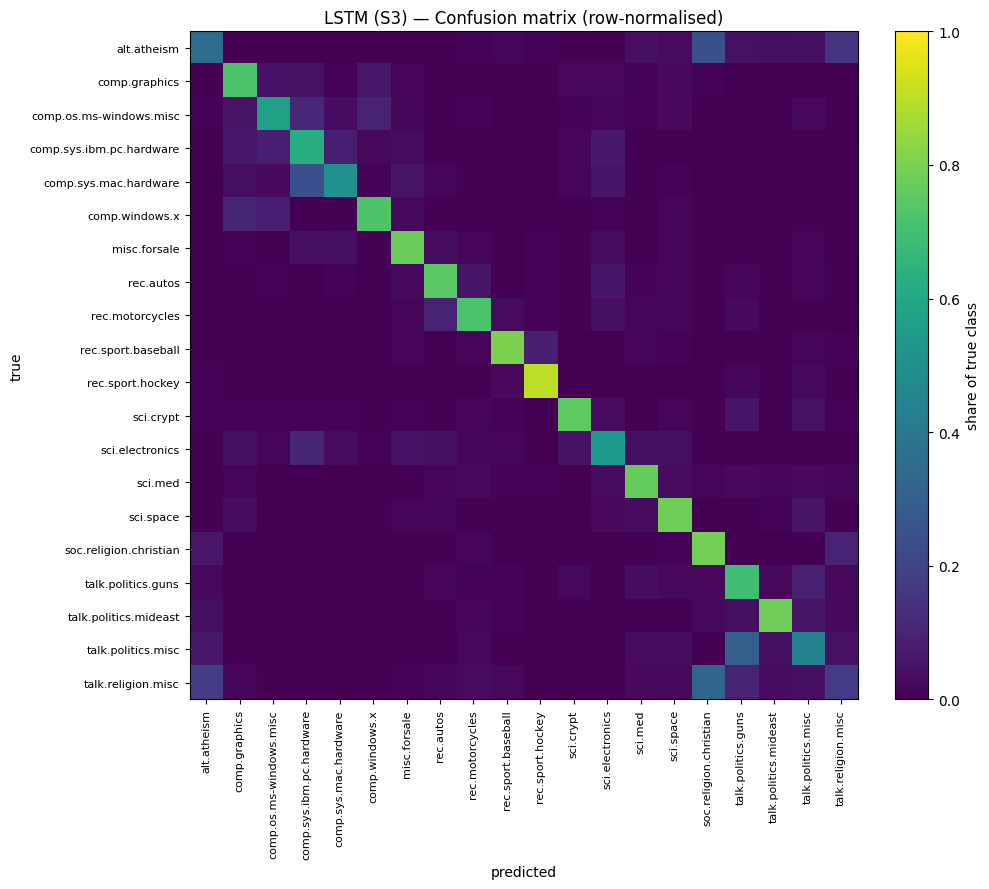

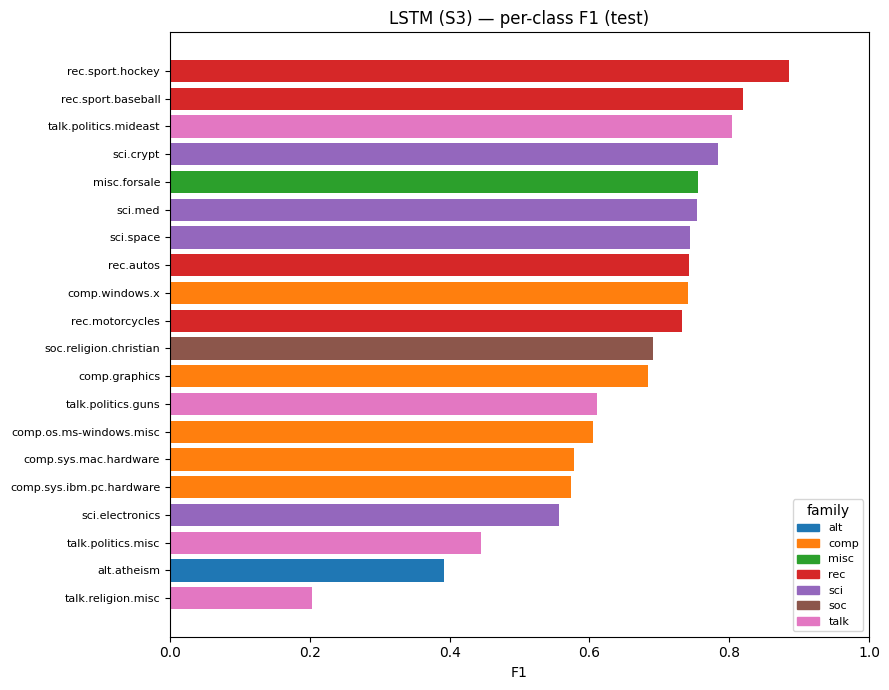

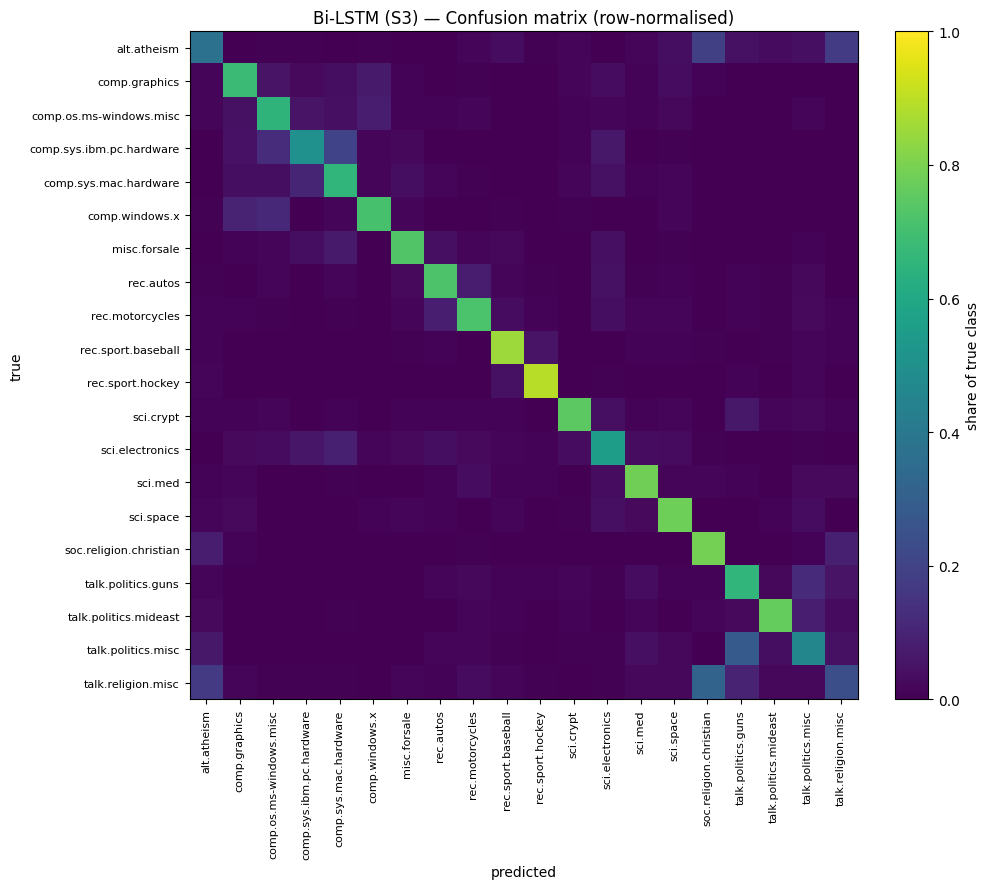

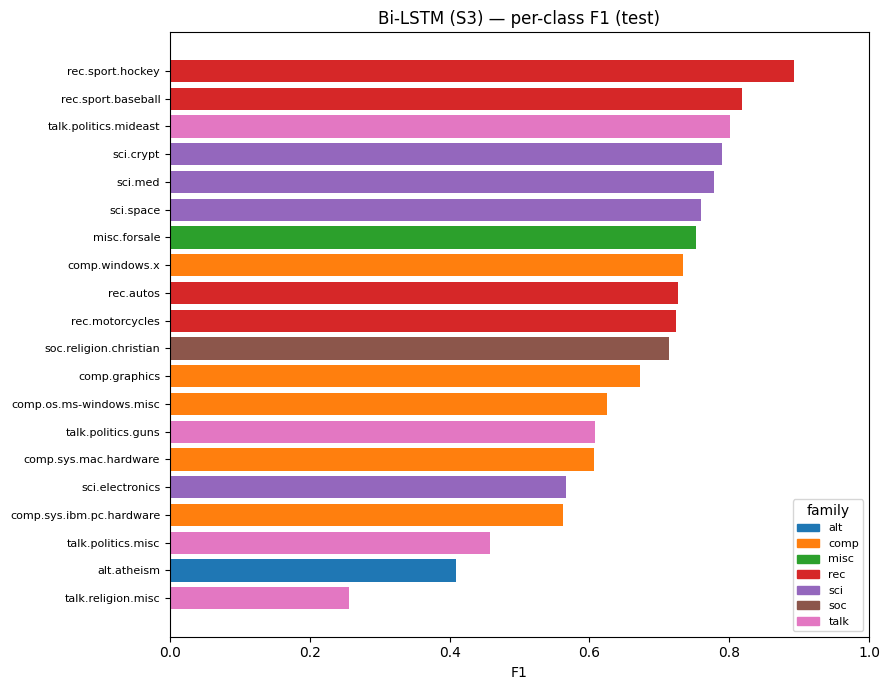

In [ ]:
for label, res in test_results.items():
    stem = label.replace(" ", "_").replace("(", "").replace(")", "")
    ev.plot_confusion_matrix(res, CLASS_NAMES,
                             save_path=FIG_DIR / f"cm_{stem}.png")
    plt.show()
    ev.plot_per_class_f1(res, save_path=FIG_DIR / f"f1_{stem}.png")
    plt.show()

In [ ]:
for label, res in test_results.items():
    print(f"\n{label} — five weakest classes")
    print(res["per_class"].head(5).to_string())
    print(f"\n{label} — five strongest classes")
    print(res["per_class"].tail(5).to_string())


LSTM (S3) — five weakest classes
                         family  precision  recall      f1  support
talk.religion.misc         talk     0.2389  0.1770  0.2033      243
alt.atheism                 alt     0.4481  0.3495  0.3927      309
talk.politics.misc         talk     0.4493  0.4404  0.4448      302
sci.electronics             sci     0.5742  0.5395  0.5563      380
comp.sys.ibm.pc.hardware   comp     0.5310  0.6250  0.5742      384

LSTM (S3) — five strongest classes
                      family  precision  recall      f1  support
misc.forsale            misc     0.7343  0.7772  0.7552      377
sci.crypt                sci     0.8161  0.7533  0.7834      377
talk.politics.mideast   talk     0.8290  0.7793  0.8034      367
rec.sport.baseball       rec     0.8384  0.8027  0.8202      375
rec.sport.hockey         rec     0.8706  0.9021  0.8861      388

Bi-LSTM (S3) — five weakest classes
                         family  precision  recall      f1  support
talk.religion.misc         

### The pairs the models cannot separate

The most frequent mistakes, ranked. The `same_family` column separates fine-grained
confusion between similar topics from failure at topic identification.

In [ ]:
best_label = comparison.iloc[0]["model"]
best_arch = best_label.split(" (")[0]
probs_best = MODELS[BEST[best_arch]].predict(X_test_seq, batch_size=256, verbose=0)

conf = ev.top_confusions(y_test, probs_best, CLASS_NAMES, SUPERCLASS, k=15)
print(f"{best_label} — 15 most frequent mistakes\n")
print(conf.to_string(index=False))
print(f"\nshare of these top-15 mistakes that stay inside one family: "
      f"{conf['same_family'].mean():.0%}")

Bi-LSTM (S3) — 15 most frequent mistakes

                    true                predicted  count  pct_of_true_class  same_family
      talk.politics.misc       talk.politics.guns     86             0.2848         True
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware     77             0.2005         True
      talk.religion.misc   soc.religion.christian     77             0.3169        False
             alt.atheism   soc.religion.christian     59             0.1909        False
             alt.atheism       talk.religion.misc     54             0.1748        False
comp.sys.ibm.pc.hardware  comp.os.ms-windows.misc     48             0.1250         True
          comp.windows.x  comp.os.ms-windows.misc     45             0.1154         True
      talk.politics.guns       talk.politics.misc     42             0.1197         True
      talk.religion.misc              alt.atheism     41             0.1687        False
          comp.windows.x            comp.graphics     38            

### Accuracy against document length

Documents longer than 250 tokens are truncated, so the model never sees their ending.
This splits test accuracy by how many tokens the model actually read.

If accuracy falls for truncated documents, sequence length is a binding constraint on
the recurrent tier and belongs in the limitations.

In [ ]:
pred_best = probs_best.argmax(axis=1)
correct = (pred_best == y_test)

tok_used = (X_test_seq != 0).sum(axis=1)
truncated = tok_used >= MAX_LEN

cuts = [c for c in (25, 50, 100, 175) if c < MAX_LEN - 1]
bins = [0] + cuts + [MAX_LEN - 1, MAX_LEN]
labels_ = ([f"<{cuts[0]}"]
           + [f"{a}-{b}" for a, b in zip(cuts, cuts[1:])]
           + [f"{cuts[-1]}-{MAX_LEN - 1}", "truncated"])
bucket = pd.cut(tok_used, bins=bins, labels=labels_, include_lowest=True)

by_len = pd.DataFrame({"bucket": bucket, "correct": correct}).groupby(
    "bucket", observed=False)["correct"].agg(["mean", "size"]).round(4)
by_len.columns = ["accuracy", "documents"]

print(f"{best_label} — accuracy by document length\n")
print(by_len.to_string())
print(f"\ntruncated documents : {truncated.sum():,} ({truncated.mean():.1%} of test)")
if truncated.any():
    acc_tr, acc_full = correct[truncated].mean(), correct[~truncated].mean()
    print(f"accuracy on truncated   : {acc_tr:.4f}")
    print(f"accuracy on complete    : {acc_full:.4f}")
    print(f"cost of the 250-token cap: {acc_full - acc_tr:+.4f}")
else:
    print("no document reached the cap — MAX_LEN is not binding on this split")

Bi-LSTM (S3) — accuracy by document length

           accuracy  documents
bucket                        
<25          0.5393       2251
25-50        0.6934       1918
50-100       0.7610       1653
100-175      0.7836        781
175-249      0.7750        240
truncated    0.7494        419

truncated documents : 419 (5.8% of test)
accuracy on truncated   : 0.7494
accuracy on complete    : 0.6722
cost of the 250-token cap: -0.0772


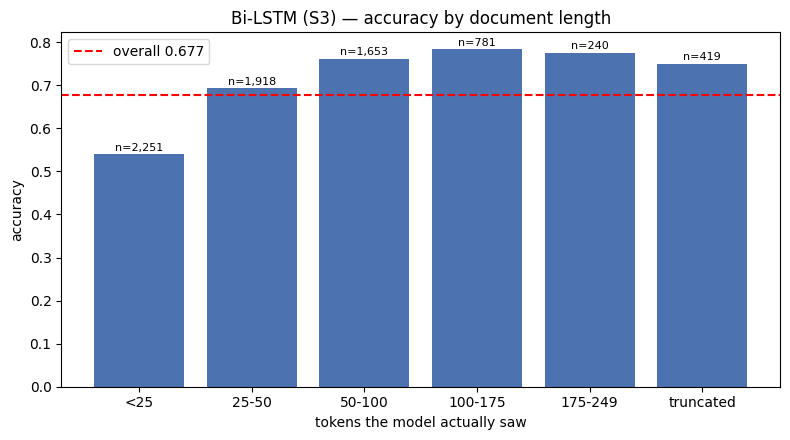

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(by_len.index.astype(str), by_len["accuracy"], color="#4c72b0")
ax.axhline(correct.mean(), color="red", ls="--",
           label=f"overall {correct.mean():.3f}")
ax.set_ylabel("accuracy"); ax.set_xlabel("tokens the model actually saw")
ax.set_title(f"{best_label} — accuracy by document length")
ax.legend()
for i, (a, n) in enumerate(zip(by_len["accuracy"], by_len["documents"])):
    ax.text(i, a + 0.008, f"n={n:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_accuracy_by_length.png", dpi=150)
plt.show()

### Within-family versus cross-family errors

The 20 labels group into 7 families. Confusing two `comp.*` groups is a fine-grained
failure between similar topics. Confusing one with `talk.politics.guns` is a failure at
topic identification.

If wrong answers were spread randomly over the other 19 labels, about 15% would land in
the same family by chance. Anything well above that means the errors are semantic.

In [ ]:
for label, res in test_results.items():
    f = res["family"]
    print(f"\n{'='*70}\n{label}\n{'='*70}")
    print(f"errors        : {f['n_errors']:,} of {len(y_test):,}")
    print(f"within-family : {f['within_family']:,}  ({f['within_share']:.1%} of errors)")
    print(f"cross-family  : {f['cross_family']:,}  ({f['cross_share']:.1%} of errors)")
    print()
    print(f["per_family"].to_string())


LSTM (S3)
errors        : 2,382 of 7,262
within-family : 944  (39.6% of errors)
cross-family  : 1,438  (60.4% of errors)

        support  errors  error_rate  within_family  cross_family  pct_of_errors_within
family                                                                                
alt         309     201      0.6505              0           201                0.0000
comp       1904     703      0.3692            463           240                0.6586
misc        377      84      0.2228              0            84                0.0000
rec        1513     314      0.2075            126           188                0.4013
sci        1512     441      0.2917            110           331                0.2494
soc         384      81      0.2109              0            81                0.0000
talk       1263     558      0.4418            245           313                0.4391

Bi-LSTM (S3)
errors        : 2,348 of 7,262
within-family : 956  (40.7% of errors)
cross-fami

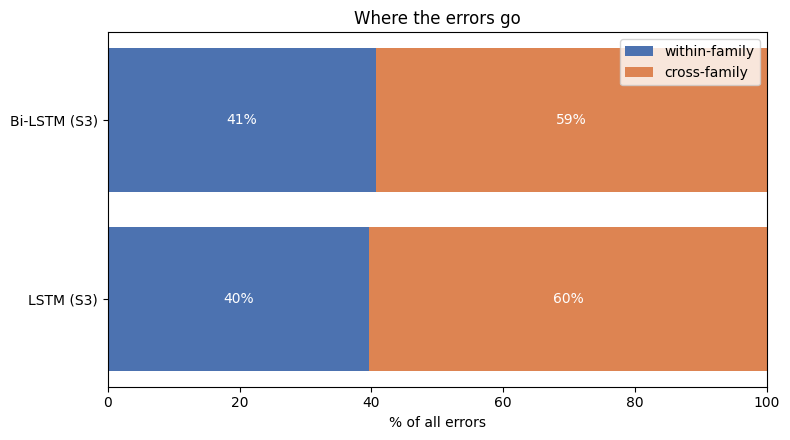

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
labels_list = list(test_results.keys())
within = [100 * test_results[l]["family"]["within_share"] for l in labels_list]
cross  = [100 * test_results[l]["family"]["cross_share"] for l in labels_list]

ax.barh(labels_list, within, label="within-family", color="#4c72b0")
ax.barh(labels_list, cross, left=within, label="cross-family", color="#dd8452")
ax.set_xlabel("% of all errors"); ax.set_xlim(0, 100)
ax.set_title("Where the errors go")
ax.legend()
for i, w in enumerate(within):
    ax.text(w / 2, i, f"{w:.0f}%", ha="center", va="center", color="white", fontsize=10)
    ax.text(w + (100 - w) / 2, i, f"{100-w:.0f}%", ha="center", va="center",
            color="white", fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_family_error_split.png", dpi=150)
plt.show()

## Export

Results are saved and the run log is checked against the shared 26-column schema.

In [ ]:
for label, res in test_results.items():
    stem = "test_" + label.replace(" ", "_").replace("(", "").replace(")", "")
    p = ev.save_result(res, RESULTS_DIR, stem)
    print(f"saved {p.name}")

comparison.to_csv(RESULTS_DIR / "test_comparison_fabiha.csv", index=False)

final = pd.read_csv(RUNS_CSV)
print(f"\n{len(final)} runs logged in {RUNS_CSV.name}")
print(final[["run_id", "model", "config", "embedding", "val_accuracy",
             "val_macro_f1", "test_accuracy", "train_time_s"]].round(4).to_string(index=False))

print("\nfigures written:")
for p in sorted(FIG_DIR.glob("lstm_*.png")) + sorted(FIG_DIR.glob("cm_*.png")) + sorted(FIG_DIR.glob("f1_*.png")):
    print(f"  {p.name}")

saved test_LSTM_S3.json
saved test_Bi-LSTM_S3.json

8 runs logged in runs_fabiha.csv
    run_id   model    config embedding  val_accuracy  val_macro_f1  test_accuracy  train_time_s
 ABL_clean    LSTM ABL-clean     glove        0.6320        0.6219            NaN          79.5
 ABL_light    LSTM ABL-light     glove        0.6099        0.5889            NaN          73.3
   LSTM_S1    LSTM        S1     glove        0.6246        0.6120            NaN          76.1
   LSTM_S2    LSTM        S2  word2vec        0.6301        0.6094            NaN          78.6
   LSTM_S3    LSTM        S3  word2vec        0.7250        0.7122         0.6720          78.9
Bi-LSTM_S1 Bi-LSTM        S1     glove        0.6522        0.6378            NaN         113.9
Bi-LSTM_S2 Bi-LSTM        S2  word2vec        0.6320        0.6130            NaN          98.8
Bi-LSTM_S3 Bi-LSTM        S3  word2vec        0.7397        0.7283         0.6767         104.6

figures written:
  lstm_accuracy_by_length.png
  l

### Post-hoc schema migration

The harness above writes the original 23-column run log. After the runs finished, the
team agreed a 26-column schema: `params` was ambiguous, holding a hyperparameter string
in one notebook and a parameter count in another, so it was split into `n_params` and
`hyperparams`, and `tier` and `dataset_checksum` were added.

This cell migrates the existing file in place. No model was re-trained and no number
changed. The harness code above is left as it ran, so the notebook shows what actually
produced these results.

In [ ]:
MIGRATION_NOTE = ("outputs reorganised into results/fabiha/ and figures/fabiha/ after "
                  "the run; run schema migrated v1.0 -> v1.1 in place, no re-training")

assert len(ev.RUN_COLUMNS) == 26, (
    f"expected the v1.1 schema, got {len(ev.RUN_COLUMNS)} columns — re-run §1c "
    "so the updated utils/evaluation.py is published to Drive")

f = pd.read_csv(RUNS_CSV)
print(f"before : {len(f)} rows, {len(f.columns)} columns")
print(f"         {list(f.columns)}\n")

if "params" in f.columns and "n_params" not in f.columns:
    f = f.rename(columns={"params": "n_params"})

f["hyperparams"]      = ""
f["tier"]             = "recurrent"
f["dataset_checksum"] = DATASET_CHECKSUM

def normalise_note(run_id, note):
    """Prefix `notes` with a controlled token, idempotently.

    Any kind token already at the front is stripped first, so running this cell
    twice cannot stack `ablation ablation ...` — which matters because a
    top-to-bottom re-run of the notebook reaches this cell again.
    """
    body = "" if pd.isna(note) else str(note).strip()
    while body.split(" ")[0].lower() in ev.NOTE_KINDS:
        body = body[len(body.split(" ")[0]):].strip()
    body = body.replace("preprocessing ablation:", "preprocessing:")
    kind = "ablation" if str(run_id).startswith("ABL") else "required"
    return f"{kind} {body}".strip()


f["notes"] = [normalise_note(r, n) for r, n in zip(f["run_id"], f["notes"])]

f = f.reindex(columns=ev.RUN_COLUMNS)
f.to_csv(RUNS_CSV, index=False)

bad_tier = set(f["tier"]) - set(ev.TIERS)
bad_note = set(f["notes"].str.split(" ").str[0]) - set(ev.NOTE_KINDS)
assert not bad_tier, f"unexpected tier values: {bad_tier}"
assert not bad_note, f"notes must start with {ev.NOTE_KINDS}, found: {bad_note}"
assert f["dataset_checksum"].nunique() == 1, "rows disagree on dataset_checksum"

print(f"after  : {len(f)} rows, {len(f.columns)} columns  (schema v"
      f"{ev.SCORING_CONTRACT_VERSION})\n")
print(f[["run_id", "tier", "n_params", "epochs_run", "val_accuracy",
         "test_accuracy", "dataset_checksum", "notes"]].to_string(index=False))

before : 8 rows, 23 columns
         ['run_id', 'owner', 'notebook', 'model', 'config', 'embedding', 'units', 'dropout', 'trainable_emb', 'batch_size', 'learning_rate', 'epochs_run', 'best_epoch', 'params', 'val_loss', 'val_accuracy', 'val_macro_f1', 'train_time_s', 'timestamp', 'notes', 'test_accuracy', 'test_macro_f1', 'test_weighted_f1']

after  : 8 rows, 26 columns  (schema v1.1)

    run_id      tier  n_params  epochs_run  val_accuracy  test_accuracy     dataset_checksum                                              notes
 ABL_clean recurrent   1030740          30      0.631966            NaN 13885266476465583340 ablation preprocessing: text_clean (full strategy)
 ABL_light recurrent   1030740          30      0.609920            NaN 13885266476465583340                 ablation preprocessing: text_light
   LSTM_S1 recurrent   1030740          30      0.624617            NaN 13885266476465583340                                           required
   LSTM_S2 recurrent   1030740      

## Architecture and training harness

One builder covers 9.5 and 9.6. `Bidirectional` is a wrapper, so the two models differ
by one boolean. That is what makes the comparison meaningful.

Embedding weights attach with `set_weights` after the model is built, matching Fabiha's
code, because Keras 3 no longer accepts a `weights=` argument on the layer constructor.

`mask_zero=True` matters here. The median document is well under 250 tokens, so most
timesteps in most rows are padding. Without masking the cell keeps updating its hidden
state on zero vectors after the document ends. Phase 0 used post-padding, so the mask is
right-aligned and the cuDNN kernel still runs.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers


def build_sequence_model(cell, embedding_matrix, units, dropout, trainable_emb,
                         bidirectional=False, num_classes=None, seed=SEED):
    num_classes = num_classes or NUM_CLASSES
    keras.utils.set_random_seed(seed)

    vocab_size, emb_dim = embedding_matrix.shape
    emb_layer = layers.Embedding(vocab_size, emb_dim,
                                 trainable=trainable_emb, mask_zero=True)

    rnn = cell(units)
    if bidirectional:
        rnn = layers.Bidirectional(rnn)

    model = keras.Sequential([
        layers.Input(shape=(MAX_LEN,), dtype="int32"),
        emb_layer,
        rnn,
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax"),
    ])
    emb_layer.set_weights([embedding_matrix])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=CLIPNORM),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


_demo = build_sequence_model(layers.GRU, EMB["glove"], 64, 0.3, False, bidirectional=True)
_demo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 50)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        44,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,047,124 (3.99 MB)

 Trainable params: 47,124 (184.08 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

### The run harness

One function drives every recurrent run. Nothing differs between configurations
except the grid. It trains, scores validation through `ev.evaluate_model`, writes one
row to `runs_zawad.csv`, saves weights and per-epoch history, and returns the history
for the curve plot.

The run log is written as each run finishes, not at the end of the grid. `ev.log_run`
rewrites the whole file and replaces any row with the same `run_id`. A disconnect
costs one configuration, not six. Re-running a config overwrites cleanly.

Test numbers stay empty here. Only the winning configuration of each model is
evaluated on test, in section 6, chosen on validation macro-F1.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

HISTORIES = {}


def train_one_run(run_id, model_name, cell, config_id, bidirectional, notes="required run"):
    cfg = SEQ_GRID[config_id]
    keras.backend.clear_session()
    gc.collect()

    model = build_sequence_model(
        cell=cell,
        embedding_matrix=EMB[cfg["embedding"]],
        units=cfg["units"],
        dropout=cfg["dropout"],
        trainable_emb=cfg["trainable_emb"],
        bidirectional=bidirectional,
    )

    cb = [EarlyStopping(monitor=MONITOR, mode="max",
                        patience=PATIENCE, restore_best_weights=True)]

    print(f"\n{'='*66}\n{run_id}  |  {cfg}\n{'='*66}")
    t0 = time.time()
    hist = model.fit(
        X_train_seq, y_train,
        validation_data=(X_val_seq, y_val),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=cb, verbose=2,
    )
    train_time = time.time() - t0

    epochs_run = len(hist.history["loss"])
    best_epoch = int(np.argmax(hist.history[MONITOR])) + 1
    val_loss   = float(hist.history["val_loss"][best_epoch - 1])

    val_probs = model.predict(X_val_seq, verbose=0)
    res = ev.evaluate_model(y_val, val_probs, CLASSES, SUPERCLASS,
                            model_name=f"{model_name} {config_id}", split="val")

    model.save_weights(DIRS["gru/weights"] / f"{run_id}.weights.h5")
    with open(DIRS["gru/history"] / f"{run_id}.json", "w") as fh:
        json.dump({k: [float(x) for x in v] for k, v in hist.history.items()}, fh, indent=2)

    ev.log_run(RUNS_CSV, {
        "run_id": run_id, "owner": OWNER, "notebook": NOTEBOOK,
        "tier": "recurrent",
        "model": model_name, "config": config_id,
        "embedding": cfg["embedding"], "units": cfg["units"],
        "dropout": cfg["dropout"], "trainable_emb": cfg["trainable_emb"],
        "batch_size": BATCH_SIZE, "learning_rate": LEARNING_RATE,
        "epochs_run": epochs_run, "best_epoch": best_epoch,
        "n_params": int(model.count_params()),
        "hyperparams": json.dumps({"max_epochs": EPOCHS, "patience": PATIENCE,
                                   "clipnorm": CLIPNORM, "monitor": MONITOR,
                                   "max_len": MAX_LEN}),
        "val_loss": val_loss,
        "val_accuracy": res["accuracy"], "val_macro_f1": res["macro_f1"],
        "test_accuracy": np.nan, "test_macro_f1": np.nan, "test_weighted_f1": np.nan,
        "train_time_s": round(train_time, 1),
        "dataset_checksum": CHECKSUM_TRAIN,
        "notes": notes,
    })

    HISTORIES[run_id] = hist.history
    print(f"{run_id}: {epochs_run} epochs, best at {best_epoch}, {train_time:.0f}s")
    return hist


print("harness ready")
print(f"logging to {RUNS_CSV}")

harness ready
logging to /content/drive/MyDrive/cse440_project/results/zawad/runs_zawad.csv


## Section 9.5: GRU

The GRU adds an update gate and a reset gate to the SimpleRNN's single
transformation. The update gate carries part of the previous hidden state forward
unchanged. This creates a path where gradients travel many timesteps without being
multiplied by a weight matrix each step.

That mechanism is worth a lot here. GRU reaches 0.6214 test macro-F1. SimpleRNN
reaches 0.3324.

Against the LSTM the GRU loses. 0.6214 against 0.6551, and 0.6304 against 0.6627 in
the bidirectional pair. The usual defence is parameter efficiency, but it does not
apply. GRU S3 has 1,071,700 parameters against LSTM S3's 1,094,228, a 2% gap, because
the 20,000 x 50 embedding is 93% of both models. With the embedding dominating, the
LSTM's separate cell state costs almost nothing and buys three points.

In [ ]:
for cfg_id in ["S1", "S2", "S3"]:
    train_one_run(
        run_id=f"GRU_{cfg_id}",
        model_name="GRU",
        cell=layers.GRU,
        config_id=cfg_id,
        bidirectional=False,
        notes="required run",
    )

print("\n" + "="*66)
print("GRU grid complete")
print(pd.read_csv(RUNS_CSV)[["run_id", "epochs_run", "best_epoch",
                             "val_accuracy", "val_macro_f1", "train_time_s"]].to_string(index=False))


GRU_S1  |  {'embedding': 'glove', 'trainable_emb': False, 'units': 64, 'dropout': 0.3}
Epoch 1/30
145/145 - 4s - 24ms/step - accuracy: 0.1480 - loss: 2.6908 - val_accuracy: 0.2486 - val_loss: 2.2268
Epoch 2/30
145/145 - 2s - 14ms/step - accuracy: 0.3023 - loss: 2.0533 - val_accuracy: 0.3705 - val_loss: 1.8616
Epoch 3/30
145/145 - 2s - 14ms/step - accuracy: 0.3897 - loss: 1.7597 - val_accuracy: 0.4305 - val_loss: 1.6923
Epoch 4/30
145/145 - 3s - 18ms/step - accuracy: 0.4485 - loss: 1.6023 - val_accuracy: 0.4654 - val_loss: 1.6207
Epoch 5/30
145/145 - 3s - 20ms/step - accuracy: 0.4904 - loss: 1.4927 - val_accuracy: 0.4972 - val_loss: 1.5147
Epoch 6/30
145/145 - 2s - 14ms/step - accuracy: 0.5309 - loss: 1.4059 - val_accuracy: 0.5217 - val_loss: 1.4379
Epoch 7/30
145/145 - 2s - 14ms/step - accuracy: 0.5566 - loss: 1.3294 - val_accuracy: 0.5364 - val_loss: 1.3792
Epoch 8/30
145/145 - 2s - 14ms/step - accuracy: 0.5748 - loss: 1.2723 - val_accuracy: 0.5530 - val_loss: 1.3519
Epoch 9/30
145/1

## Section 9.6: Bidirectional GRU

`Bidirectional` runs a second GRU over the reversed sequence and concatenates both
final states. The classifier sees a representation built from both directions.
Recurrent parameters double.

The reason to expect a gain is positional. Phase 0 stripped the subject line, so the
identifying vocabulary can sit anywhere in the post, including near the end where a
forward-only hidden state has been overwritten many times.

The gain is small. Bi-GRU S3 reaches 0.6304 test macro-F1 against GRU S3's 0.6214.
That is one point for double the recurrent parameters. Fabiha's LSTM pair shows the
same size of gain.

The reading that fits both is that topic signal in these documents is front-loaded, so
a backward pass adds little. The ablation in section 10b agrees from the other
direction. Doubling BERT's context window moves macro-F1 by 0.0016.

In [ ]:
for cfg_id in ["S1", "S2", "S3"]:
    train_one_run(
        run_id=f"Bi-GRU_{cfg_id}",
        model_name="Bi-GRU",
        cell=layers.GRU,
        config_id=cfg_id,
        bidirectional=True,
        notes="required run",
    )

print("\n" + "="*66)
print("Bi-GRU grid complete — 6 of 6 recurrent runs done")
print(pd.read_csv(RUNS_CSV)[["run_id", "epochs_run", "best_epoch",
                             "val_accuracy", "val_macro_f1", "train_time_s"]].to_string(index=False))


Bi-GRU_S1  |  {'embedding': 'glove', 'trainable_emb': False, 'units': 64, 'dropout': 0.3}
Epoch 1/30
145/145 - 6s - 41ms/step - accuracy: 0.1762 - loss: 2.5570 - val_accuracy: 0.3362 - val_loss: 1.9856
Epoch 2/30
145/145 - 3s - 22ms/step - accuracy: 0.3889 - loss: 1.7998 - val_accuracy: 0.4360 - val_loss: 1.6306
Epoch 3/30
145/145 - 3s - 24ms/step - accuracy: 0.4712 - loss: 1.5335 - val_accuracy: 0.4997 - val_loss: 1.4642
Epoch 4/30
145/145 - 4s - 31ms/step - accuracy: 0.5400 - loss: 1.3739 - val_accuracy: 0.5211 - val_loss: 1.3944
Epoch 5/30
145/145 - 4s - 26ms/step - accuracy: 0.5775 - loss: 1.2722 - val_accuracy: 0.5542 - val_loss: 1.3305
Epoch 6/30
145/145 - 3s - 21ms/step - accuracy: 0.6045 - loss: 1.1927 - val_accuracy: 0.5793 - val_loss: 1.2742
Epoch 7/30
145/145 - 4s - 25ms/step - accuracy: 0.6309 - loss: 1.1181 - val_accuracy: 0.5946 - val_loss: 1.2404
Epoch 8/30
145/145 - 4s - 29ms/step - accuracy: 0.6524 - loss: 1.0680 - val_accuracy: 0.6093 - val_loss: 1.2163
Epoch 9/30
14

### Learning curves

`GRU_S1` and `GRU_S2` ran the full 30 epochs without early stopping firing.
Validation accuracy was still climbing when the cap cut them off. Fabiha's LSTM S1,
S2 and both ablation runs did the same.

The pattern is clear. Frozen-embedding configurations are still improving at 30.
Trainable ones converge and stop early: GRU S3 stopped at 19 with its best at 14.

This is a limitation of the whole recurrent tier, not one model. The frozen
configurations are undertrained and their numbers are a floor.

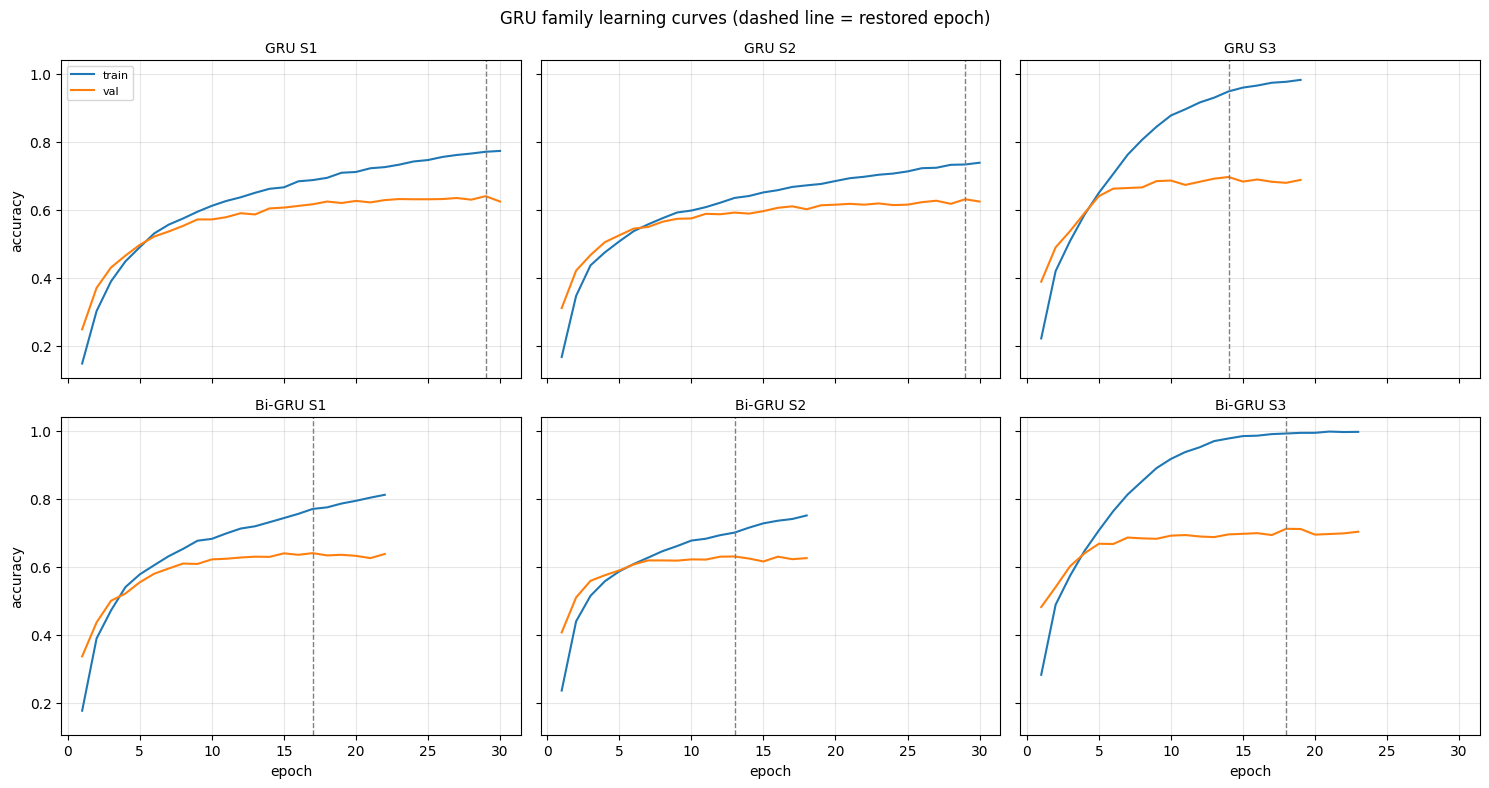

runs that reached the 30-epoch cap without early stopping: ['GRU_S1', 'GRU_S2']


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for row, model_name in enumerate(["GRU", "Bi-GRU"]):
    for col, cfg_id in enumerate(["S1", "S2", "S3"]):
        h = HISTORIES[f"{model_name}_{cfg_id}"]
        ax = axes[row, col]
        ax.plot(range(1, len(h["accuracy"]) + 1), h["accuracy"], label="train")
        ax.plot(range(1, len(h["val_accuracy"]) + 1), h["val_accuracy"], label="val")
        ax.axvline(int(np.argmax(h["val_accuracy"])) + 1, ls="--", lw=1, c="grey")
        ax.set_title(f"{model_name} {cfg_id}", fontsize=10)
        ax.grid(alpha=0.3)
        if col == 0:
            ax.set_ylabel("accuracy")
        if row == 1:
            ax.set_xlabel("epoch")
axes[0, 0].legend(fontsize=8)
fig.suptitle("GRU family learning curves (dashed line = restored epoch)", fontsize=12)
fig.tight_layout()
fig.savefig(DIRS["fig/gru"] / "gru_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

capped = [rid for rid, h in HISTORIES.items() if len(h["loss"]) >= EPOCHS]
print(f"runs that reached the {EPOCHS}-epoch cap without early stopping: "
      f"{capped if capped else 'none'}")

### Embedding contrast

S1 against S2 holds units, dropout and the frozen flag fixed. Only the embedding
source changes, so the difference is attributable.

The prediction was that Word2Vec would win everywhere. It covers the full vocabulary
against GloVe's 87.3%, and the missing 12.7% are the newsgroup-specific technical
tokens where topic signal concentrates.

The result splits by architecture:

| Model | S1 GloVe | S2 Word2Vec | Winner |
| --- | --- | --- | --- |
| SimpleRNN | 0.2853 | 0.3351 | Word2Vec +0.0498 |
| Bi-SimpleRNN | 0.3880 | 0.4114 | Word2Vec +0.0234 |
| GRU | 0.6287 | 0.6131 | GloVe +0.0156 |
| Bi-GRU | 0.6270 | 0.6104 | GloVe +0.0166 |
| LSTM | 0.6120 | 0.6094 | GloVe +0.0026 |
| Bi-LSTM | 0.6378 | 0.6130 | GloVe +0.0248 |

Both ungated models prefer Word2Vec. All four gated models prefer GloVe.

Coverage and quality are different things. Word2Vec covers every word but was trained
on roughly 9,000 documents, so each vector rests on little evidence. GloVe covers
87.3% but was estimated from six billion tokens of general English.

The SimpleRNN cannot carry information across long distances. It leans on individual
token identity, so full coverage helps it most and a noisy vector still beats no
vector. The gated models build context across the sequence. They can exploit the finer
semantic structure in the better-estimated vectors, and they lose little from GloVe's
missing 12.7% because surrounding words supply what a zero vector does not.

S2 against S3 is the largest jump in the grid. That suggests the frozen embedding, not
the cell type, was the binding constraint.

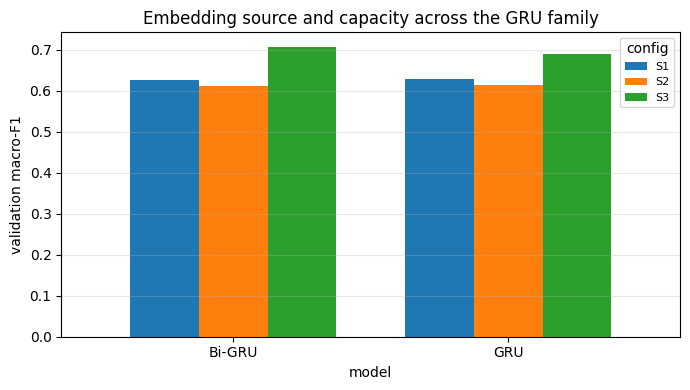

GRU      S1 glove 0.6287 -> S2 word2vec 0.6131  delta -0.0156
Bi-GRU   S1 glove 0.6270 -> S2 word2vec 0.6104  delta -0.0166


In [ ]:
runs = pd.read_csv(RUNS_CSV)
seq_runs = runs[runs.model.isin(["GRU", "Bi-GRU"])]

pivot = seq_runs.pivot_table(index="model", columns="config", values="val_macro_f1")
fig, ax = plt.subplots(figsize=(7, 4))
pivot[["S1", "S2", "S3"]].plot(kind="bar", ax=ax, rot=0, width=0.75)
ax.set_ylabel("validation macro-F1")
ax.set_title("Embedding source and capacity across the GRU family")
ax.legend(title="config", fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(DIRS["fig/gru"] / "gru_embedding_contrast.png", dpi=150, bbox_inches="tight")
plt.show()

for m in ["GRU", "Bi-GRU"]:
    s1 = pivot.loc[m, "S1"]
    s2 = pivot.loc[m, "S2"]
    print(f"{m:8s} S1 glove {s1:.4f} -> S2 word2vec {s2:.4f}  "
          f"delta {s2 - s1:+.4f}")

## Validation leaderboard

Configurations are selected on the highest validation macro-F1, not accuracy. With 20
classes and an imbalanced test split, macro-F1 weights every class equally, so a model
cannot score well by doing well only on the largest groups.

The test set is untouched to this point.

   run_id  model config embedding  units  dropout  trainable_emb  epochs_run  best_epoch  val_accuracy  val_macro_f1  train_time_s
Bi-GRU_S3 Bi-GRU     S3  word2vec    128      0.5           True          23          18      0.711574      0.706949          89.9
   GRU_S3    GRU     S3  word2vec    128      0.5           True          19          14      0.696877      0.688791          51.7
   GRU_S1    GRU     S1     glove     64      0.3          False          30          29      0.640539      0.628668          71.6
Bi-GRU_S1 Bi-GRU     S1     glove     64      0.3          False          22          17      0.639927      0.627035          81.8
   GRU_S2    GRU     S2  word2vec     64      0.3          False          30          29      0.631353      0.613096          90.1
Bi-GRU_S2 Bi-GRU     S2  word2vec     64      0.3          False          18          13      0.630129      0.610408          65.1

best GRU      -> S3  (val macro-F1 0.6888, val acc 0.6969)
best Bi-GRU   -> S3  (v

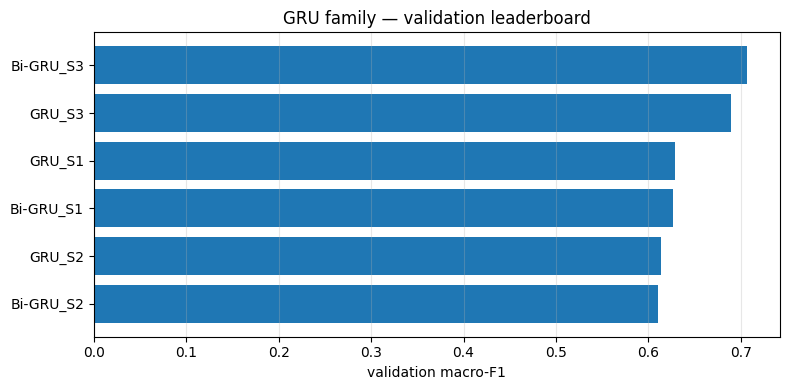

In [ ]:
runs = pd.read_csv(RUNS_CSV)
seq_runs = runs[runs.model.isin(["GRU", "Bi-GRU"])].copy()

board = ev.leaderboard(seq_runs, by="val_macro_f1")
print(board[["run_id", "model", "config", "embedding", "units", "dropout",
             "trainable_emb", "epochs_run", "best_epoch",
             "val_accuracy", "val_macro_f1", "train_time_s"]].to_string(index=False))

BEST_SEQ = {}
for m in ["GRU", "Bi-GRU"]:
    sub = seq_runs[seq_runs.model == m]
    BEST_SEQ[m] = sub.loc[sub.val_macro_f1.idxmax(), "config"]

print()
for m, c in BEST_SEQ.items():
    r = seq_runs[(seq_runs.model == m) & (seq_runs.config == c)].iloc[0]
    print(f"best {m:8s} -> {c}  (val macro-F1 {r.val_macro_f1:.4f}, "
          f"val acc {r.val_accuracy:.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(board.run_id, board.val_macro_f1)
ax.invert_yaxis()
ax.set_xlabel("validation macro-F1")
ax.set_title("GRU family — validation leaderboard")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(DIRS["fig/gru"] / "gru_val_leaderboard.png", dpi=150, bbox_inches="tight")
plt.show()

## Test evaluation

Only the winning configuration of each model goes to test, and only once.

The architecture is rebuilt from the frozen grid and the saved weights are reloaded. No
model object is reused from memory, so this reproduces on a fresh runtime from the saved
artifacts alone.

`ev.evaluate_model` returns everything section 3.9 requires: accuracy, macro and
weighted F1, the full classification report, the row-normalised confusion matrix, and
the within-family against cross-family error split.

In [ ]:
TEST_RESULTS = {}
TEST_PREDS = {}

for model_name, cfg_id in BEST_SEQ.items():
    cfg = SEQ_GRID[cfg_id]
    run_id = f"{model_name}_{cfg_id}"

    keras.backend.clear_session()
    gc.collect()
    model = build_sequence_model(
        cell=layers.GRU,
        embedding_matrix=EMB[cfg["embedding"]],
        units=cfg["units"], dropout=cfg["dropout"],
        trainable_emb=cfg["trainable_emb"],
        bidirectional=(model_name == "Bi-GRU"),
    )
    model.load_weights(DIRS["gru/weights"] / f"{run_id}.weights.h5")

    test_probs = model.predict(X_test_seq, verbose=0)
    res = ev.evaluate_model(y_test, test_probs, CLASSES, SUPERCLASS,
                            model_name=f"{model_name} {cfg_id}", split="test")
    TEST_RESULTS[f"{model_name} {cfg_id}"] = res
    TEST_PREDS[f"{model_name} {cfg_id}"] = ev.to_labels(test_probs)

    ev.save_result(res, DIRS["gru/reports"], f"test_{model_name}_{cfg_id}")

    row = runs[runs.run_id == run_id].iloc[0].to_dict()
    row.update({"test_accuracy": res["accuracy"],
                "test_macro_f1": res["macro_f1"],
                "test_weighted_f1": res["weighted_f1"],
                "notes": "required run | best config, evaluated on test"})
    ev.log_run(RUNS_CSV, row)
    print()

/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


GRU S3  [test]
  accuracy    : 0.6304
  macro-F1    : 0.6214
  weighted-F1 : 0.6320
  errors      : 2,684 (1,016 within-family = 37.9%, 1,668 cross-family = 62.1%)
logged GRU_S3 -> runs_zawad.csv (6 rows)



/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Bi-GRU S3  [test]
  accuracy    : 0.6409
  macro-F1    : 0.6304
  weighted-F1 : 0.6413
  errors      : 2,608 (999 within-family = 38.3%, 1,609 cross-family = 61.7%)
logged Bi-GRU_S3 -> runs_zawad.csv (6 rows)



### Classification reports

Printed in full. The brief requires a full classification report per model, and a cell
without visible output cannot be verified.

The saved JSON in `results/zawad/gru/reports/` holds the same numbers in
machine-readable form for whoever assembles the consolidated table.

In [ ]:
for name, res in TEST_RESULTS.items():
    print("="*72)
    print(f"{name}  [test]")
    print("="*72)
    print(res["report_str"])

GRU S3  [test]
                          precision    recall  f1-score   support

             alt.atheism     0.4928    0.2201    0.3043       309
           comp.graphics     0.5990    0.6257    0.6120       382
 comp.os.ms-windows.misc     0.5569    0.5937    0.5747       379
comp.sys.ibm.pc.hardware     0.5124    0.6458    0.5714       384
   comp.sys.mac.hardware     0.7738    0.5285    0.6280       369
          comp.windows.x     0.7243    0.6333    0.6758       390
            misc.forsale     0.5806    0.7639    0.6598       377
               rec.autos     0.6716    0.6131    0.6410       367
         rec.motorcycles     0.7375    0.6527    0.6925       383
      rec.sport.baseball     0.7932    0.8080    0.8005       375
        rec.sport.hockey     0.8615    0.8660    0.8638       388
               sci.crypt     0.7629    0.7082    0.7345       377
         sci.electronics     0.4863    0.5132    0.4994       380
                 sci.med     0.7747    0.6623    0.7141     

### Confusion matrices and per-class F1

Row-normalised. A bright off-diagonal cell means a class is losing a large share of
its own documents, not that the class is large.

The structure is block-shaped, which shows the errors are semantic and not random.
Bi-GRU's largest confusions are `comp.windows.x` losing 19.2% to
`comp.os.ms-windows.misc`, and `comp.sys.mac.hardware` losing 17.1% to
`comp.sys.ibm.pc.hardware`.

BERT roughly halves both, to 9.0% and 8.6%. That is the contextual embedding advantage
showing up where vocabulary overlap is highest.

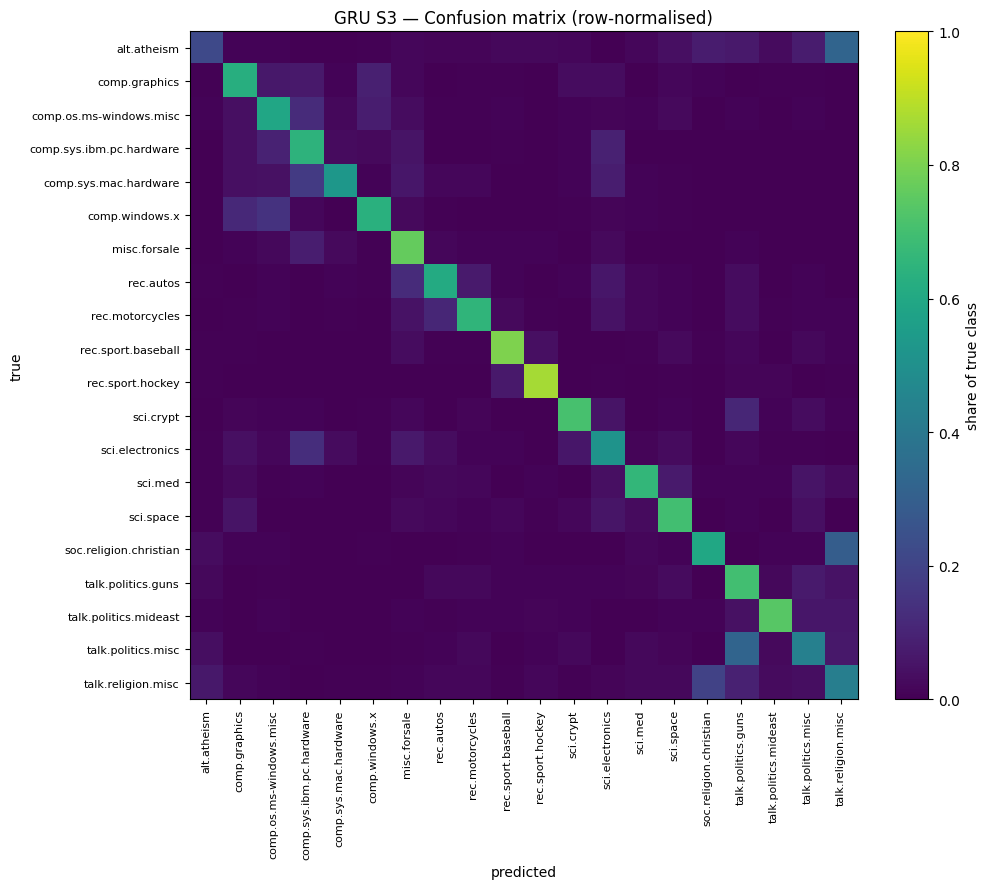

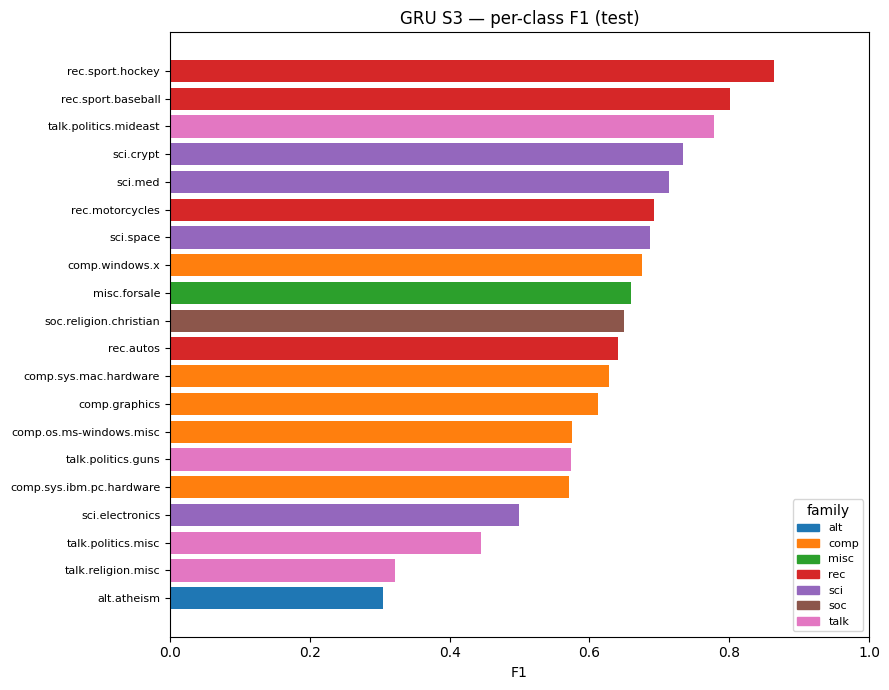

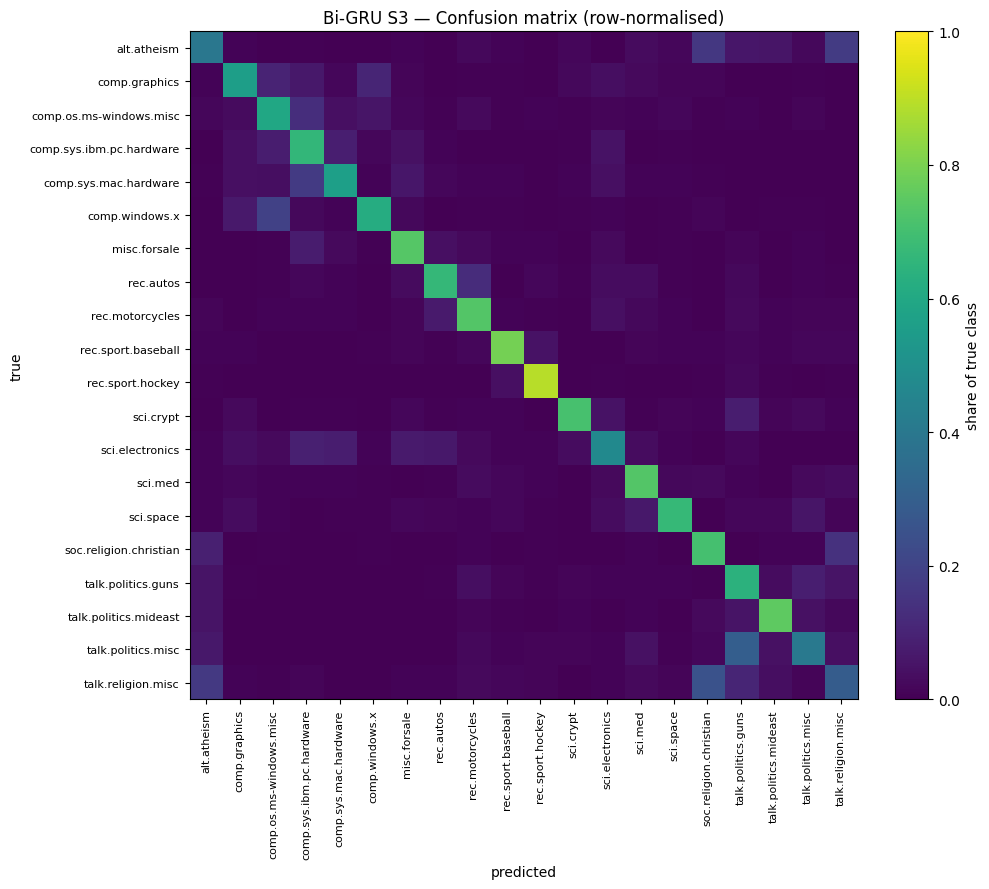

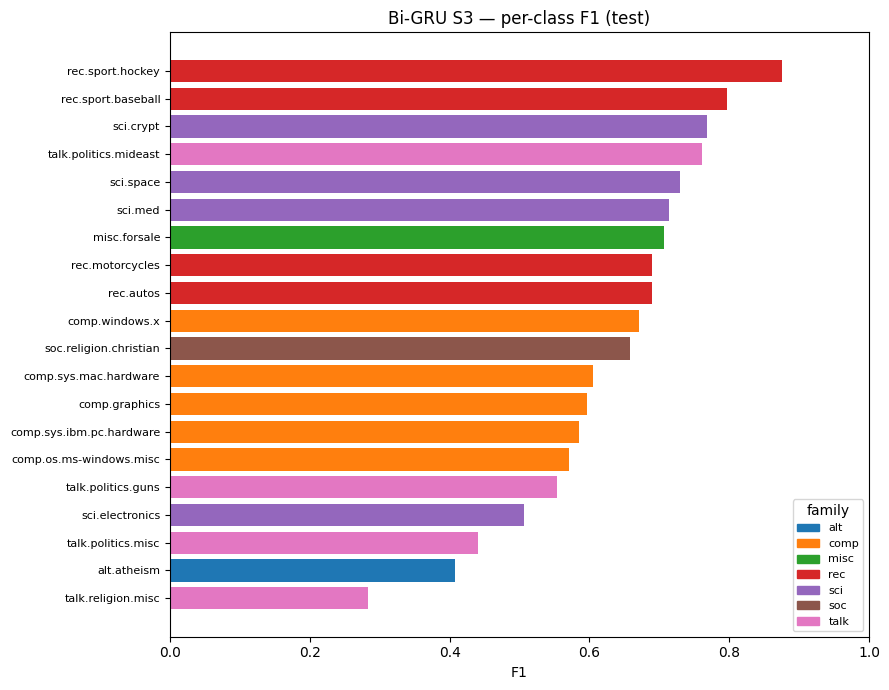

In [ ]:
for name, res in TEST_RESULTS.items():
    stem = name.replace(" ", "_")
    ev.plot_confusion_matrix(res, CLASSES,
                             save_path=DIRS["fig/gru"] / f"cm_{stem}.png")
    plt.show()
    ev.plot_per_class_f1(res, save_path=DIRS["fig/gru"] / f"f1_{stem}.png")
    plt.show()

### Where the errors fall

The 20 labels group into 7 families, so a misclassification splits into two kinds.
Confusing two `comp.sys.*` groups is a fine-grained failure between similar topics.
Confusing one with `talk.politics.guns` is a failure at topic identification.

If errors were random across the other 19 labels, about 15% would land within-family.
Observed: GRU 37.9%, Bi-GRU 38.3%, BERT 39.9%. Every model runs about two and a half
times the chance rate. BERT is highest, meaning it clears the easy cross-family errors
and what remains sits in genuinely confusable pairs.

One caveat on the metric. `alt.atheism`, `soc.religion.christian` and
`talk.religion.misc` sit in three different families but are the most semantically
adjacent trio in the dataset. Four of BERT's five largest confusions are among them.
They count as cross-family, so the 60% figure overstates the failure.

GRU S3
  errors        : 2,684
  within-family : 1,016 (37.9%)
  cross-family  : 1,668 (62.1%)

Bi-GRU S3
  errors        : 2,608
  within-family : 999 (38.3%)
  cross-family  : 1,609 (61.7%)

Most frequent confusions — Bi-GRU S3
                   true                predicted  count  pct_of_true_class  same_family
     talk.politics.misc       talk.politics.guns     90             0.2980         True
         comp.windows.x  comp.os.ms-windows.misc     75             0.1923         True
  comp.sys.mac.hardware comp.sys.ibm.pc.hardware     63             0.1707         True
     talk.religion.misc   soc.religion.christian     61             0.2510        False
 soc.religion.christian       talk.religion.misc     55             0.1432        False
            alt.atheism       talk.religion.misc     54             0.1748        False
            alt.atheism   soc.religion.christian     50             0.1618        False
comp.os.ms-windows.misc comp.sys.ibm.pc.hardware     50           

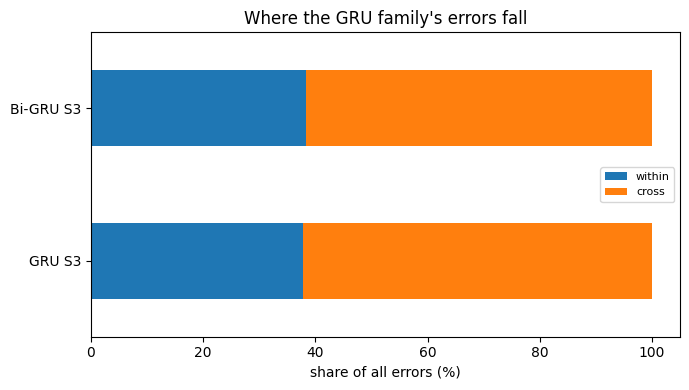

In [ ]:
for name, res in TEST_RESULTS.items():
    f = res["family"]
    print(f"{name}")
    print(f"  errors        : {f['n_errors']:,}")
    print(f"  within-family : {f['within_family']:,} ({f['within_share']:.1%})")
    print(f"  cross-family  : {f['cross_family']:,} ({f['cross_share']:.1%})")
    print()

best_seq_name = max(TEST_RESULTS, key=lambda k: TEST_RESULTS[k]["macro_f1"])
print("="*72)
print(f"Most frequent confusions — {best_seq_name}")
print("="*72)
print(ev.top_confusions(y_test, TEST_PREDS[best_seq_name],
                        CLASSES, SUPERCLASS, k=12).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
fam = pd.DataFrame({
    n: {"within": r["family"]["within_share"] * 100,
        "cross":  r["family"]["cross_share"] * 100}
    for n, r in TEST_RESULTS.items()
}).T
fam.plot(kind="barh", stacked=True, ax=ax)
ax.set_xlabel("share of all errors (%)")
ax.set_title("Where the GRU family's errors fall")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(DIRS["fig/gru"] / "gru_family_error_split.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 10: BERT Base

TensorFlow is released before PyTorch is imported. Both frameworks share one T4.
Memory growth was enabled in section 0, but the six recurrent models left allocations
behind. Clearing the Keras session and collecting returns that memory so `Trainer`
starts on a clean card.

In [ ]:
keras.backend.clear_session()
for _v in ["_demo"]:
    if _v in globals():
        del globals()[_v]
gc.collect()

import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          set_seed as hf_set_seed)
import transformers

hf_set_seed(SEED)

print(f"torch        : {torch.__version__}")
print(f"transformers : {transformers.__version__}")
print(f"cuda         : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"device       : {torch.cuda.get_device_name(0)}")
    print(f"vram total   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"vram in use  : {torch.cuda.memory_allocated() / 1e9:.2f} GB")

torch        : 2.11.0+cu128
transformers : 5.15.0
cuda         : True
device       : Tesla T4
vram total   : 15.6 GB
vram in use  : 0.00 GB


### Input text and why it differs from the recurrent tier

BERT reads `text_raw`. The recurrent models read `text_clean`. This is a deliberate
choice and needs stating plainly, because otherwise it looks like an oversight.

`text_clean` is lowercased, stopword-stripped and lemmatised. Those steps help a
50-dimensional embedding with a small recurrent cell. They shrink the vocabulary and
drop tokens that carry little signal for that kind of model.

They hurt BERT. Casing, punctuation and function words are the surface structure
WordPiece and the positional encodings were pretrained on. Stripping them throws away
information the pretrained weights already know how to use.

The usual objection to raw text on this dataset is metadata leakage, where models
learn email signatures instead of topic. That does not apply. The SetFit build already
removed headers, footers and quoted replies. The measurement below confirms it.

In [ ]:
leak = {
    "contains 'From:'":     train_df.text_raw.str.contains("From:").mean(),
    "contains 'Subject:'":  train_df.text_raw.str.contains("Subject:").mean(),
    "contains quoted '>'":  train_df.text_raw.str.contains("\n>").mean(),
}
for k, v in leak.items():
    print(f"{k:24s} {v:.1%} of training documents")

print()
print("text_clean (RNN input):")
print(f"  {train_df.text_clean.iloc[0][:150]!r}")
print()
print("text_raw (BERT input):")
print(f"  {train_df.text_raw.iloc[0][:150]!r}")

contains 'From:'         1.1% of training documents
contains 'Subject:'      0.8% of training documents
contains quoted '>'      0.0% of training documents

text_clean (RNN input):
  'yes say absolutey true fail mention fact lciii us new pin simms allow bite access simm case iii one simm slot access bite wides view express post indi'

text_raw (BERT input):
  'Yes! what you are saying is absolutey true, but what you fail to mention is the\nfact that the LCIII uses the new 72 pin simms which allow 32 bit acces'


### Sequence length

`max_len` comes from a measurement, not a default. The lab template uses 128. The
distribution below shows that would discard half the corpus.

Attention cost grows with the square of sequence length, so 512 costs well over twice
what 256 costs. On a T4 with a session limit, three configurations at 512 leaves no
slack for a disconnect. 256 covers the median document twice over and truncates about
a quarter of the corpus. Section 10b measures what that quarter is worth.

One point for the report. The recurrent models read 250 tokens of cleaned text.
Cleaning removes roughly half the tokens, so 250 clean tokens spans more of the
original document than 256 WordPiece tokens does. BERT is not getting a longer view
than the RNNs. It is getting a shorter one.

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2604 > 512). Running this sequence through the model will result in indexing errors


WordPiece token counts on text_raw (train, n=9,249)
  median 130  mean 355  p90 486  max 51937
  tokens per word: 1.88

  max_len 128 -> 50.4% truncated
  max_len 256 -> 24.4% truncated
  max_len 384 -> 13.9% truncated
  max_len 512 -> 9.1% truncated

chosen: max_len 256 (24.4% truncated)


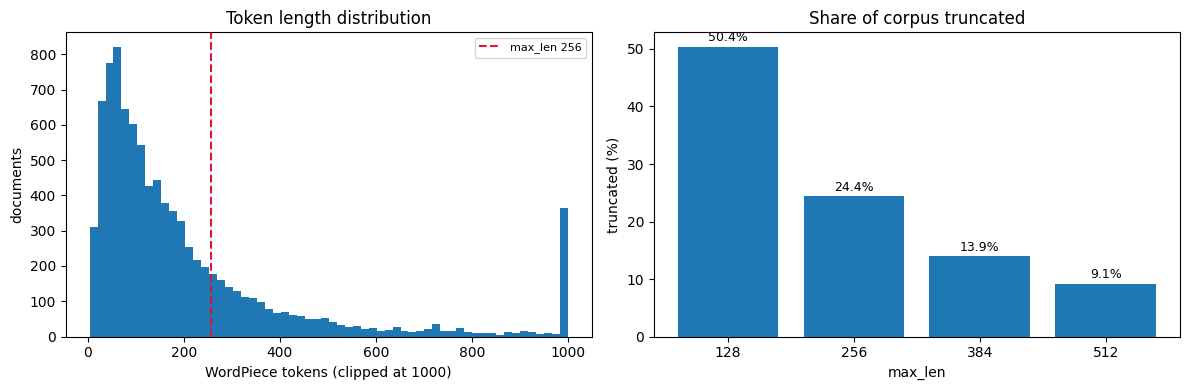

In [ ]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

_full = tokenizer(train_df.text_raw.tolist(), truncation=False)["input_ids"]
tok_lens = np.array([len(x) for x in _full])

print(f"WordPiece token counts on text_raw (train, n={len(tok_lens):,})")
print(f"  median {int(np.median(tok_lens))}  mean {int(tok_lens.mean())}  "
      f"p90 {int(np.percentile(tok_lens, 90))}  max {int(tok_lens.max())}")
print(f"  tokens per word: {tok_lens.mean() / train_df.text_raw.str.split().str.len().mean():.2f}")
print()
trunc = {}
for L in (128, 256, 384, 512):
    trunc[L] = float((tok_lens > L).mean())
    print(f"  max_len {L:3d} -> {trunc[L]:.1%} truncated")

MAX_LEN_BERT = 256
print(f"\nchosen: max_len {MAX_LEN_BERT} ({trunc[MAX_LEN_BERT]:.1%} truncated)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.clip(tok_lens, 0, 1000), bins=60)
axes[0].axvline(MAX_LEN_BERT, color="crimson", ls="--", label=f"max_len {MAX_LEN_BERT}")
axes[0].set_xlabel("WordPiece tokens (clipped at 1000)")
axes[0].set_ylabel("documents")
axes[0].set_title("Token length distribution")
axes[0].legend(fontsize=8)
axes[1].bar([str(k) for k in trunc], [v * 100 for v in trunc.values()])
axes[1].set_xlabel("max_len")
axes[1].set_ylabel("truncated (%)")
axes[1].set_title("Share of corpus truncated")
for i, v in enumerate(trunc.values()):
    axes[1].text(i, v * 100 + 1, f"{v:.1%}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(DIRS["fig/bert"] / "bert_truncation.png", dpi=150, bbox_inches="tight")
plt.show()

### Configurations

The S1, S2, S3 axis means nothing for BERT. The embedding is not a choice, and there is
no frozen against trainable decision because fine-tuning updates all 110 million
parameters by design.

So BERT gets three configurations on learning rate, the axis that decides fine-tuning
outcomes.

| Config | Learning rate | Epochs | Batch |
| --- | --- | --- | --- |
| B1 | 2e-5 | 3 | 16 |
| B2 | 3e-5 | 3 | 16 |
| B3 | 5e-5 | 4 | 32 |

The 2e-5 to 5e-5 range is what the original BERT paper reports for fine-tuning. It sits
three orders of magnitude below the 1e-3 used for the recurrent models because the
pretrained weights are already good, and a large step destroys knowledge that cost
nothing to acquire. The same reasoning explains warmup, gradient clipping and the low
epoch count.

B3 moves batch size and epochs alongside the learning rate, so it is not a
single-variable comparison against B1 and B2 and is not read as one.

`fp16` is used, not `bf16`. The T4 is a Turing card with no bfloat16 support.
`transformers` 5.x expects `warmup_steps` rather than `warmup_ratio`, so the ratio is
converted at call time and the derived step count is printed with each run.

In [ ]:
BERT_GRID = {
    "B1": {"learning_rate": 2e-5, "epochs": 3, "batch_size": 16},
    "B2": {"learning_rate": 3e-5, "epochs": 3, "batch_size": 16},
    "B3": {"learning_rate": 5e-5, "epochs": 4, "batch_size": 32},
}
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01

print(pd.DataFrame(BERT_GRID).T.to_string())
print(f"\nmax_len {MAX_LEN_BERT} | warmup_ratio {WARMUP_RATIO} | "
      f"weight_decay {WEIGHT_DECAY} | fp16 True | seed {SEED}")

    learning_rate  epochs  batch_size
B1        0.00002     3.0        16.0
B2        0.00003     3.0        16.0
B3        0.00005     4.0        32.0

max_len 256 | warmup_ratio 0.1 | weight_decay 0.01 | fp16 True | seed 42


### Dataset and metrics

Tokenised once with truncation and no padding. `DataCollatorWithPadding` pads each
batch to its own longest member instead of to `max_len`. That is meaningfully faster
here, since the median document is 130 tokens against a 256 ceiling.

`compute_metrics` returns macro-F1 alongside accuracy. The default `Trainer` example
reports accuracy only. Every other model in this project is selected on macro-F1, and
the rule has to be identical across all ten.

In [ ]:
from sklearn.metrics import accuracy_score, f1_score


class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = int(self.labels[idx])
        return item


def encode(texts):
    return tokenizer(list(texts), truncation=True, max_length=MAX_LEN_BERT)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro",
                             labels=list(range(NUM_CLASSES)), zero_division=0),
    }


enc_train = encode(train_df.text_raw)
enc_val   = encode(val_df.text_raw)
enc_test  = encode(test_df.text_raw)

ds_train = NewsDataset(enc_train, y_train)
ds_val   = NewsDataset(enc_val,   y_val)
ds_test  = NewsDataset(enc_test,  y_test)

collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"tokenised  : train {len(ds_train):,}  val {len(ds_val):,}  test {len(ds_test):,}")
print(f"sample len : {len(ds_train[0]['input_ids'])} tokens (before batch padding)")
print(f"metrics    : accuracy, macro_f1")

tokenised  : train 9,249  val 1,633  test 7,262
sample len : 256 tokens (before batch padding)
metrics    : accuracy, macro_f1


### Fine-tuning loop

`load_best_model_at_end` with `metric_for_best_model="macro_f1"` does the same job as
`restore_best_weights=True` in the recurrent models. Both tiers are selected the same
way.

Checkpoints go to local Colab disk with `save_total_limit=1`, never to Drive. A
`bert-base` checkpoint is about 420 MB and three configurations would push over a
gigabyte. Only the winner is copied to Drive at the end of this section.

Each row is written to `runs_zawad.csv` as its configuration finishes.

In [ ]:
BERT_HISTORIES = {}


def run_bert(config_id, notes="required run", max_len_override=None,
             run_id_override=None):
    cfg = BERT_GRID[config_id]
    run_id = run_id_override or f"BERT_{config_id}"
    max_len = max_len_override or MAX_LEN_BERT

    if max_len_override:
        ds_tr = NewsDataset(tokenizer(list(train_df.text_raw), truncation=True,
                                      max_length=max_len), y_train)
        ds_va = NewsDataset(tokenizer(list(val_df.text_raw), truncation=True,
                                      max_length=max_len), y_val)
    else:
        ds_tr, ds_va = ds_train, ds_val

    steps_per_epoch = int(np.ceil(len(ds_tr) / cfg["batch_size"]))
    total_steps = steps_per_epoch * cfg["epochs"]
    warmup_steps = int(WARMUP_RATIO * total_steps)

    hf_set_seed(SEED)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_CLASSES)

    args = TrainingArguments(
        output_dir=str(BERT_SCRATCH / run_id),
        learning_rate=cfg["learning_rate"],
        per_device_train_batch_size=cfg["batch_size"],
        per_device_eval_batch_size=64,
        num_train_epochs=cfg["epochs"],
        weight_decay=WEIGHT_DECAY,
        warmup_steps=warmup_steps,
        max_grad_norm=1.0,
        fp16=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_strategy="epoch",
        report_to="none",
        seed=SEED,
    )

    trainer = Trainer(
        model=model, args=args,
        train_dataset=ds_tr, eval_dataset=ds_va,
        data_collator=collator, compute_metrics=compute_metrics,
    )

    print(f"\n{'='*66}\n{run_id}  |  lr {cfg['learning_rate']}  "
          f"epochs {cfg['epochs']}  batch {cfg['batch_size']}  max_len {max_len}"
          f"\n{'='*66}")
    print(f"  {steps_per_epoch} steps/epoch, {total_steps} total, "
          f"warmup {warmup_steps} steps ({WARMUP_RATIO:.0%})")

    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0

    evals = [h for h in trainer.state.log_history if "eval_macro_f1" in h]
    BERT_HISTORIES[run_id] = evals
    best_epoch = int(np.argmax([h["eval_macro_f1"] for h in evals])) + 1
    best = evals[best_epoch - 1]

    val_logits = trainer.predict(ds_va).predictions
    if isinstance(val_logits, tuple):
        val_logits = val_logits[0]
    res_val = ev.evaluate_model(y_val, val_logits, CLASSES, SUPERCLASS,
                                model_name=f"BERT-Base {config_id}", split="val")

    with open(DIRS["bert/history"] / f"{run_id}.json", "w") as fh:
        json.dump(evals, fh, indent=2)

    ev.log_run(RUNS_CSV, {
        "run_id": run_id, "owner": OWNER, "notebook": NOTEBOOK,
        "tier": "transformer",
        "model": "BERT-Base", "config": config_id,
        "embedding": "wordpiece", "units": np.nan, "dropout": np.nan,
        "trainable_emb": True,
        "batch_size": cfg["batch_size"], "learning_rate": cfg["learning_rate"],
        "epochs_run": cfg["epochs"], "best_epoch": best_epoch,
        "n_params": int(sum(p.numel() for p in model.parameters())),
        "hyperparams": json.dumps({"max_len": max_len,
                                   "warmup_ratio": WARMUP_RATIO,
                                   "warmup_steps": warmup_steps,
                                   "weight_decay": WEIGHT_DECAY,
                                   "max_grad_norm": 1.0,
                                   "fp16": True,
                                   "base_model": MODEL_NAME}),
        "val_loss": float(best["eval_loss"]),
        "val_accuracy": res_val["accuracy"], "val_macro_f1": res_val["macro_f1"],
        "test_accuracy": np.nan, "test_macro_f1": np.nan, "test_weighted_f1": np.nan,
        "train_time_s": round(train_time, 1),
        "dataset_checksum": CHECKSUM_TRAIN,
        "notes": notes,
    })

    print(f"{run_id}: best epoch {best_epoch}, {train_time/60:.1f} min")
    return trainer


print(f"BERT harness ready (transformers {transformers.__version__})")
print(f"warmup_ratio {WARMUP_RATIO:.0%} converted to warmup_steps at call time")

BERT harness ready (transformers 5.15.0)
warmup_ratio 10% converted to warmup_steps at call time


In [ ]:
TRAINERS = {}
for cfg_id in ["B1", "B2", "B3"]:
    TRAINERS[cfg_id] = run_bert(cfg_id)
    torch.cuda.empty_cache()
    gc.collect()

print("\n" + "="*66)
print("BERT grid complete — 9 of 9 required runs done")
print(pd.read_csv(RUNS_CSV)[["run_id", "model", "config", "epochs_run",
                             "best_epoch", "val_accuracy", "val_macro_f1",
                             "train_time_s"]].to_string(index=False))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERT_B1  |  lr 2e-05  epochs 3  batch 16  max_len 256
  579 steps/epoch, 1737 total, warmup 173 steps (10%)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.832590,0.989131,0.714023,0.683639
2,0.811163,0.827260,0.748316,0.724518
3,0.541654,0.789958,0.767912,0.746305


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

BERT-Base B3  [val]
  accuracy    : 0.7832
  macro-F1    : 0.7753
  weighted-F1 : 0.7849
  errors      : 354 (135 within-family = 38.1%, 219 cross-family = 61.9%)
logged BERT_B3 -> runs_zawad.csv (9 rows)
BERT_B3: best epoch 4, 10.0 min

BERT grid complete — 9 of 9 required runs done
   run_id     model config  epochs_run  best_epoch  val_accuracy  val_macro_f1  train_time_s
   GRU_S1       GRU     S1          30          29      0.640539      0.628668          71.6
   GRU_S2       GRU     S2          30          29      0.631353      0.613096          90.1
Bi-GRU_S1    Bi-GRU     S1          22          17      0.639927      0.627035          81.8
Bi-GRU_S2    Bi-GRU     S2          18          13      0.630129      0.610408          65.1
   GRU_S3       GRU     S3          19          14      0.696877      0.688791          51.7
Bi-GRU_S3    Bi-GRU     S3          23          18      0.711574      0.706949          89.9
  BERT_B1 BERT-Base     B1           3           3      0.767912

### Selection and test evaluation

Same rule as everywhere else in the project. Highest validation macro-F1, evaluated
once on test.

 run_id  learning_rate  batch_size  epochs_run  best_epoch  val_loss  val_accuracy  val_macro_f1  train_time_s
BERT_B1        0.00002          16           3           3  0.789958      0.767912      0.746305         432.7
BERT_B2        0.00003          16           3           3  0.778914      0.777710      0.762659         472.7
BERT_B3        0.00005          32           4           4  0.782371      0.783221      0.775260         602.4

best BERT config -> B3


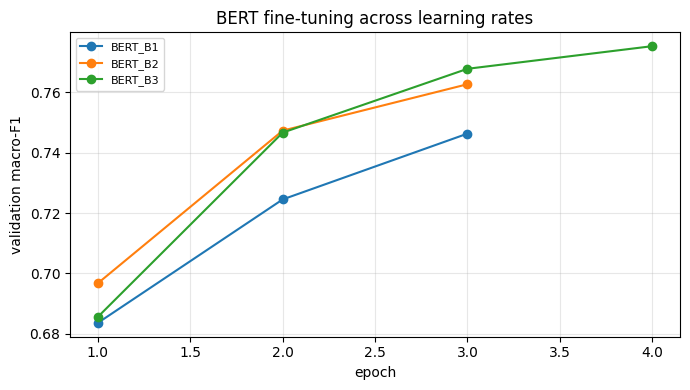

In [ ]:
runs = pd.read_csv(RUNS_CSV)
bert_runs = runs[runs.model == "BERT-Base"]
BEST_BERT = bert_runs.loc[bert_runs.val_macro_f1.idxmax(), "config"]

print(bert_runs[["run_id", "learning_rate", "batch_size", "epochs_run",
                 "best_epoch", "val_loss", "val_accuracy", "val_macro_f1",
                 "train_time_s"]].to_string(index=False))
print(f"\nbest BERT config -> {BEST_BERT}")

fig, ax = plt.subplots(figsize=(7, 4))
for rid, evals in BERT_HISTORIES.items():
    ax.plot([h["epoch"] for h in evals], [h["eval_macro_f1"] for h in evals],
            marker="o", label=rid)
ax.set_xlabel("epoch")
ax.set_ylabel("validation macro-F1")
ax.set_title("BERT fine-tuning across learning rates")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(DIRS["fig/bert"] / "bert_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
best_trainer = TRAINERS[BEST_BERT]

test_logits = best_trainer.predict(ds_test).predictions
res_bert = ev.evaluate_model(y_test, test_logits, CLASSES, SUPERCLASS,
                             model_name=f"BERT-Base {BEST_BERT}", split="test")

TEST_RESULTS[f"BERT-Base {BEST_BERT}"] = res_bert
TEST_PREDS[f"BERT-Base {BEST_BERT}"] = ev.to_labels(test_logits)

ev.save_result(res_bert, DIRS["bert/reports"], f"test_BERT-Base_{BEST_BERT}")

row = runs[runs.run_id == f"BERT_{BEST_BERT}"].iloc[0].to_dict()
row.update({"test_accuracy": res_bert["accuracy"],
            "test_macro_f1": res_bert["macro_f1"],
            "test_weighted_f1": res_bert["weighted_f1"],
            "notes": "required run | best config, evaluated on test"})
ev.log_run(RUNS_CSV, row)

print()
print(res_bert["report_str"])

BERT-Base B3  [test]
  accuracy    : 0.7345
  macro-F1    : 0.7225
  weighted-F1 : 0.7350
  errors      : 1,928 (770 within-family = 39.9%, 1,158 cross-family = 60.1%)
logged BERT_B3 -> runs_zawad.csv (9 rows)

                          precision    recall  f1-score   support

             alt.atheism     0.4966    0.4790    0.4876       309
           comp.graphics     0.7306    0.7382    0.7344       382
 comp.os.ms-windows.misc     0.6938    0.6755    0.6845       379
comp.sys.ibm.pc.hardware     0.6721    0.6406    0.6560       384
   comp.sys.mac.hardware     0.7098    0.7886    0.7471       369
          comp.windows.x     0.8508    0.7897    0.8191       390
            misc.forsale     0.8455    0.8568    0.8511       377
               rec.autos     0.8274    0.7575    0.7909       367
         rec.motorcycles     0.7730    0.7911    0.7819       383
      rec.sport.baseball     0.9091    0.8800    0.8943       375
        rec.sport.hockey     0.9162    0.9304    0.9233       

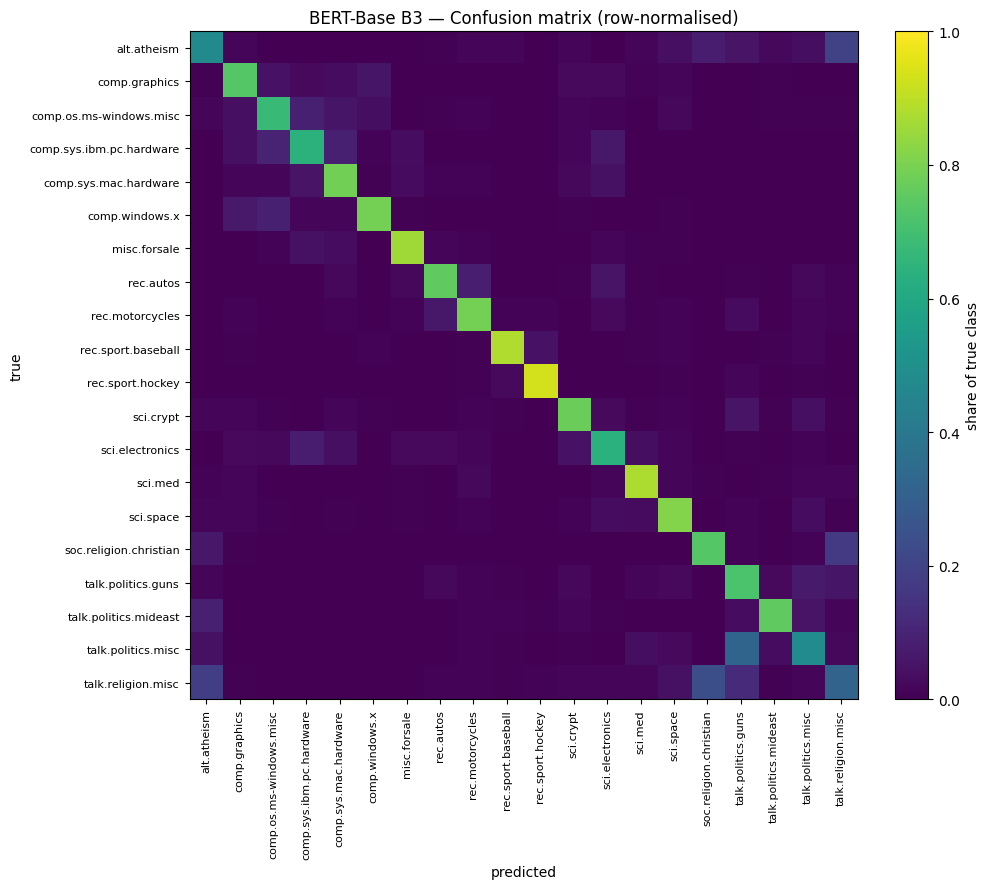

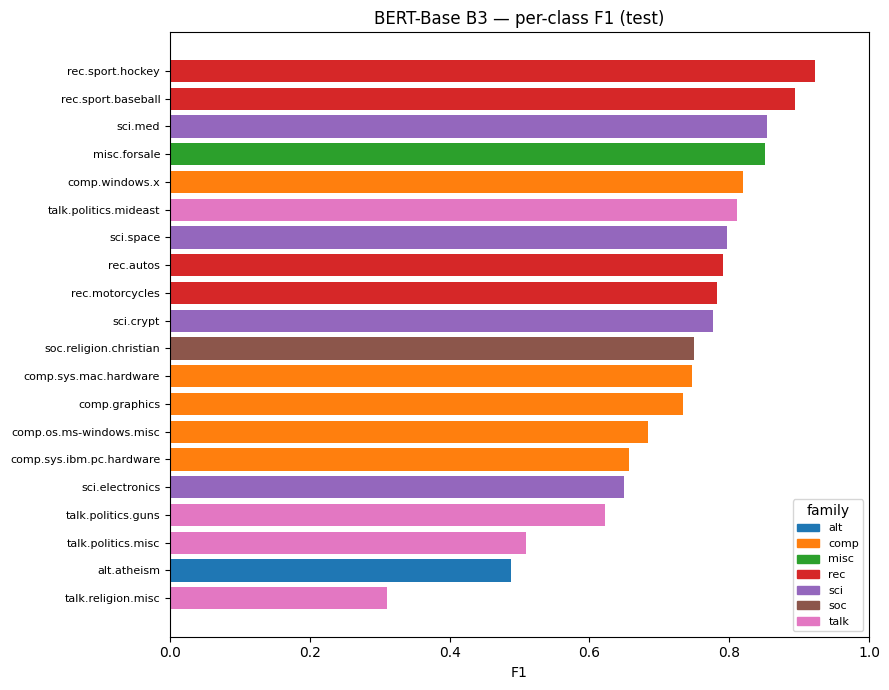

BERT-Base B3 error structure
  errors        : 1,928
  within-family : 770 (39.9%)
  cross-family  : 1,158 (60.1%)

                    true                predicted  count  pct_of_true_class  same_family
      talk.politics.misc       talk.politics.guns     97             0.3212         True
  soc.religion.christian       talk.religion.misc     65             0.1693        False
             alt.atheism       talk.religion.misc     61             0.1974        False
      talk.religion.misc   soc.religion.christian     58             0.2387        False
      talk.religion.misc              alt.atheism     45             0.1852        False
comp.sys.ibm.pc.hardware  comp.os.ms-windows.misc     36             0.0938         True
          comp.windows.x  comp.os.ms-windows.misc     35             0.0897         True
 comp.os.ms-windows.misc comp.sys.ibm.pc.hardware     34             0.0897         True
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware     33             0.0859        

In [ ]:
ev.plot_confusion_matrix(res_bert, CLASSES,
                         save_path=DIRS["fig/bert"] / f"cm_BERT-Base_{BEST_BERT}.png")
plt.show()
ev.plot_per_class_f1(res_bert,
                     save_path=DIRS["fig/bert"] / f"f1_BERT-Base_{BEST_BERT}.png")
plt.show()

f = res_bert["family"]
print(f"BERT-Base {BEST_BERT} error structure")
print(f"  errors        : {f['n_errors']:,}")
print(f"  within-family : {f['within_family']:,} ({f['within_share']:.1%})")
print(f"  cross-family  : {f['cross_family']:,} ({f['cross_share']:.1%})")
print()
print(ev.top_confusions(y_test, TEST_PREDS[f"BERT-Base {BEST_BERT}"],
                        CLASSES, SUPERCLASS, k=12).to_string(index=False))

### Saving the winning checkpoint

Only the best configuration goes to Drive, at about 420 MB. The two losing
configurations keep their per-epoch history and their row in the run log. That is
everything the report needs. Nobody reloads a configuration that lost.

In [ ]:
best_trainer.model.save_pretrained(DIRS["bert/checkpoint"])
tokenizer.save_pretrained(DIRS["bert/checkpoint"])

saved = sorted(DIRS["bert/checkpoint"].iterdir())
total = sum(p.stat().st_size for p in saved if p.is_file())
for p in saved:
    print(f"  {p.name:32s} {p.stat().st_size / 1e6:7.1f} MB")
print(f"\ntotal {total / 1e6:.0f} MB written to {DIRS['bert/checkpoint'].relative_to(DATA_DIR)}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  config.json                          0.0 MB
  model.safetensors                  438.0 MB
  tokenizer.json                       0.7 MB
  tokenizer_config.json                0.0 MB

total 439 MB written to results/zawad/bert/checkpoint_best


### Ablation: what truncation costs

Run last so a session drop cannot cost a required run.

24.4% of documents are cut at 256 tokens. Re-running the winning learning rate at
`max_len` 512, where 9.1% are cut, gives 0.7241 test macro-F1 against 0.7225.

Seeing 15.2% more of the corpus is worth **+0.0016 macro-F1** for 1.85 times the
training time, 1114 seconds against 602.

Topic signal in these documents is front-loaded. Truncation costs almost nothing and 256
is the right operating point. This matches the bidirectional result in section 9.6,
where reading the sequence backwards also added about one point.

In [ ]:
RUN_ABLATION = True

if RUN_ABLATION:
    torch.cuda.empty_cache()
    gc.collect()
    abl_trainer = run_bert(BEST_BERT,
                           notes="ablation | max_len 512, not a required run",
                           max_len_override=512,
                           run_id_override="BERT_ABL_512")

    abl_logits = abl_trainer.predict(
        NewsDataset(tokenizer(list(test_df.text_raw), truncation=True,
                              max_length=512), y_test)).predictions
    res_abl = ev.evaluate_model(y_test, abl_logits, CLASSES, SUPERCLASS,
                                model_name="BERT-Base ABL-512", split="test")
    ev.save_result(res_abl, DIRS["bert/reports"], "test_BERT-Base_ABL-512")

    runs = pd.read_csv(RUNS_CSV)
    row = runs[runs.run_id == "BERT_ABL_512"].iloc[0].to_dict()
    row.update({"test_accuracy": res_abl["accuracy"],
                "test_macro_f1": res_abl["macro_f1"],
                "test_weighted_f1": res_abl["weighted_f1"]})
    ev.log_run(RUNS_CSV, row)

    print()
    print(f"max_len 256 ({trunc[256]:.1%} truncated): "
          f"acc {res_bert['accuracy']:.4f}  macro-F1 {res_bert['macro_f1']:.4f}")
    print(f"max_len 512 ({trunc[512]:.1%} truncated): "
          f"acc {res_abl['accuracy']:.4f}  macro-F1 {res_abl['macro_f1']:.4f}")
    print(f"delta from seeing {trunc[256] - trunc[512]:.1%} more of the corpus: "
          f"{res_abl['macro_f1'] - res_bert['macro_f1']:+.4f} macro-F1")
else:
    print("ablation skipped")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



BERT_ABL_512  |  lr 5e-05  epochs 4  batch 32  max_len 512
  290 steps/epoch, 1160 total, warmup 116 steps (10%)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.746964,0.925654,0.720147,0.692642
2,0.702399,0.796864,0.765462,0.749411
3,0.390180,0.767475,0.789345,0.778935
4,0.197152,0.781201,0.782609,0.774547


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

BERT-Base B3  [val]
  accuracy    : 0.7887
  macro-F1    : 0.7782
  weighted-F1 : 0.7877
  errors      : 345 (130 within-family = 37.7%, 215 cross-family = 62.3%)
logged BERT_ABL_512 -> runs_zawad.csv (10 rows)
BERT_ABL_512: best epoch 3, 18.6 min


BERT-Base ABL-512  [test]
  accuracy    : 0.7380
  macro-F1    : 0.7241
  weighted-F1 : 0.7372
  errors      : 1,903 (778 within-family = 40.9%, 1,125 cross-family = 59.1%)
logged BERT_ABL_512 -> runs_zawad.csv (10 rows)

max_len 256 (24.4% truncated): acc 0.7345  macro-F1 0.7225
max_len 512 (9.1% truncated): acc 0.7380  macro-F1 0.7241
delta from seeing 15.2% more of the corpus: +0.0016 macro-F1


## Export

Three models, ten runs, one run log.

The comparison table below covers this notebook's models only. The project-wide table
across all ten models is assembled in section 12.

In [ ]:
runs = pd.read_csv(RUNS_CSV)

print("="*80)
print(f"TUNING TABLE — all {len(runs)} runs in this notebook")
print("="*80)
print(runs[["run_id", "model", "config", "embedding", "units", "dropout",
            "trainable_emb", "learning_rate", "epochs_run", "best_epoch",
            "val_accuracy", "val_macro_f1", "train_time_s"]].to_string(index=False))

required = runs[~runs.notes.fillna("").str.contains("ablation")]
print()
print(f"required runs : {len(required)} (expected 9)")
print(f"ablation runs : {len(runs) - len(required)}")
print(f"checksums     : {runs.dataset_checksum.nunique()} distinct "
      f"(expected 1) -> {runs.dataset_checksum.unique().tolist()}")
assert len(required) == 9, "expected 9 required runs"
assert runs.dataset_checksum.nunique() == 1, "runs used different data"
print("run-log integrity: PASS")

TUNING TABLE — all 10 runs in this notebook
      run_id     model config embedding  units  dropout  trainable_emb  learning_rate  epochs_run  best_epoch  val_accuracy  val_macro_f1  train_time_s
      GRU_S1       GRU     S1     glove   64.0      0.3          False        0.00100          30          29      0.640539      0.628668          71.6
      GRU_S2       GRU     S2  word2vec   64.0      0.3          False        0.00100          30          29      0.631353      0.613096          90.1
   Bi-GRU_S1    Bi-GRU     S1     glove   64.0      0.3          False        0.00100          22          17      0.639927      0.627035          81.8
   Bi-GRU_S2    Bi-GRU     S2  word2vec   64.0      0.3          False        0.00100          18          13      0.630129      0.610408          65.1
      GRU_S3       GRU     S3  word2vec  128.0      0.5           True        0.00100          19          14      0.696877      0.688791          51.7
   Bi-GRU_S3    Bi-GRU     S3  word2vec  128

TEST COMPARISON — best configuration per model
       model  accuracy  macro_f1  weighted_f1  errors  within_family_%  cross_family_%
BERT-Base B3    0.7345    0.7225       0.7350    1928          39.9378         60.0622
   Bi-GRU S3    0.6409    0.6304       0.6413    2608          38.3052         61.6948
      GRU S3    0.6304    0.6214       0.6320    2684          37.8539         62.1461


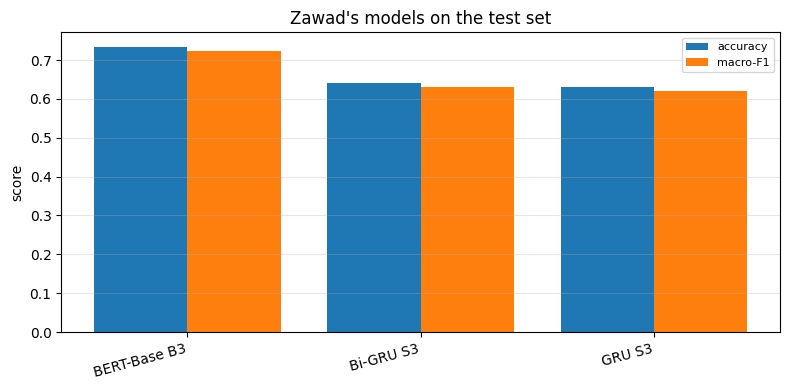

In [ ]:
comparison = ev.compare_models(TEST_RESULTS)
comparison.to_csv(RESULTS_DIR / "test_comparison_zawad.csv", index=False)

print("="*80)
print("TEST COMPARISON — best configuration per model")
print("="*80)
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(comparison))
ax.bar(x - 0.2, comparison.accuracy, 0.4, label="accuracy")
ax.bar(x + 0.2, comparison.macro_f1, 0.4, label="macro-F1")
ax.set_xticks(x)
ax.set_xticklabels(comparison.model, rotation=15, ha="right")
ax.set_ylabel("score")
ax.set_title("Zawad's models on the test set")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "zawad_test_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("="*80)
print("FILES WRITTEN")
print("="*80)
n = 0
for p in sorted(RESULTS_DIR.rglob("*")) + sorted(FIG_DIR.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(DATA_DIR)}  ({p.stat().st_size / 1e3:.0f} KB)")
        n += 1
print(f"\n{n} files under results/zawad/ and figures/zawad/")
print("no writes to splits/, representations/ or utils/")

FILES WRITTEN
  results/zawad/bert/checkpoint_best/config.json  (2 KB)
  results/zawad/bert/checkpoint_best/model.safetensors  (438014 KB)
  results/zawad/bert/checkpoint_best/tokenizer.json  (711 KB)
  results/zawad/bert/checkpoint_best/tokenizer_config.json  (0 KB)
  results/zawad/bert/history/BERT_ABL_512.json  (1 KB)
  results/zawad/bert/history/BERT_B1.json  (1 KB)
  results/zawad/bert/history/BERT_B2.json  (1 KB)
  results/zawad/bert/history/BERT_B3.json  (1 KB)
  results/zawad/bert/reports/test_BERT-Base_ABL-512.json  (9 KB)
  results/zawad/bert/reports/test_BERT-Base_B3.json  (9 KB)
  results/zawad/gru/history/Bi-GRU_S1.json  (2 KB)
  results/zawad/gru/history/Bi-GRU_S2.json  (2 KB)
  results/zawad/gru/history/Bi-GRU_S3.json  (2 KB)
  results/zawad/gru/history/GRU_S1.json  (3 KB)
  results/zawad/gru/history/GRU_S2.json  (3 KB)
  results/zawad/gru/history/GRU_S3.json  (2 KB)
  results/zawad/gru/reports/test_Bi-GRU_S3.json  (9 KB)
  results/zawad/gru/reports/test_GRU_S3.json  (9 

## Section 11 - Hyperparameter Tuning Summary

Section 3.8 of the brief requires every tuning run recorded in a dedicated table. This
section builds that table from the three run logs written during training. Nothing is
re-trained. Every number is read from files the four training notebooks produced.

The integrity checks are the evidence that the ten models are comparable. One dataset
checksum across all rows proves every model saw the same splits. One scoring module
produced every metric, so macro-F1 means the same thing in all rows.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import sys, json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR    = Path("/content/drive/MyDrive/cse440_project")
SPLIT_DIR   = DATA_DIR / "splits"
RESULTS_DIR = DATA_DIR / "results"
FIG_DIR     = DATA_DIR / "figures" / "final"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(DATA_DIR))
import utils.evaluation as ev

label_meta  = ev.load_label_meta(SPLIT_DIR)
CLASSES     = label_meta["classes"]
SUPERCLASS  = label_meta["superclass"]
NUM_CLASSES = label_meta["num_classes"]

log_files = sorted(RESULTS_DIR.rglob("runs_*.csv"))
print(f"run logs found: {len(log_files)}")
for f in log_files:
    print(f"  {f.relative_to(DATA_DIR)}")

runs = pd.concat([pd.read_csv(f) for f in log_files], ignore_index=True)
runs["kind"] = runs.notes.astype(str).str.split().str[0]

print(f"\nrows: {len(runs)} | columns: {len(runs.columns)}")
print(f"contributors: {sorted(runs.owner.unique())}")

Mounted at /content/drive
run logs found: 3
  results/fabiha/runs_fabiha.csv
  results/hasib/runs_hasib.csv
  results/zawad/runs_zawad.csv

rows: 36 | columns: 28
contributors: ['fabiha', 'hasib', 'zawad']


### Integrity checks

Thirty required runs, matching the brief exactly, plus six ablations. Ten models. One
distinct checksum. One schema across three separately written files.

In [ ]:
required = runs[runs.kind == "required"]
ablation = runs[runs.kind == "ablation"]

print("run counts by contributor")
print(pd.crosstab(runs.owner, runs.kind, margins=True).to_string())

print(f"\nrequired runs : {len(required)}  (brief requires 30)")
print(f"ablation runs : {len(ablation)}")
print(f"models covered: {runs.model.nunique()}")
print(f"checksums     : {runs.dataset_checksum.nunique()} distinct "
      f"-> {runs.dataset_checksum.unique().tolist()}")
print(f"schema        : {len(ev.RUN_COLUMNS)} columns in the shared contract")

assert len(required) == 30, f"expected 30 required runs, found {len(required)}"
assert runs.dataset_checksum.nunique() == 1, "contributors trained on different data"
assert runs.model.nunique() == 10, f"expected 10 models, found {runs.model.nunique()}"
print("\nintegrity: PASS")

run counts by contributor
kind    ablation  required  All
owner                          
fabiha         2         6    8
hasib          3        15   18
zawad          1         9   10
All            6        30   36

required runs : 30  (brief requires 30)
ablation runs : 6
models covered: 10
checksums     : 1 distinct -> [13885266476465583340]
schema        : 26 columns in the shared contract

integrity: PASS


### The tuning table

Thirty-six runs grouped by tier: 12 classical, 20 recurrent, 4 transformer.

Classical rows show `NaN` in the recurrent columns because a Logistic Regression has no
units, dropout, embedding or epoch count. Those rows are kept rather than dropped, since
nine of the thirty required runs sit in them.

In [ ]:
TUNE_COLS = ["owner", "tier", "kind", "model", "config", "embedding",
             "units", "dropout", "trainable_emb", "learning_rate",
             "epochs_run", "best_epoch", "val_accuracy", "val_macro_f1",
             "train_time_s"]

tune = runs[TUNE_COLS].sort_values(
    ["tier", "model", "config"],
    key=lambda s: s.map({"classical": 0, "recurrent": 1, "transformer": 2}) if s.name == "tier" else s
).reset_index(drop=True)

pd.set_option("display.width", 200)
for tier in ["classical", "recurrent", "transformer"]:
    block = tune[tune.tier == tier]
    print("=" * 130)
    print(f"{tier.upper()}  ({len(block)} runs)")
    print("=" * 130)
    print(block.drop(columns=["tier"]).to_string(index=False))
    print()

tune.to_csv(RESULTS_DIR / "tuning_table_all.csv", index=False)
print(f"saved tuning_table_all.csv  ({len(tune)} rows)")

CLASSICAL  (12 runs)
owner     kind              model      config   embedding  units  dropout trainable_emb  learning_rate  epochs_run  best_epoch  val_accuracy  val_macro_f1  train_time_s
hasib required LogisticRegression       LR-C1 tfidf_clean    NaN      NaN           NaN            NaN         NaN         NaN        0.7385        0.7241         10.38
hasib required LogisticRegression       LR-C2 tfidf_clean    NaN      NaN           NaN            NaN         NaN         NaN        0.7477        0.7377         12.11
hasib ablation LogisticRegression LR-C2-light tfidf_light    NaN      NaN           NaN            NaN         NaN         NaN        0.7312        0.7218         15.94
hasib required LogisticRegression       LR-C3 tfidf_clean    NaN      NaN           NaN            NaN         NaN         NaN        0.7446        0.7353         11.03
hasib required      MultinomialNB       NB-C1 tfidf_clean    NaN      NaN           NaN            NaN         NaN         NaN        

### Runs that reached the epoch cap

A run that used its full epoch budget never triggered early stopping, which means
validation performance was still improving when training stopped. Those configurations
are undertrained and their scores are a floor rather than a ceiling.

The recurrent cap was 30 epochs, agreed by the group after the first two notebooks were
found to disagree at 20 and 30. BERT was given 3 or 4 epochs on the standard reasoning
that fine-tuning overfits quickly.

This is reported rather than corrected. Raising either budget now would mean retraining
every model in that tier to keep the comparison fair.

In [ ]:
MAX_RECURRENT_EPOCHS = 30

seq = runs[runs.tier == "recurrent"].copy()
tra = runs[runs.tier == "transformer"].copy()

capped = seq[seq.epochs_run >= MAX_RECURRENT_EPOCHS]
print(f"recurrent runs that used the full {MAX_RECURRENT_EPOCHS}-epoch budget: "
      f"{len(capped)} of {len(seq)}\n")
print(capped[["owner", "model", "config", "embedding", "trainable_emb",
              "epochs_run", "best_epoch", "val_macro_f1"]].to_string(index=False))

frozen = capped[~capped.trainable_emb.astype(bool)]
print(f"\nof these, {len(frozen)} have a frozen embedding and "
      f"{len(capped) - len(frozen)} do not")

tra_capped = tra[tra.best_epoch == tra.epochs_run]
print(f"\ntransformer runs peaking at their final epoch: {len(tra_capped)} of {len(tra)}")
print(tra_capped[["model", "config", "epochs_run", "best_epoch",
                  "val_macro_f1"]].to_string(index=False))
print("\nevery run listed here is undertrained; its score is a floor")

recurrent runs that used the full 30-epoch budget: 9 of 20

 owner       model    config embedding trainable_emb  epochs_run  best_epoch  val_macro_f1
fabiha        LSTM ABL-clean     glove           0.0        30.0        30.0      0.621928
fabiha        LSTM ABL-light     glove           0.0        30.0        30.0      0.588909
fabiha        LSTM        S1     glove           0.0        30.0        30.0      0.612044
fabiha        LSTM        S2  word2vec           0.0        30.0        28.0      0.609424
fabiha        LSTM        S3  word2vec           1.0        30.0        28.0      0.712222
fabiha     Bi-LSTM        S1     glove           0.0        30.0        28.0      0.637763
 hasib BiSimpleRNN        S3  word2vec           1.0        30.0        30.0      0.464000
 zawad         GRU        S1     glove           0.0        30.0        29.0      0.628668
 zawad         GRU        S2  word2vec           0.0        30.0        29.0      0.613096

of these, 7 have a frozen emb

## Section 12 - Consolidated Results and Comparison

Section 3.9 requires every model evaluated on the test set using its best configuration,
compared through tables and figures.

Best configuration means highest validation macro-F1. With 20 classes and an imbalanced
test split, macro-F1 weights every class equally, so a model cannot score well by
handling only the largest groups. The test set was touched once per model, after
selection was complete.

The six ablation runs are excluded here. They vary a preprocessing or sequence-length
setting rather than a hyperparameter, so they are not competing configurations.

In [ ]:
final = runs[runs.kind == "required"].dropna(subset=["test_accuracy"]).copy()
final = final.sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
final.insert(0, "rank", range(1, len(final) + 1))

TABLE_COLS = ["rank", "model", "config", "tier", "embedding",
              "test_accuracy", "test_macro_f1", "test_weighted_f1",
              "val_macro_f1", "train_time_s", "owner"]

assert len(final) == 10, f"expected 10 models, got {len(final)}"

print("=" * 118)
print("TEST SET - best configuration per model")
print("=" * 118)
print(final[TABLE_COLS].to_string(index=False))

final[TABLE_COLS].to_csv(RESULTS_DIR / "final_comparison.csv", index=False)

best  = final.iloc[0]
worst = final.iloc[-1]
print(f"\nbest-performing  : {best.model} ({best.config})   "
      f"macro-F1 {best.test_macro_f1:.4f}")
print(f"worst-performing : {worst.model} ({worst.config})   "
      f"macro-F1 {worst.test_macro_f1:.4f}")
print(f"spread           : {best.test_macro_f1 - worst.test_macro_f1:.4f}")

TEST SET - best configuration per model
 rank              model config        tier   embedding  test_accuracy  test_macro_f1  test_weighted_f1  val_macro_f1  train_time_s  owner
    1          BERT-Base     B3 transformer   wordpiece       0.734508       0.722483          0.735043      0.775260        602.40  zawad
    2 LogisticRegression  LR-C2   classical tfidf_clean       0.698200       0.685200          0.696000      0.737700         12.11  hasib
    3      MultinomialNB  NB-C2   classical tfidf_clean       0.703800       0.684300          0.696900      0.734800          0.02  hasib
    4            Bi-LSTM     S3   recurrent    word2vec       0.676673       0.662737          0.675130      0.728305        104.60 fabiha
    5               LSTM     S3   recurrent    word2vec       0.671991       0.655076          0.668418      0.712222         78.90 fabiha
    6             Bi-GRU     S3   recurrent    word2vec       0.640870       0.630409          0.641252      0.706949         

### Accuracy and macro-F1 across all ten models

The two metrics track each other closely, which is expected because the corpus is close
to balanced at roughly 600 to 1,000 documents per class. Where they separate, macro-F1
is the lower of the two, meaning the model is weaker on the smaller classes than its
accuracy suggests.

The ordering is not by tier. The two strongest classical models sit above all six
recurrent models, and only the transformer beats them.

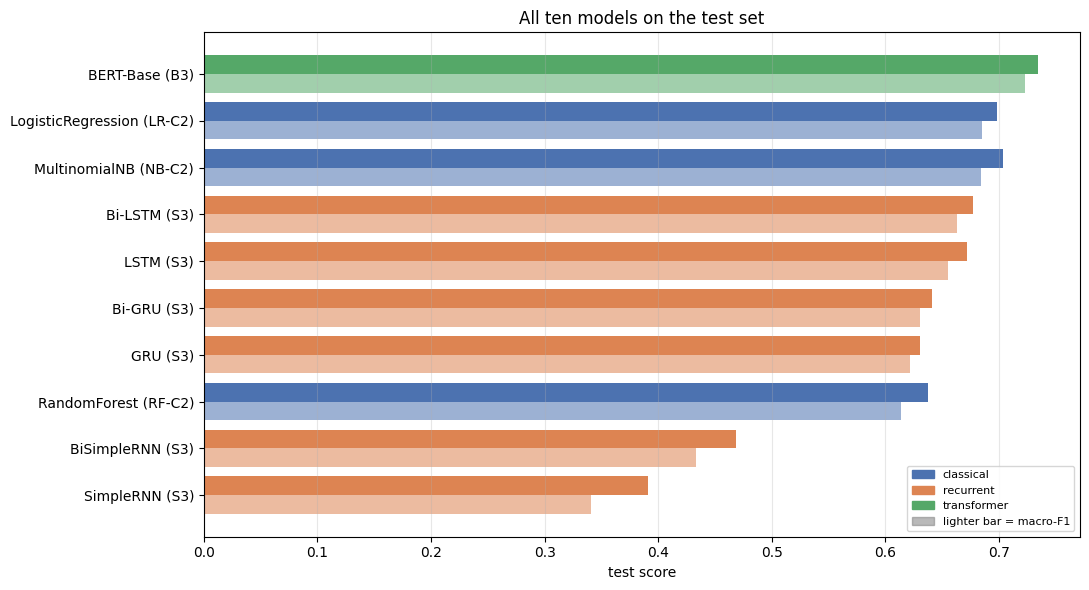

In [ ]:
TIER_COLOUR = {"classical": "#4c72b0", "recurrent": "#dd8452", "transformer": "#55a868"}

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(final))
ax.barh(y - 0.2, final.test_accuracy, 0.4, label="accuracy",
        color=[TIER_COLOUR[t] for t in final.tier])
ax.barh(y + 0.2, final.test_macro_f1, 0.4, label="macro-F1",
        color=[TIER_COLOUR[t] for t in final.tier], alpha=0.55)
ax.set_yticks(y)
ax.set_yticklabels([f"{m} ({c})" for m, c in zip(final.model, final.config)])
ax.invert_yaxis()
ax.set_xlabel("test score")
ax.set_title("All ten models on the test set")
ax.grid(axis="x", alpha=0.3)

handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in TIER_COLOUR.values()]
ax.legend(handles + [plt.Rectangle((0, 0), 1, 1, color="grey", alpha=0.55)],
          list(TIER_COLOUR) + ["lighter bar = macro-F1"], fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "final_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Accuracy against training cost

The horizontal axis is log-scaled because training times span five orders of magnitude,
from 0.02 seconds for Naive Bayes to 602 seconds for BERT.

This figure carries the argument a ranked table hides. The best model is far from the
cheapest, and the gap in accuracy is much smaller than the gap in compute.

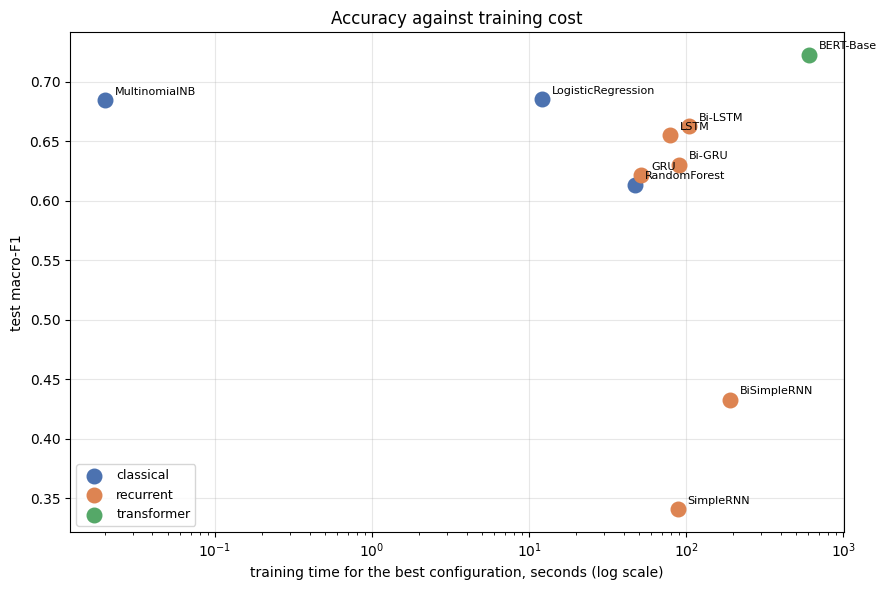

BERT-Base      0.7225 macro-F1 in   602.40s
LogisticRegression 0.6852 macro-F1 in    12.11s

gain from the transformer : +0.0373 macro-F1
cost multiplier           : 50x


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
for tier, grp in final.groupby("tier"):
    ax.scatter(grp.train_time_s, grp.test_macro_f1, s=110,
               color=TIER_COLOUR[tier], label=tier, zorder=3)
for _, r in final.iterrows():
    ax.annotate(r.model, (r.train_time_s, r.test_macro_f1),
                textcoords="offset points", xytext=(7, 4), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("training time for the best configuration, seconds (log scale)")
ax.set_ylabel("test macro-F1")
ax.set_title("Accuracy against training cost")
ax.grid(alpha=0.3, zorder=0)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "accuracy_vs_cost.png", dpi=150, bbox_inches="tight")
plt.show()

top_class = final[final.tier == "classical"].iloc[0]
top_all   = final.iloc[0]
print(f"{top_all.model:14s} {top_all.test_macro_f1:.4f} macro-F1 in {top_all.train_time_s:>8.2f}s")
print(f"{top_class.model:14s} {top_class.test_macro_f1:.4f} macro-F1 in {top_class.train_time_s:>8.2f}s")
print(f"\ngain from the transformer : {top_all.test_macro_f1 - top_class.test_macro_f1:+.4f} macro-F1")
print(f"cost multiplier           : {top_all.train_time_s / max(top_class.train_time_s, 0.01):,.0f}x")

## Section 13 - Confusion Matrix Heatmaps

Every matrix is rebuilt from the JSON reports the four training notebooks saved. No model
is reloaded and nothing is re-predicted.

Matrices are row-normalised. A bright off-diagonal cell means a class is losing a large
share of its own documents to another class, rather than simply being a large class.

Eleven reports exist on Drive. The sequence-length ablation is held separately so it
cannot be mistaken for an eleventh model.

In [ ]:
report_files = sorted(RESULTS_DIR.rglob("test_*.json"))
print(f"saved test reports found: {len(report_files)}")

CM, CM_ABL = {}, {}
for p in report_files:
    with open(p) as fh:
        payload = json.load(fh)
    cm = np.array(payload["confusion_matrix"], dtype=float)
    entry = {
        "cm": cm,
        "cm_norm": cm / np.maximum(cm.sum(axis=1, keepdims=True), 1),
        "accuracy": payload["accuracy"],
        "macro_f1": payload["macro_f1"],
        "family": payload.get("family_split"),
        "file": p.relative_to(DATA_DIR),
    }
    target = CM_ABL if "ABL" in payload["model"].upper() else CM
    target[payload["model"]] = entry

print(f"required models: {len(CM)} | ablation runs held separately: {len(CM_ABL)}\n")
for name, d in sorted(CM.items(), key=lambda kv: -kv[1]["macro_f1"]):
    print(f"  {name:28s} macro-F1 {d['macro_f1']:.4f}   {d['file']}")

assert len(CM) == 10, f"expected 10 required reports, found {len(CM)}"

saved test reports found: 11
required models: 10 | ablation runs held separately: 1

  BERT-Base B3                 macro-F1 0.7225   results/zawad/bert/reports/test_BERT-Base_B3.json
  LogisticRegression (LR-C2)   macro-F1 0.6852   results/hasib/test_LogisticRegression_LR-C2.json
  MultinomialNB (NB-C2)        macro-F1 0.6843   results/hasib/test_MultinomialNB_NB-C2.json
  Bi-LSTM (S3)                 macro-F1 0.6627   results/fabiha/test_Bi-LSTM_S3.json
  LSTM (S3)                    macro-F1 0.6551   results/fabiha/test_LSTM_S3.json
  Bi-GRU S3                    macro-F1 0.6304   results/zawad/gru/reports/test_Bi-GRU_S3.json
  GRU S3                       macro-F1 0.6214   results/zawad/gru/reports/test_GRU_S3.json
  RandomForest (RF-C2)         macro-F1 0.6134   results/hasib/test_RandomForest_RF-C2.json
  BiSimpleRNN (S3)             macro-F1 0.4328   results/hasib/test_BiSimpleRNN_S3.json
  SimpleRNN (S3)               macro-F1 0.3405   results/hasib/test_SimpleRNN_S3.json


### Best and worst model, full 20 by 20

The two ends of the ranking at full size. The diagonal is the signal. What matters is
whether the off-diagonal mass forms blocks or spreads evenly, because blocks mean the
errors follow the semantics of the label set rather than noise.

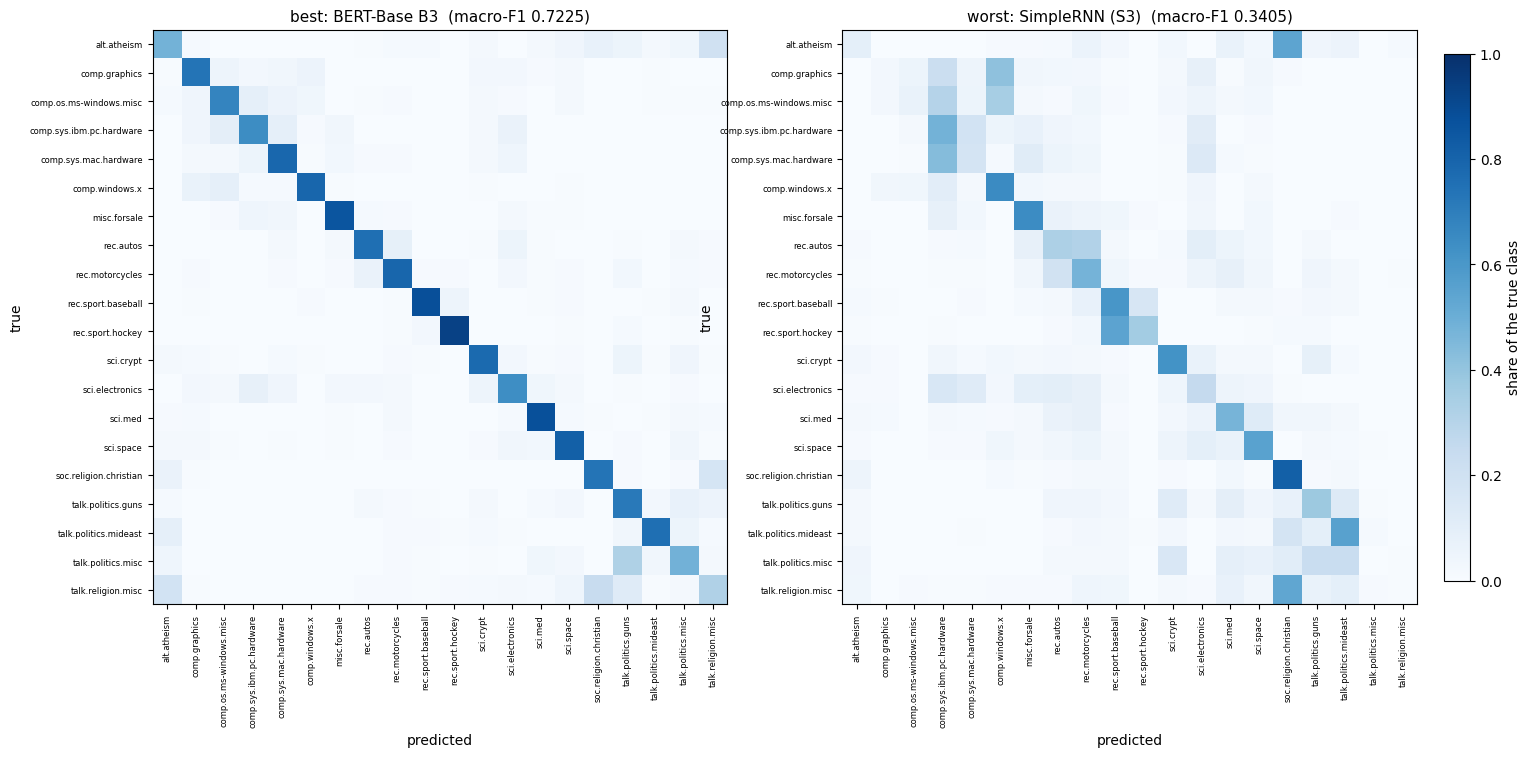

In [ ]:
def plot_cm(ax, cm_norm, title):
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASSES, rotation=90, fontsize=6)
    ax.set_yticklabels(CLASSES, fontsize=6)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(title, fontsize=11)
    return im

ranked = sorted(CM.items(), key=lambda kv: -kv[1]["macro_f1"])
best_name, best_cm   = ranked[0]
worst_name, worst_cm = ranked[-1]

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
im = plot_cm(axes[0], best_cm["cm_norm"],
             f"best: {best_name}  (macro-F1 {best_cm['macro_f1']:.4f})")
plot_cm(axes[1], worst_cm["cm_norm"],
        f"worst: {worst_name}  (macro-F1 {worst_cm['macro_f1']:.4f})")
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="share of the true class")
fig.savefig(FIG_DIR / "cm_best_vs_worst.png", dpi=150, bbox_inches="tight")
plt.show()

### The confusable class families, side by side

Ten full matrices printed together are unreadable, so this is the focused view: the best
model from each of the three tiers, on the two blocks that carry most of the difficulty.

The five `comp.*` classes share almost all their vocabulary. The three religion-adjacent
classes argue about the same subject from different positions. If contextual embeddings
help anywhere, these are the classes where a bag of static word vectors should struggle
most.

comparing best of each tier: ['BERT-Base B3', 'Bi-LSTM (S3)', 'LogisticRegression (LR-C2)']



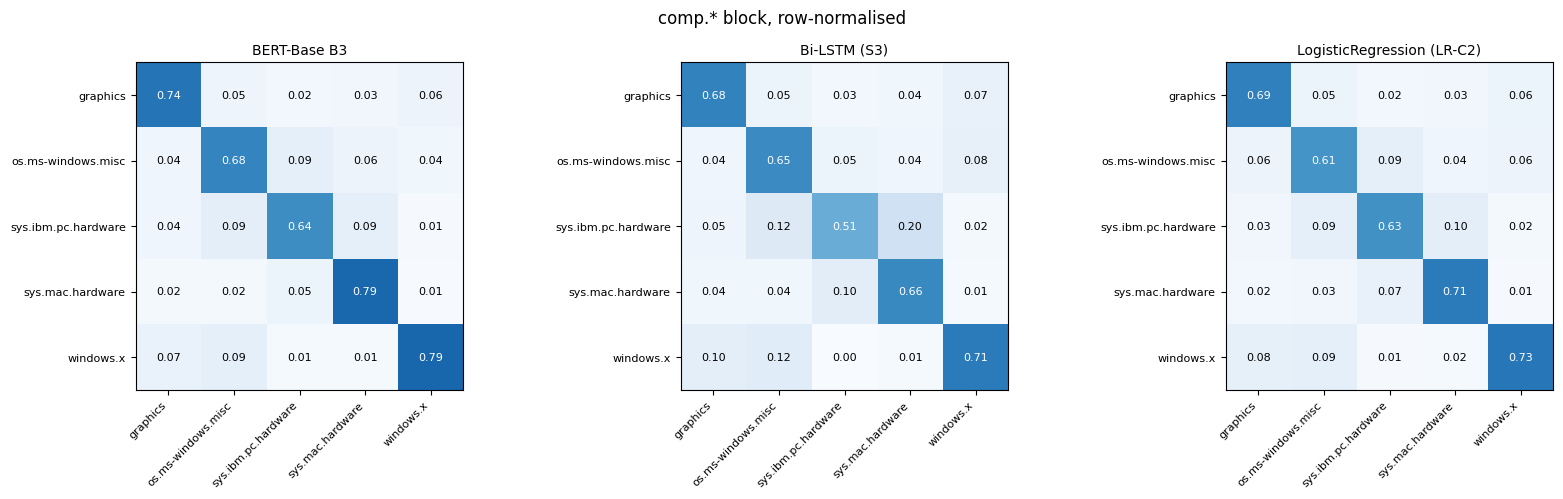

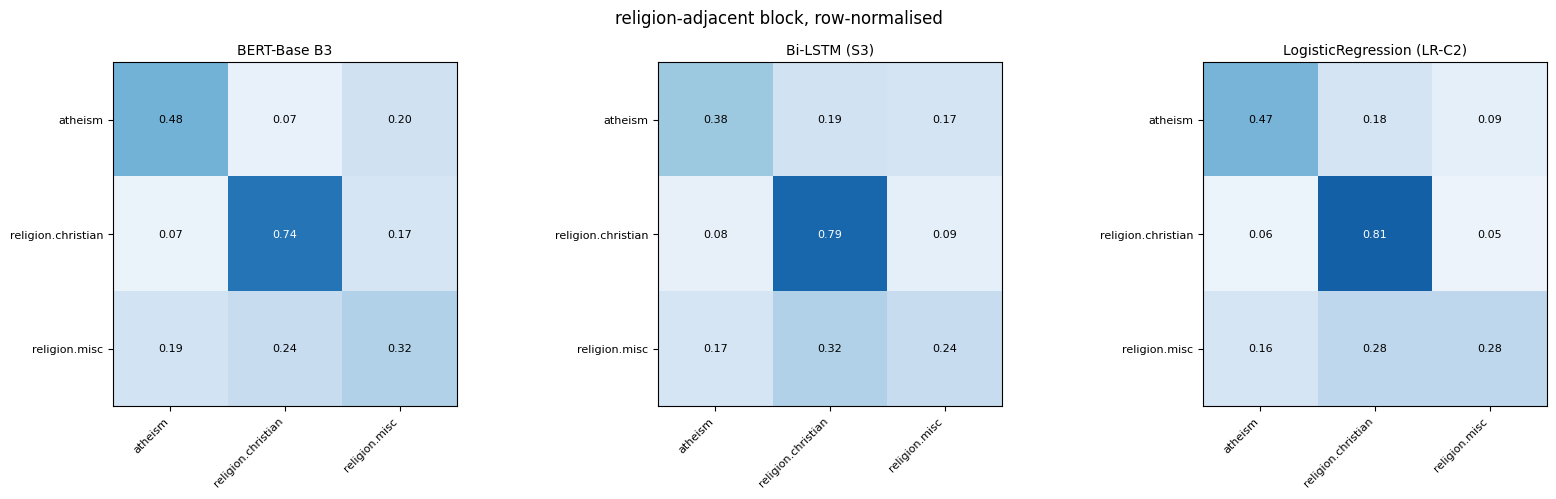

diagonal (share of each class correctly kept) inside each block

comp.*
  BERT-Base B3             mean 0.727   min 0.641
  Bi-LSTM (S3)             mean 0.641   min 0.505
  LogisticRegression (LR-C2) mean 0.673   min 0.615

religion
  BERT-Base B3             mean 0.511   min 0.317
  Bi-LSTM (S3)             mean 0.469   min 0.239
  LogisticRegression (LR-C2) mean 0.519   min 0.276



In [ ]:
COMP_BLOCK = [c for c in CLASSES if c.startswith("comp.")]
RELIGION_BLOCK = ["alt.atheism", "soc.religion.christian", "talk.religion.misc"]

def block_view(cm_norm, names):
    idx = [CLASSES.index(n) for n in names]
    return cm_norm[np.ix_(idx, idx)]

TIER_MEMBERS = {
    "transformer": ["BERT"],
    "recurrent":   ["LSTM", "GRU", "SimpleRNN"],
    "classical":   ["LogisticRegression", "MultinomialNB", "RandomForest"],
}
compare = []
for members in TIER_MEMBERS.values():
    cands = [n for n, _ in ranked if any(m in n for m in members)]
    if cands:
        compare.append(cands[0])
print(f"comparing best of each tier: {compare}\n")

for block_name, block in [("comp.*", COMP_BLOCK), ("religion-adjacent", RELIGION_BLOCK)]:
    fig, axes = plt.subplots(1, len(compare), figsize=(5.5 * len(compare), 5))
    axes = np.atleast_1d(axes)
    for ax, name in zip(axes, compare):
        sub = block_view(CM[name]["cm_norm"], block)
        im = ax.imshow(sub, cmap="Blues", vmin=0, vmax=1)
        short = [b.replace("comp.", "").replace("talk.", "").replace("soc.", "")
                  .replace("alt.", "") for b in block]
        ax.set_xticks(range(len(block))); ax.set_yticks(range(len(block)))
        ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(short, fontsize=8)
        for i in range(len(block)):
            for j in range(len(block)):
                ax.text(j, i, f"{sub[i, j]:.2f}", ha="center", va="center",
                        fontsize=8, color="white" if sub[i, j] > 0.5 else "black")
        ax.set_title(name, fontsize=10)
    fig.suptitle(f"{block_name} block, row-normalised", fontsize=12)
    fig.tight_layout()
    stem = block_name.replace(".*", "").replace("-", "_")
    fig.savefig(FIG_DIR / f"cm_block_{stem}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("diagonal (share of each class correctly kept) inside each block\n")
for block_name, block in [("comp.*", COMP_BLOCK), ("religion", RELIGION_BLOCK)]:
    print(block_name)
    for name in compare:
        d = np.diag(block_view(CM[name]["cm_norm"], block))
        print(f"  {name:24s} mean {d.mean():.3f}   min {d.min():.3f}")
    print()

### Where the errors fall

The 20 labels group into 7 families by prefix, so a misclassification is one of two
kinds. Confusing two `comp.sys.*` groups is a fine-grained failure between genuinely
similar topics. Confusing one with `talk.politics.guns` is a failure at topic
identification.

If wrong answers were spread randomly across the other 19 labels, roughly 15% would land
in the same family by chance. Every model runs far above that, so the errors follow
meaning rather than noise.

                     model  macro_f1  errors  within_family  cross_family  within_%
              BERT-Base B3    0.7225    1928            770          1158      39.9
LogisticRegression (LR-C2)    0.6852    2192            798          1394      36.4
     MultinomialNB (NB-C2)    0.6843    2151            802          1349      37.3
              Bi-LSTM (S3)    0.6627    2348            956          1392      40.7
                 LSTM (S3)    0.6551    2382            944          1438      39.6
                 Bi-GRU S3    0.6304    2608            999          1609      38.3
                    GRU S3    0.6214    2684           1016          1668      37.9
      RandomForest (RF-C2)    0.6134    2634            908          1726      34.5
          BiSimpleRNN (S3)    0.4328    3861           1809          2052      46.9
            SimpleRNN (S3)    0.3405    4421           1950          2471      44.1

chance rate for within-family errors: about 15%


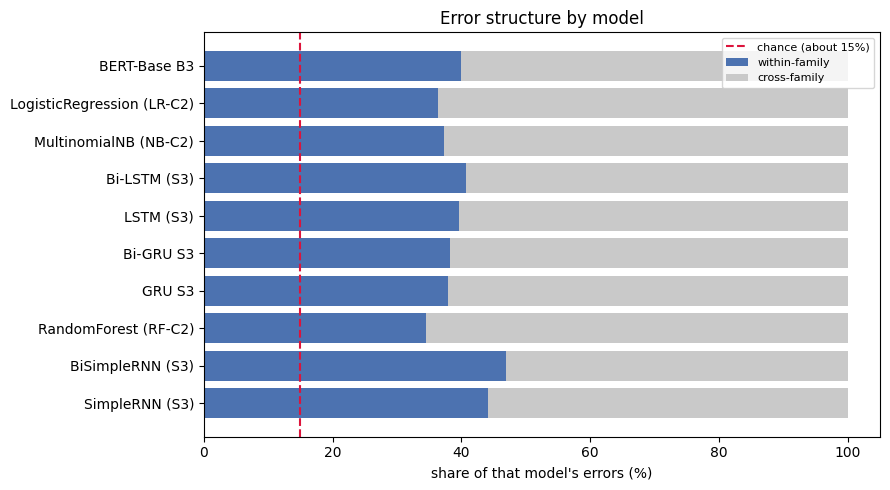

In [ ]:
fam_rows = []
for name, d in ranked:
    f = d["family"]
    if not f:
        continue
    fam_rows.append({
        "model": name,
        "macro_f1": round(d["macro_f1"], 4),
        "errors": f["n_errors"],
        "within_family": f["within_family"],
        "cross_family": f["cross_family"],
        "within_%": round(100 * f["within_share"], 1),
    })
fam = pd.DataFrame(fam_rows)
print(fam.to_string(index=False))
print(f"\nchance rate for within-family errors: about 15%")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fam.model, fam["within_%"], color="#4c72b0", label="within-family")
ax.barh(fam.model, 100 - fam["within_%"], left=fam["within_%"],
        color="#c9c9c9", label="cross-family")
ax.axvline(15, color="crimson", ls="--", lw=1.5, label="chance (about 15%)")
ax.invert_yaxis()
ax.set_xlabel("share of that model's errors (%)")
ax.set_title("Error structure by model")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "family_error_split.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 14 - Discussion

Section 3.9 asks which configurations outperformed others and why, grounded in the EDA
findings and the theoretical properties of the methods. Three evidence tables follow, then
the written analysis.

### Evidence 1: the embedding contrast across all six recurrent models

S1 and S2 differ only in the embedding matrix. Units, dropout and the frozen flag are
identical, so any difference is attributable to the embedding source alone. This is the
cleanest controlled comparison in the project, repeated across six architectures.

In [ ]:
emb = runs[(runs.tier == "recurrent") & (runs.config.isin(["S1", "S2"]))]
emb_pivot = emb.pivot_table(index="model", columns="embedding", values="val_macro_f1")
emb_pivot["delta (w2v - glove)"] = (emb_pivot["word2vec"] - emb_pivot["glove"]).round(4)
emb_pivot["winner"] = np.where(emb_pivot["delta (w2v - glove)"] > 0, "word2vec", "glove")

order = ["SimpleRNN", "BiSimpleRNN", "GRU", "Bi-GRU", "LSTM", "Bi-LSTM"]
emb_pivot = emb_pivot.reindex([m for m in order if m in emb_pivot.index])
print(emb_pivot.round(4).to_string())

gated = emb_pivot[~emb_pivot.index.str.contains("SimpleRNN")]
ungated = emb_pivot[emb_pivot.index.str.contains("SimpleRNN")]
print(f"\nungated models preferring word2vec : {(ungated.winner == 'word2vec').sum()} of {len(ungated)}")
print(f"gated models preferring glove      : {(gated.winner == 'glove').sum()} of {len(gated)}")
print("\ncoverage: word2vec 99.995% of the vocabulary, glove 87.32%")

embedding     glove  word2vec  delta (w2v - glove)    winner
model                                                       
SimpleRNN    0.2853    0.3351               0.0498  word2vec
BiSimpleRNN  0.3880    0.4114               0.0234  word2vec
GRU          0.6287    0.6131              -0.0156     glove
Bi-GRU       0.6270    0.6104              -0.0166     glove
LSTM         0.6120    0.6094              -0.0026     glove
Bi-LSTM      0.6378    0.6130              -0.0247     glove

ungated models preferring word2vec : 2 of 2
gated models preferring glove      : 4 of 4

coverage: word2vec 99.995% of the vocabulary, glove 87.32%


### Evidence 2: architecture against the length distribution

The recurrent models are ordered by how much gating they have. Mahir's EDA showed the
length distribution is heavily right-skewed, with the mean far above the median, so the
distance information must travel inside the hidden state is large.

In [ ]:
arch_order = ["SimpleRNN", "BiSimpleRNN", "GRU", "Bi-GRU", "LSTM", "Bi-LSTM"]
arch = final[final.model.isin(arch_order)].set_index("model")
arch = arch.reindex([m for m in arch_order if m in arch.index])
print(arch[["config", "test_accuracy", "test_macro_f1", "train_time_s"]].to_string())

if "SimpleRNN" in arch.index and "GRU" in arch.index:
    print(f"\ngating (SimpleRNN to GRU)      : "
          f"{arch.loc['GRU','test_macro_f1'] - arch.loc['SimpleRNN','test_macro_f1']:+.4f}")
for uni, bi in [("SimpleRNN", "BiSimpleRNN"), ("GRU", "Bi-GRU"), ("LSTM", "Bi-LSTM")]:
    if uni in arch.index and bi in arch.index:
        print(f"bidirectional ({uni:<11s})   : "
              f"{arch.loc[bi,'test_macro_f1'] - arch.loc[uni,'test_macro_f1']:+.4f}")

            config  test_accuracy  test_macro_f1  train_time_s
model                                                         
SimpleRNN       S3       0.391200       0.340500         88.31
BiSimpleRNN     S3       0.468300       0.432800        190.03
GRU             S3       0.630405       0.621351         51.70
Bi-GRU          S3       0.640870       0.630409         89.90
LSTM            S3       0.671991       0.655076         78.90
Bi-LSTM         S3       0.676673       0.662737        104.60

gating (SimpleRNN to GRU)      : +0.2809
bidirectional (SimpleRNN  )   : +0.0923
bidirectional (GRU        )   : +0.0091
bidirectional (LSTM       )   : +0.0077


### Evidence 3: the ablation studies

Six ablations beyond the thirty required runs. Three on the classical tier and two on an
LSTM testing the preprocessing strategy, and one on BERT testing sequence length.

The two preprocessing ablations test the same question through different mechanisms. For
TF-IDF the cost of keeping stopwords is feature slots under a 20,000-term cap. For a
sequence model it is timesteps inside a 250-token window.

In [ ]:
abl_view = ablation[["owner", "tier", "model", "config", "embedding",
                     "val_macro_f1", "test_macro_f1", "train_time_s", "notes"]]
print(abl_view.to_string(index=False))

clean_light = runs[(runs.tier == "classical")].pivot_table(
    index="model", columns="embedding", values="val_macro_f1", aggfunc="max")
if {"tfidf_clean", "tfidf_light"}.issubset(clean_light.columns):
    clean_light["delta (clean - light)"] = (clean_light["tfidf_clean"]
                                            - clean_light["tfidf_light"]).round(4)
    print("\nclassical preprocessing ablation, validation macro-F1")
    print(clean_light.round(4).to_string())

 owner        tier              model      config   embedding  val_macro_f1  test_macro_f1  train_time_s                                                    notes
fabiha   recurrent               LSTM   ABL-clean       glove      0.621928            NaN         79.50       ablation preprocessing: text_clean (full strategy)
fabiha   recurrent               LSTM   ABL-light       glove      0.588909            NaN         73.30                       ablation preprocessing: text_light
 hasib   classical LogisticRegression LR-C2-light tfidf_light      0.721800            NaN         15.94 ablation preprocessing: text_light instead of text_clean
 hasib   classical      MultinomialNB NB-C2-light tfidf_light      0.717900            NaN          0.03 ablation preprocessing: text_light instead of text_clean
 hasib   classical       RandomForest RF-C2-light tfidf_light      0.651800            NaN         82.74 ablation preprocessing: text_light instead of text_clean
 zawad transformer          

### Analysis

**The best model is BERT at 0.7225 test macro-F1 and the worst is SimpleRNN at 0.3405.**
The spread of 0.3820 is the largest single fact in the results, and both ends are
explained by the same property of the data.

Mahir's EDA showed the length distribution is heavily right-skewed, because quoted reply
chains drag the tail. In a SimpleRNN, information from an early token reaches the
classifier only by surviving one matrix multiplication per timestep. Over documents of
this length that path is unreliable. Adding gates fixes it: the jump from SimpleRNN to
GRU is +0.2809 macro-F1, the largest architectural gain anywhere in the project, and it
comes from letting part of the hidden state pass forward unchanged.

BERT removes the distance problem rather than managing it. Every token attends to every
other token directly, so nothing has to survive a chain of updates, and it arrives
pretrained rather than learning English and the task at once.

**The transformer advantage is not uniform.** Inside the `comp.*` block BERT keeps 0.727
of each class on average, against Logistic Regression at 0.673 and Bi-LSTM at 0.641.
Inside the religion block the ordering changes: Logistic Regression reaches 0.519,
slightly ahead of BERT at 0.511.

The two blocks are hard for different reasons. The `comp.*` classes are separated by what
a word means in context, so "windows" or "driver" needs the surrounding sentence to
resolve, which is what attention supplies. The religion classes are separated by stance
on a shared subject. All three discuss the same vocabulary, and the signal is which
specific terms appear at all rather than what they mean in context. That is what TF-IDF
measures directly, so a bag of words is not at a disadvantage there.

**The embedding result contradicts what the coverage numbers suggested.** Phase 0
reported 99.995% vocabulary coverage for Word2Vec against 87.32% for GloVe, and the
natural prediction was that full coverage would win. The measured result splits by
architecture. Both ungated models preferred Word2Vec, by +0.0498 and +0.0234 macro-F1.
All four gated models preferred GloVe, by 0.0026 to 0.0247.

Coverage and quality are different properties. GloVe was estimated from six billion
tokens of general English, so the 87.32% it covers sits well in the space. Word2Vec here
was trained on roughly 9,000 documents, so every word has a vector but each rests on very
little evidence. A model that cannot build context depends on individual token identity,
and for it a noisy vector beats a zero vector. A model that can build context exploits
the finer structure in better-estimated vectors, and loses less from a missing token
because the surrounding words supply the meaning.

**Preprocessing mattered less than the cap it interacts with.** The classical ablation
found the cleaned strategy ahead on all three models, by +0.0159, +0.0169 and +0.0075
validation macro-F1. The LSTM ablation found a larger gap, 0.6219 against 0.5889, a
+0.0330 advantage for cleaning. The mechanisms differ. Under TF-IDF the light vocabulary
spends slots on function words and inflected variants, so a 20,000-feature cap represents
fewer topical concepts. Under a sequence model those same words consume positions in a
250-token window. Mahir measured the vocabulary side of this at 66,111 terms under light
against 54,253 under full.

**Sequence length is not the binding constraint it appeared to be.** The BERT ablation is
the clearest evidence. Cutting truncation from 24.4% of documents to 9.1%, which means
seeing 15.2% more of the corpus, changed macro-F1 by +0.0016 for 1.85 times the training
time. The small bidirectional gains point the same way from a different direction:
+0.0091 for the GRU pair and +0.0077 for the LSTM pair. If the identifying vocabulary
appeared late in documents, both reading backwards and reading further forward would help,
and neither does much. Topic signal in these posts is front-loaded.

The exception is telling. The bidirectional gain for SimpleRNN is +0.0923, ten times the
gain for the gated pairs. A model that cannot retain early tokens benefits from a second
pass that reaches them from the other end. A model that can retain them has nothing to
gain.

**Errors are semantic, not random, for every model.** Within-family errors run far above
the roughly 15% that random guessing would produce.

The share is highest for the weakest models: Bi-SimpleRNN at 46.9% and SimpleRNN at
44.1%, against BERT's 39.9%. That looks backwards until the absolute counts are read
alongside it. SimpleRNN makes 1,950 within-family errors, BERT makes 770. The weak models
pick up coarse family-level vocabulary and fail on the fine distinctions inside a family,
so they land in the right family with the wrong label. The strong models fix most of
those, and what remains is a smaller set concentrated in genuinely confusable pairs. The
share alone is misleading and the counts carry the finding.

One caveat on the metric. `alt.atheism`, `soc.religion.christian` and
`talk.religion.misc` sit in three different families under the prefix taxonomy but are
the most semantically adjacent trio in the dataset, so confusions among them count as
cross-family failures when they are not really that.

**On cost.** BERT reaches 0.7225 macro-F1 in 602 seconds. Logistic Regression reaches
0.6852 in 12 seconds, and Naive Bayes reaches 0.6843 in 0.02 seconds. The transformer
buys +0.0373 over the best classical model for roughly fifty times the training time, and
roughly thirty thousand times the time of the second-best.

Whether that is worth it depends on the application. For coarse topic routing the
classical model is the better engineering choice. What BERT buys specifically is the
`comp.*` block, and that is visible in the block matrices rather than in the headline
number.

## Section 15 - Conclusion

### Key takeaways

Ten models were trained across three families, thirty required runs plus six ablations,
all against frozen shared artifacts verified by a single dataset checksum and scored by
one shared module.

The ranking follows each architecture's capacity to carry information across a long
document. Ungated recurrence performs worst at 0.3405 macro-F1. Gating closes most of the
gap, reaching 0.6627 at best. Attention with pretraining performs best at 0.7225.

A simple classical model on TF-IDF remains competitive. Logistic Regression reaches
0.6852 and Naive Bayes 0.6843, both above every recurrent model in the project. Newsgroup
topics are strongly keyword-driven, which suits a bag-of-features representation, and this
is why the transformer's advantage is smaller than its compute cost suggests.

Three controlled comparisons produced results that contradicted the expectation drawn from
the EDA. Embedding coverage did not predict embedding usefulness. Sequence length was not
a binding constraint. And the transformer did not win everywhere, losing the religion
block to TF-IDF. All three are reported as measured.

### Limitations

The embedding dimension was fixed at 50 for both GloVe and Word2Vec. This is the smallest
GloVe set available and caps what the recurrent tier can represent for 20 classes. It was
held constant so the two sources stay dimensionally comparable, which makes the S1 against
S2 contrast clean at the cost of absolute performance.

Several configurations used their full epoch budget with validation performance still
improving, so those runs are undertrained. Most of them are frozen-embedding recurrent
runs, which converge more slowly than the trainable ones. All three BERT configurations
also peaked at their final epoch, so the transformer numbers are a floor as well.

24.4% of documents are truncated at 256 WordPiece tokens for BERT. The ablation shows the
cost is small but not zero. The two tiers also do not see the same span of document: the
recurrent models read 250 tokens of cleaned text, which covers more of the original
document than 256 subword tokens does.

The test split holds 7,262 rows rather than the standard 7,532, because Phase 0 removed
515 empty documents and 557 below a minimum character length. Results are therefore not
directly comparable to published 20 Newsgroups figures without stating this. A further
226 test documents also appear in train, which is a property of the published benchmark
and was reported rather than deleted.

Validation scores run consistently above test scores for every model. BERT is 0.7753 on
validation against 0.7225 on test. The published train and test boundary is temporal, so
test posts come from a later period than training, while validation was carved from
within training. This affects all ten models equally, so the ranking holds, but absolute
test numbers sit below what validation suggests.

TF-IDF and the embedding representations were never compared on the same model. TF-IDF
fed the classical tier and the embeddings fed the recurrent tier, so the representation
comparison is confounded with the architecture comparison.

### Future improvements

Raise the embedding dimension to 100 or 300 and re-run the recurrent tier. At 50
dimensions this is the most likely single constraint on those results.

Extend the epoch budget for the configurations that used all of theirs, so every model is
compared at convergence rather than at a fixed budget.

Run one classical model on averaged embedding vectors and one recurrent model on TF-IDF,
which would separate the representation effect from the architecture effect that is
currently confounded.

Merge the three religion-adjacent classes into one and re-measure. Logistic Regression
already matches BERT on that block, which suggests the remaining error there is a property
of a label set that separates classes people separate by stance rather than topic.